In [1]:
# --- Interactive Environment ---
%matplotlib inline

# --- Standard Library ---
import os
import re
import glob
import json
import pickle
from pathlib import Path
from datetime import datetime
from typing import Sequence, Optional, Tuple, Dict, Union
from dataclasses import dataclass
from itertools import combinations

# --- Third-Party Libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import colormaps
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D
from scipy.stats import linregress, mannwhitneyu, spearmanr, pearsonr, wilcoxon, binomtest, norm, fisher_exact
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import StandardScaler

# --- Local / Project Imports ---
from aind_dynamic_foraging_basic_analysis.licks.lick_analysis import load_nwb
from aind_analysis_arch_result_access.han_pipeline import get_mle_model_fitting
from aind_dynamic_foraging_behavior_video_analysis.kinematics.tongue_analysis import (
    get_session_name_from_path,
    session_already_done,
)
from aind_dynamic_foraging_behavior_video_analysis.kinematics.tongue_kinematics_utils import (
    annotate_movement_timing,
    add_lick_metadata_to_movements,
)
from aind_dynamic_foraging_behavior_video_analysis.ephys.tongue_ephys import (
    get_events_dict, 
    build_event_df, 
    plot_unit_panels, 
    RasterPlotter, 
    compute_psth, 
    smooth_vector, 
    plot_psth,
    find_session_dir,
    load_intermediate_data,
    get_session_prefix,
    )


In [3]:
#load ephys data
with open('/root/capsule/scratch/combined_unit_tbl.pkl', 'rb') as file:
    combined_ephys_data = pickle.load(file)

In [4]:
from pathlib import Path

from data_loading import load_session_quality_filter

base_dirs = [Path("/root/capsule/scratch/session_analysis_mlk")]
filtered_session_paths = load_session_quality_filter(base_dirs)


Sessions meeting criteria (coverage>90.0, median duration>0.06s): 44
/root/capsule/scratch/session_analysis_mlk/behavior_782394_2025-04-23_10-51-14  (coverage=100.0%, median_dur=0.074s)
/root/capsule/scratch/session_analysis_mlk/behavior_782394_2025-04-24_12-07-31  (coverage=100.0%, median_dur=0.072s)
/root/capsule/scratch/session_analysis_mlk/behavior_782394_2025-04-25_11-13-18  (coverage=100.0%, median_dur=0.072s)
/root/capsule/scratch/session_analysis_mlk/behavior_761038_2025-04-15_10-24-57  (coverage=99.9%, median_dur=0.074s)
/root/capsule/scratch/session_analysis_mlk/behavior_791691_2025-06-27_13-54-27  (coverage=99.9%, median_dur=0.068s)
/root/capsule/scratch/session_analysis_mlk/behavior_752014_2025-03-28_11-04-56  (coverage=99.9%, median_dur=0.092s)
/root/capsule/scratch/session_analysis_mlk/behavior_751769_2025-01-16_11-31-52  (coverage=99.8%, median_dur=0.076s)
/root/capsule/scratch/session_analysis_mlk/behavior_716325_2024-05-31_10-31-14  (coverage=99.8%, median_dur=0.090s)


In [5]:
from data_loading import DEFAULT_CRITERIA, filter_ephys_units

filtered_ephys = filter_ephys_units(combined_ephys_data, filtered_session_paths)


Filtered units: 104 / 18300
            session_prefix  units_before  units_after
behavior_782394_2025-04-23           243            9
behavior_782394_2025-04-24           394            7
behavior_782394_2025-04-25           116            0
behavior_761038_2025-04-15           435            2
behavior_791691_2025-06-27           265            4
behavior_752014_2025-03-28           254            1
behavior_751769_2025-01-16           229            1
behavior_716325_2024-05-31           281            3
behavior_758017_2025-02-06           127            1
behavior_782394_2025-04-22           270            0
behavior_758017_2025-02-07           231            4
behavior_751769_2025-01-18           255            5
behavior_754897_2025-03-14           117            5
behavior_784803_2025-07-01           357            3
behavior_784803_2025-07-02           375            0
behavior_751004_2024-12-20           248            3
behavior_751766_2025-02-11           277            5


<!-- <details>
<summary>Archived: Threshold sweep on model QC</summary>

```python

#how many sessions / units do you get when filtering by varying tracking quality metrics?

# === Threshold sweep ===

# ---------- helpers ----------
def get_session_prefix(s: str) -> str:
    """'behavior_751004_2024-12-20_13-26-07' -> 'behavior_751004_2024-12-20'."""
    return re.sub(r'_\d{2}-\d{2}-\d{2}$', '', s)

DEFAULT_CRITERIA = {
    "isi_violations": {"bounds": [0.0, 0.1]},
    "p_max":         {"bounds": [0.5, 1.0]},
    "lat_max_p":     {"bounds": [0.005, 0.02]},
    "eu":            {"bounds": [0.0, 0.25]},
    "corr":          {"bounds": [0.95, 1.0]},
    "qc_pass":       {"items":  [True]},
    "peak":          {"bounds": [-1000, 0]},
    "trial_count":   {"bounds": [100, 2000]},
    "in_df":         {"items":  [True]},
}

def load_sessions_qc(base_dirs: list[Path]) -> pd.DataFrame:
    """Scan base dirs for completed sessions; read tongue_quality_stats.json."""
    rows = []
    for base in base_dirs:
        if not Path(base).exists():
            continue
        for subdir in Path(base).iterdir():
            if not (subdir.is_dir() and session_already_done(subdir)):
                continue
            jf = subdir / "tongue_quality_stats.json"
            try:
                with open(jf, "r") as f:
                    d = json.load(f)
            except Exception:
                continue
            rows.append({
                "session_path": str(subdir),
                "session_id": d.get("session_id", subdir.name),
                "session_prefix": get_session_prefix(get_session_name_from_path(str(subdir))),
                "coverage_pct": float(d.get("coverage_pct", 0.0)),
                "duration_p50": float(d.get("percentiles", {}).get("duration", {}).get("0.5", 0.0)),
            })
    return pd.DataFrame(rows)

def build_threshold_map(
    sessions_qc: pd.DataFrame,
    combined_ephys_data: pd.DataFrame,
    criteria: dict = DEFAULT_CRITERIA,
    coverage_grid = None,
    duration_grid = None,
) -> pd.DataFrame:
    """Make grid of (coverage_min, duration50_min) vs (#sessions, #units_after)."""
    if sessions_qc.empty:
        return pd.DataFrame(columns=["coverage_min","duration50_min","n_sessions","n_units_after"])

    if coverage_grid is None:
        coverage_grid = list(range(0, 96, 5))  # 0,5,...,95
    if duration_grid is None:
        duration_grid = [0.040, 0.050, 0.060, 0.070, 0.080, 0.090, 0.100]

    ephys = combined_ephys_data.copy()
    ephys["session_prefix"] = ephys["session"].map(get_session_prefix)
    ephys_filt = filter_by_criteria(ephys, criteria)

    rows = []
    for cov_min in coverage_grid:
        allowed_cov = sessions_qc["coverage_pct"] >= cov_min
        for dur_min in duration_grid:
            allowed = sessions_qc.loc[allowed_cov & (sessions_qc["duration_p50"] >= dur_min), "session_prefix"].unique()
            n_units = int(ephys_filt["session_prefix"].isin(allowed).sum())
            rows.append({
                "coverage_min": cov_min,
                "duration50_min": dur_min,
                "n_sessions": int(len(allowed)),
                "n_units_after": n_units,
            })
    return pd.DataFrame(rows).sort_values(["coverage_min","duration50_min"]).reset_index(drop=True)

def plot_threshold_heatmap(
    threshold_map: pd.DataFrame,
    value_col: str,
    title: str,
    cmap: str = "viridis",
    figsize=(6, 6),
):
    """Single generic heatmap (value_col ∈ {'n_units_after','n_sessions'})."""
    if threshold_map.empty:
        print("No data to plot.")
        return

    coverage_vals = sorted(threshold_map["coverage_min"].unique())
    duration_vals = sorted(threshold_map["duration50_min"].unique())
    Z = threshold_map.pivot(index="coverage_min", columns="duration50_min", values=value_col)
    # Ensure rows/cols are ordered as our sorted lists
    Z = Z.loc[coverage_vals, duration_vals]

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(Z.values, origin="lower", cmap=cmap, aspect="auto")  # <-- fix narrow plots
    ax.set_aspect('auto')  # redundant with aspect="auto" but harmless

    vmax = np.nanmax(Z.values)
    for i, cov in enumerate(coverage_vals):
        for j, dur in enumerate(duration_vals):
            val = Z.iloc[i, j]
            if np.isnan(val): 
                continue
            text_color = "white" if val < 0.5 * vmax else "black"
            ax.text(j, i, f"{int(val)}", ha="center", va="center", color=text_color, fontsize=8)

    ax.set_xticks(np.arange(len(duration_vals)))
    ax.set_xticklabels([f"{d:.3f}" for d in duration_vals], rotation=0)
    ax.set_xlabel("Median duration threshold (s)")

    ax.set_yticks(np.arange(len(coverage_vals)))
    ax.set_yticklabels([f"{c}%" for c in coverage_vals])
    ax.set_ylabel("Lick coverage threshold")

    cbar = plt.colorbar(im, ax=ax, label=("# Units after filtering" if value_col=="n_units_after" else "# Sessions meeting criteria"))
    ax.set_title(title)
    fig.tight_layout()
    plt.show()

# ---------- Usage ----------
# # 0) define your base_dirs once (uncomment & adjust as needed)
# base_dirs = [
#     Path("/root/capsule/scratch/session_analysis_out_of_distribution_full"),
#     Path("/root/capsule/scratch/session_analysis_in_distribution"),
# ]

# 1) load session QC once
sessions_qc = load_sessions_qc(base_dirs)

# 2) build sweep table once
threshold_map = build_threshold_map(
    sessions_qc=sessions_qc,
    combined_ephys_data=combined_ephys_data,  # assumes in memory
    criteria=DEFAULT_CRITERIA,
    coverage_grid=list(range(0, 96, 5)),      # tweak if desired
    duration_grid=[0.040, 0.050, 0.060, 0.070, 0.080, 0.090, 0.100],
)

# 3) plot either metric with one call each (no duplicate plotting code)
plot_threshold_heatmap(
    threshold_map, "n_units_after",
    title="Number of Units by Coverage × Duration50 Threshold",
    cmap="viridis",
    figsize=(6, 6),
)

plot_threshold_heatmap(
    threshold_map, "n_sessions",
    title="Number of Sessions by Coverage × Duration50 Threshold",
    cmap="cividis",
    figsize=(6, 6),
)
```
</details>  -->

In [8]:
from data_loading import load_units_with_spike_times

ROOT_SCRATCH = "/root/capsule/data/LC-NE_scratch_data_1"
units_with_spikes = load_units_with_spike_times(filtered_ephys, ROOT_SCRATCH)


[ok] behavior_716325_2024-05-31_10-31-14: 3/3 units with 'spike_times' column
[ok] behavior_751004_2024-12-20_13-26-11: 3/3 units with 'spike_times' column
[ok] behavior_751004_2024-12-21_13-28-28: 3/4 units with 'spike_times' column
[ok] behavior_751004_2024-12-22_13-09-17: 1/1 units with 'spike_times' column
[ok] behavior_751004_2024-12-23_14-20-03: 2/2 units with 'spike_times' column
[ok] behavior_751181_2025-02-25_12-12-35: 2/2 units with 'spike_times' column
[ok] behavior_751181_2025-02-27_11-24-47: 5/5 units with 'spike_times' column
[ok] behavior_751766_2025-02-11_11-53-38: 5/5 units with 'spike_times' column
[ok] behavior_751766_2025-02-13_11-31-21: 3/3 units with 'spike_times' column
[ok] behavior_751766_2025-02-14_11-37-11: 4/4 units with 'spike_times' column
[ok] behavior_751769_2025-01-16_11-32-05: 1/1 units with 'spike_times' column
[ok] behavior_751769_2025-01-17_11-37-39: 3/3 units with 'spike_times' column
[ok] behavior_751769_2025-01-18_10-15-25: 5/5 units with 'spike_

In [9]:
# PDF RASTERS
# #raster plot, 3 panels/alignments per unit, pdf save

# # --- loop over units, loading per-session data on demand ---
# _per_session_cache = {}  # session -> dict with movs/trials/licks/kins/events

# PDF_PATH = Path("/root/capsule/scratch/figures/LC_movement_raster_psth_alignments_10112025.pdf")
# PDF_PATH.parent.mkdir(parents=True, exist_ok=True)

# with PdfPages(PDF_PATH) as pdf:

#     for row in units_with_spikes.itertuples(index=False):
#         session = row.session
#         unit_session = str(row.unit_id) +' ' + str(session)
#         spike_times = row.spike_times  # your per-unit spikes
#         if session not in _per_session_cache:
#             sdir = find_session_dir(session, roots=base_dirs)
#             _per_session_cache[session] = load_intermediate_data(sdir)

#         data = _per_session_cache[session]
#         tongue_movements = data["movs"]
#         df_trials        = data["trials"]
#         df_licks         = data["licks"]
#         tongue_kinematics= data["kins"]
#         evnts            = data["events"]

#         first_go_cue_time = evnts[evnts['event'] == 'goCue_start_time']['raw_timestamps'].iloc[0]
#         spike_times_in_session = spike_times - first_go_cue_time

#         #events
#         events_dict = get_events_dict(df_trials, df_licks, tongue_kinematics)
#         E  = build_event_df(events_dict)
#         Ev = E.dropna(subset=['goCue','firstLick','firstMove']).copy()

#         #trial orders and combos
#         trials = list(Ev.index)
#         event_dicts = {name: Ev[name].to_dict() for name in Ev.columns}
#         combos = [
#             ('goCue',     'firstMove'),
#             ('firstMove', 'firstLick'),
#             ('firstLick', 'firstMove'),
#         ]

#         fig = plot_unit_panels(
#             spike_times_in_session,
#             unit_session,
#             trials,
#             event_dicts,
#             combos,
#             events_to_plot=['goCue', 'firstMove', 'firstLick', 'reward'],  # or None
#             pre=1.0,
#             post=2.0,
#             bin_size=0.001,
#             sigma=0.025
#         )
#         # plt.show()
#         pdf.savefig(fig, bbox_inches="tight")
#         plt.close(fig)



In [10]:
# PDF RASTERS

# #raster plot, cue response on movement 1 vs 2, pdf save

# # --- loop over units, loading per-session data on demand ---
# _per_session_cache = {}  # session -> dict with movs/trials/licks/kins

# PDF_PATH = Path("/root/capsule/scratch/figures/LC_movement_raster_psth_movenumber_10112025.pdf")
# PDF_PATH.parent.mkdir(parents=True, exist_ok=True)

# plt.ioff()  # (optional) speed up headless plotting

# with PdfPages(PDF_PATH) as pdf:
#     for row in units_with_spikes.itertuples(index=False):
#         session = row.session
#         unit_session = f"{row.unit_id} {session}"
#         spike_times = row.spike_times

#         # Load intermediate data (cached per session)
#         if session not in _per_session_cache:
#             sdir = find_session_dir(session, roots=base_dirs)
#             _per_session_cache[session] = load_intermediate_data(sdir)

#         data = _per_session_cache[session]
#         tongue_movements = data["movs"].copy()
#         df_trials        = data["trials"]
#         df_licks         = data["licks"]
#         tongue_kinematics= data["kins"]
#         evnts            = data["events"]

#         first_go_cue_time = evnts[evnts['event'] == 'goCue_start_time']['raw_timestamps'].iloc[0]
#         spike_times_in_session = spike_times - first_go_cue_time

#         # --- events tables ---
#         events_dict = get_events_dict(df_trials, df_licks, tongue_kinematics)
#         E  = build_event_df(events_dict)
#         Ev = E.dropna(subset=['goCue','firstLick','firstMove']).copy()
#         if Ev.empty:
#             print(f"[skip] {unit_session}: no valid trials after dropping NaNs for goCue/firstLick/firstMove")
#             continue

#         # --- annotate movements per trial if not already annotated ---
#         if 'cue_response_movement_number' not in tongue_movements.columns:
#             tongue_movements = add_lick_metadata_to_movements(
#                 tongue_movements,
#                 df_licks,
#                 fields=['timestamps']
#             )
#             tongue_movements = tongue_movements.rename(columns={'timestamps': 'lick_time'})

#             # Annotate movements using trials
#             tongue_movements = annotate_movement_timing(tongue_movements, df_trials)


#         # Robust per-trial cue_response_movement_number
#         trial_crmn = (
#             tongue_movements.groupby('trial')['cue_response_movement_number']
#               .apply(lambda s: s.dropna().astype('Int64').iloc[0] if s.dropna().size else pd.NA)
#         )

#         trials_cr1 = set(trial_crmn[trial_crmn == 1].index.tolist())
#         trials_cr2 = set(trial_crmn[trial_crmn == 2].index.tolist())

#         # Keep only trials that exist in Ev
#         valid_trials = set(Ev.index)
#         trials_cr1 = sorted(trials_cr1 & valid_trials)
#         trials_cr2 = sorted(trials_cr2 & valid_trials)

#         # Order by latency to firstMove
#         sort_key = 'firstMove'
#         lat = (Ev[sort_key] - Ev['goCue']).dropna()
#         ordered_cr1 = sorted(trials_cr1, key=lambda tr: lat.get(tr, np.inf))
#         ordered_cr2 = sorted(trials_cr2, key=lambda tr: lat.get(tr, np.inf))

#         combined_trials = ordered_cr1 + ordered_cr2
#         split_idx = len(ordered_cr1)
#         if len(combined_trials) == 0:
#             print(f"[skip] {unit_session}: no trials in CR1/CR2 overlap with Ev")
#             continue

#         # Build event dicts
#         event_dicts = {n: Ev[n].to_dict() for n in Ev.columns}

#         # Raster aligned to goCue
#         align_key = 'goCue'
#         align_times = event_dicts[align_key]
#         rp = RasterPlotter(
#             spike_times_in_session,
#             combined_trials,
#             align_times,
#             pre=1.5, post=1.5, bin_size=0.001
#         )

#         # Relative event overlays
#         events = {}
#         for ix, name in enumerate(['goCue','firstMove','firstLick','reward']):
#             times_rel = {}
#             for i, tr in enumerate(combined_trials):
#                 t_abs = event_dicts[name].get(tr)
#                 t0    = align_times.get(tr)
#                 if t_abs is not None and t0 is not None:
#                     times_rel[i] = t_abs - t0
#             events[name] = {'times': times_rel,
#                             'style': {'color': f"C{ix}", 'linestyle':'--', 'linewidth':2}}

#         # Compute group PSTHs
#         raster_cr1 = rp.raster[:split_idx, :]   # CR==1
#         raster_cr2 = rp.raster[split_idx:, :]   # CR==2
#         psth1, _ = compute_psth(raster_cr1, bin_size=rp.bin_size)
#         psth2, _ = compute_psth(raster_cr2, bin_size=rp.bin_size)

#         # Smooth
#         psth1_sm = smooth_vector(psth1, bin_size=rp.bin_size, sigma=0.025)
#         psth2_sm = smooth_vector(psth2, bin_size=rp.bin_size, sigma=0.025)

#         # Plot
#         fig, (ax_raster, ax_psth) = plt.subplots(
#             2, 1, figsize=(8, 7), sharex=True,
#             gridspec_kw={'height_ratios':[3,1]}
#         )

#         # Raster
#         rp.plot_raster(ax_raster, spike_color='black')
#         rp.add_events(ax_raster, events)
#         ax_raster.axhline(split_idx, color='gray', linestyle=':', linewidth=1)
#         ax_raster.set_ylabel('Trials')

#         # Title = unit_session (as requested)
#         ax_raster.set_title(unit_session)

#         # PSTHs (smoothed only)
#         plot_psth(rp.bins, psth1, psth1_sm, ax=ax_psth, label='CR==1', plot_raw=False, color='black')
#         plot_psth(rp.bins, psth2, psth2_sm, ax=ax_psth, label='CR==2', plot_raw=False, color='gray')
#         ax_psth.set_xlabel('Time from goCue (s)')
#         ax_psth.set_ylabel('Firing rate (spk/s)')
#         ax_psth.legend(frameon=False)

#         plt.tight_layout()

#         # Save page to the multi-page PDF
#         pdf.savefig(fig, bbox_inches="tight")
#         plt.close(fig)

# print(f"✅ Saved {PDF_PATH}")


In [17]:
from ephys_utils import (
    AnalysisConfig,
    count_spikes_in_window,
    first_spike_latency_in_window,
    mannwhitney_summary,
    build_trial_features,
    make_session_bundle,
    analyze_unit_for_session,
)


In [18]:

cfg = AnalysisConfig(
    align_key="goCue",
    count_window_s=(0.0, 0.2),
    baseline_window_s=(-1, 0.0),
    min_trials_per_group=20,
)
bundle_cache: Dict[str, dict] = {}

all_counts = []

for u in units_with_spikes.itertuples(index=False):
    session = u.session
    if session not in bundle_cache:
        bundle_cache[session] = make_session_bundle(session, cfg, base_dirs=base_dirs)

    unit_counts = analyze_unit_for_session(pd.Series(u._asdict()), bundle_cache[session], cfg)
    all_counts.append(unit_counts)

all_counts_df = pd.concat(all_counts, ignore_index=True).sort_values(["session","unit_id","trial"])


## Analysis

In [20]:
FIG_DIR = Path("/root/capsule/scratch/figures/ephys_kinematics_panels/1sbaseline_200msresponse")
SAVE_FIG = False

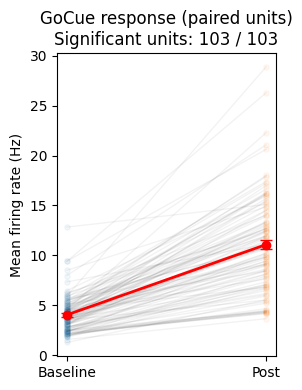

In [21]:
# --- derive window durations from cfg ---
post_dur = cfg.count_window_s[1] - cfg.count_window_s[0]
pre_dur  = cfg.baseline_window_s[1] - cfg.baseline_window_s[0]

# Use existing all_counts_df with spike_count and baseline_spike_count
counts = all_counts_df.dropna(subset=["spike_count", "baseline_spike_count"]).copy()

# --- convert to Hz ---
counts["spike_rate_hz"] = counts["spike_count"] / post_dur
counts["baseline_rate_hz"] = counts["baseline_spike_count"] / pre_dur


def summarize_unit(g: pd.DataFrame) -> pd.Series:
    pre = g["baseline_rate_hz"].to_numpy()
    post = g["spike_rate_hz"].to_numpy()

    d = post - pre
    d = d[np.isfinite(d) & (d != 0)]

    p = np.nan
    if len(d) > 0:
        _, p = wilcoxon(d, alternative="two-sided")

    return pd.Series(
        {
            "p": p,
            "mean_pre":  pre.mean() if len(pre)  else np.nan,
            "mean_post": post.mean() if len(post) else np.nan,
        }
    )


unit_stats = (
    counts.groupby(["session", "unit_id"], sort=False)
          .apply(summarize_unit)
          .reset_index()
)

# ----- plotting -----
y_pre  = unit_stats["mean_pre"].to_numpy()
y_post = unit_stats["mean_post"].to_numpy()

mask_pre  = np.isfinite(y_pre)
mask_post = np.isfinite(y_post)

mean_pre  = y_pre[mask_pre].mean()
mean_post = y_post[mask_post].mean()

sem_pre  = y_pre[mask_pre].std(ddof=1)  / np.sqrt(mask_pre.sum()) if mask_pre.any()  else np.nan
sem_post = y_post[mask_post].std(ddof=1) / np.sqrt(mask_post.sum()) if mask_post.any() else np.nan

x_pos = np.array([0., 1.])

plt.figure(figsize=(3, 4))

# paired unit lines
for yp, yo in zip(y_pre, y_post):
    plt.plot(x_pos, [yp, yo], "k-", alpha=0.05, linewidth=1)

# unit points
plt.scatter(np.zeros_like(y_pre),  y_pre,  s=15, alpha=0.05)
plt.scatter(np.ones_like(y_post), y_post, s=15, alpha=0.05)

# grand mean ± SEM
plt.errorbar(
    x_pos,
    [mean_pre, mean_post],
    [sem_pre, sem_post],
    fmt="o",
    color="red",
    capsize=4,
    linewidth=2,
    zorder=5,
)
plt.plot(x_pos, [mean_pre, mean_post], "r-", linewidth=2)

plt.xticks([0, 1], ["Baseline", "Post"])
plt.ylabel("Mean firing rate (Hz)")
plt.title(
    f"GoCue response (paired units)\n"
    f"Significant units: {(unit_stats['p'] < 0.05).sum()} / {len(unit_stats)}"
)

plt.tight_layout()

fig_dir = FIG_DIR
fname = "gocue_paired_units"

png_path = fig_dir / f"{fname}.png"
svg_path = fig_dir / f"{fname}.svg"

if SAVE_FIG:
    fig_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.savefig(svg_path, dpi=300, bbox_inches="tight")

plt.show()


<!-- <details>
<summary>Archived: Window sweep </summary>

```python


#loop through windows, screening only
from scipy.stats import spearmanr

def _bh_fdr(pvals: np.ndarray, alpha: float = 0.05) -> np.ndarray:
    """
    Benjamini–Hochberg FDR control. Returns a boolean mask of discoveries.
    """
    p = np.asarray(pvals, dtype=float)
    n = p.size
    if n == 0:
        return np.zeros(0, dtype=bool)
    order = np.argsort(p)
    ranked = p[order]
    thresh = (np.arange(1, n+1) / n) * alpha
    is_sig_sorted = ranked <= thresh
    # ensure monotonicity
    if is_sig_sorted.any():
        k = np.max(np.where(is_sig_sorted)[0])
        is_sig_sorted[:k+1] = True
        is_sig_sorted[k+1:] = False
    is_sig = np.zeros_like(is_sig_sorted, dtype=bool)
    is_sig[order] = is_sig_sorted
    return is_sig

def score_window_metrics(unit_counts_df: pd.DataFrame,
                         rt_col: str,
                         min_trials_per_unit: int = 20,
                         alpha: float = 0.05):
    """
    Compute per-unit Spearman rho(spike_count, RT) and aggregate metrics.
    Returns (metrics_dict, unit_table).
    """
    rows = []
    for (sess, uid), g in unit_counts_df.groupby(["session", "unit_id"]):
        g = g.dropna(subset=["spike_count", rt_col])
        if len(g) < min_trials_per_unit:
            continue
        rho, p = spearmanr(g["spike_count"], g[rt_col])
        if np.isfinite(rho):
            rows.append({
                "session": sess,
                "unit_id": uid,
                "rho": float(rho),
                "p": float(p),
                "n_trials": int(len(g))
            })

    if not rows:
        return (
            dict(n_units=0,
                 mean_abs_rho=np.nan,
                 median_abs_rho=np.nan,
                 wmean_abs_rho=np.nan,
                 mean_rho=np.nan,
                 fisher_z_mean_rho=np.nan,
                 frac_positive=np.nan,
                 n_sig_p=0,
                 n_sig_fdr=0),
            pd.DataFrame(columns=["session","unit_id","rho","p","n_trials","sig_p","sig_fdr"])
        )

    df = pd.DataFrame(rows)
    # significance flags
    df["sig_p"]   = df["p"] < alpha
    df["sig_fdr"] = _bh_fdr(df["p"].values, alpha=alpha)

    # aggregates
    mean_abs   = float(df["rho"].abs().mean())
    med_abs    = float(df["rho"].abs().median())
    wmean_abs  = float(np.average(df["rho"].abs(), weights=df["n_trials"]))
    mean_rho   = float(df["rho"].mean())
    # Fisher z average (atanh), then back-transform (tanh)
    z = np.arctanh(np.clip(df["rho"].values, -0.999999, 0.999999))
    fisher_z_mean_rho = float(np.tanh(z.mean()))
    frac_pos  = float((df["rho"] > 0).mean())
    n_sig_p   = int(df["sig_p"].sum())
    n_sig_fdr = int(df["sig_fdr"].sum())
    n_units   = int(df["unit_id"].nunique())

    metrics = dict(
        n_units=n_units,
        mean_abs_rho=mean_abs,
        median_abs_rho=med_abs,
        wmean_abs_rho=wmean_abs,
        mean_rho=mean_rho,
        fisher_z_mean_rho=fisher_z_mean_rho,
        frac_positive=frac_pos,
        n_sig_p=n_sig_p,
        n_sig_fdr=n_sig_fdr,
        alpha=alpha
    )
    return metrics, df


# ====== CONFIG SWEEP ======
from dataclasses import replace
from itertools import product
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from typing import Dict, List, Tuple

# ---- choose what "explains RT" means ----
def score_window_by_spearman(unit_counts_df: pd.DataFrame,
                             rt_col: str,
                             min_trials_per_unit: int = 20) -> dict:
    """
    For each unit, compute Spearman correlation between spike_count and RT.
    Return an aggregate score (mean |rho|), plus distributional stats.
    """
    rows = []
    for (sess, uid), g in unit_counts_df.groupby(["session", "unit_id"]):
        g = g.dropna(subset=["spike_count", rt_col])
        if len(g) < min_trials_per_unit:
            continue
        rho, p = spearmanr(g["spike_count"], g[rt_col])
        if np.isfinite(rho):
            rows.append({"session": sess, "unit_id": uid, "rho": float(rho), "p": float(p), "n": int(len(g))})

    if not rows:
        return dict(n_units=0, mean_abs_rho=np.nan, median_abs_rho=np.nan)

    df = pd.DataFrame(rows)
    # You can swap to a trial-weighted mean if you prefer:
    mean_abs = float((df["rho"].abs()).mean())
    med_abs  = float((df["rho"].abs()).median())
    return dict(n_units=int(df["unit_id"].nunique()),
                mean_abs_rho=mean_abs,
                median_abs_rho=med_abs)

# ---- main sweep ----
def sweep_windows(units_with_spikes: pd.DataFrame,
                  base_dirs: List[str],
                  cfg_base: AnalysisConfig,
                  windows: List[Tuple[float, float]],
                  align_keys: List[str] = ("goCue",),
                  rt_col: str = "reaction_time_cueresponse",
                  min_trials_per_unit: int = 20) -> pd.DataFrame:
    """
    Loops over (align_key, window) combos.
    Reuses a per-(session, align_key) bundle cache to avoid reloading data.
    Scores each config by mean |rho(spike_count, RT)|.
    """
    # Cache bundles per (session, align_key)
    bundle_cache: Dict[Tuple[str, str], dict] = {}

    results = []   # one row per (align_key, window)
    # (Optional) keep per-config unit-level rhos if you want to inspect later
    per_config_unit_rhos = []

    for align_key, win in product(align_keys, windows):
        cfg = replace(cfg_base, align_key=align_key, count_window_s=win)

        all_counts = []
        all_summaries = []

        for u in units_with_spikes.itertuples(index=False):
            session = u.session
            key = (session, align_key)
            if key not in bundle_cache:
                # Note: make_session_bundle depends on cfg.align_key
                bundle_cache[key] = make_session_bundle(session, cfg)

            unit_counts = analyze_unit_for_session(
                pd.Series(u._asdict()), bundle_cache[key], cfg
            )
            all_counts.append(unit_counts)
            

        if not all_counts:
            continue

        counts_df = (pd.concat(all_counts, ignore_index=True)
                       .sort_values(["session", "unit_id", "trial"]))
        # Score this window on explaining RT
        metrics, unit_table = score_window_metrics(
            counts_df, rt_col, min_trials_per_unit, alpha=0.05
        )
        # then store metrics in your results row
        results.append({
            "align_key": align_key,
            "win_start_s": win[0],
            "win_stop_s":  win[1],
            "win_width_s": win[1] - win[0],
            **metrics
        })

    out = (pd.DataFrame(results)
             .sort_values(["mean_abs_rho", "median_abs_rho"], ascending=False)
             .reset_index(drop=True))
    return out

# ====== EXAMPLE USAGE ======

# Define a simple grid: offsets from -0.2 to +0.4, widths {50,100,150} ms
offsets = np.arange(0.0, 0.401, 0.050)  # 50 ms step
widths  = np.array([0.050, 0.100, 0.150])  # seconds
windows = [(o, o+w) for o in offsets for w in widths]

# If you want just positive post-cue windows, for example:
# windows = [(s, s+0.100) for s in np.arange(0.0, 0.401, 0.025)]

# Align keys to try (add others if you have them in E)
align_keys = ["goCue"]

# Base config (anything not being swept stays here)
cfg_base = AnalysisConfig(
    align_key="goCue",
    count_window_s=(0.0, 0.100),
    min_trials_per_group=8,
    only_cue_response_trials=True,
)

# Run the sweep
scores_df = sweep_windows(
    units_with_spikes=units_with_spikes,
    base_dirs=base_dirs,                 # whatever you pass into find_session_dir
    cfg_base=cfg_base,
    windows=windows,
    align_keys=align_keys,
    rt_col="reaction_time_firstmove",  # or "reaction_time_firstmove"
    min_trials_per_unit=20
)

# Top candidates:
print(scores_df.head(10))




```
</details> -->

### RT encoding: per-unit correlations and population-level significance

### Single-session inspection

Load one session to inspect trial-by-trial firing and kinematics.

In [22]:
def load_example_session_and_unit(
    units_with_spikes: pd.DataFrame,
    cfg: AnalysisConfig,
    idx: int = 0,
) -> dict:
    """
    Convenience loader for exploratory analysis:
      - picks one row from units_with_spikes
      - loads intermediate data for that session
      - converts spike_times to session time
      - builds the session bundle (align_times, trial_features, etc.)

    Returns a dict with:
      session, unit_id, spikes_session_time,
      movs, kins, trials, licks, events, bundle
    """
    # Pick the row
    row = units_with_spikes.iloc[idx]
    session = row.session
    unit_id = row.unit_id

    # Load session-level data
    sdir = find_session_dir(session, roots=base_dirs)
    data = load_intermediate_data(sdir)  # {movs,trials,licks,kins,events}
    movs = data["movs"]
    trials = data["trials"]
    licks = data["licks"]
    kins = data["kins"]
    evnts = data["events"]

    # Session offset (same logic as in make_session_bundle)
    session_offset = evnts.loc[evnts["event"] == "goCue_start_time", "raw_timestamps"].iloc[0]

    # Spikes in *session time*
    spikes_session_time = np.asarray(row.spike_times, dtype=float) - session_offset

    # Build bundle (align_times, trial_features, etc.)
    # bundle = make_session_bundle(session, cfg)

    return {
        "session": session,
        "unit_id": unit_id,
        "spikes_session_time": spikes_session_time,
        "movs": movs,
        "kins": kins,
        "trials": trials,
        "licks": licks,
        "events": evnts,
        # "bundle": bundle,
    }


In [23]:
sess = "behavior_791691_2025-06-25_14-06-10"
unit = 570
idx = units_with_spikes.index[
    (units_with_spikes['session'] == sess) &
    (units_with_spikes['unit_id'] == unit)
][0]

example = load_example_session_and_unit(units_with_spikes, cfg, idx=idx)

session  = example["session"]
unit_id  = example["unit_id"]
spikes   = example["spikes_session_time"]
movs     = example["movs"]
kins     = example["kins"]
trials   = example["trials"]
events   = example["events"]

print("Session:", session)
print("Unit:", unit_id)
print("Spikes (first 10):", spikes[:10])
print("movs columns:", movs.columns)
print("kins columns:", kins.columns)
trial_min = trials["trial"].min()
trial_max = trials["trial"].max()
print(f"trial range: {trial_min} → {trial_max}")

Session: behavior_791691_2025-06-25_14-06-10
Unit: 570.0
Spikes (first 10): [-374.15020164 -374.02984246 -373.86653543 -373.67511172 -373.50309016
 -373.42133799 -373.34142739 -373.12471509 -373.12397107 -373.02963828]
movs columns: Index(['movement_id', 'start_time', 'end_time', 'duration', 'min_x', 'max_x',
       'min_y', 'max_y', 'min_xv', 'max_xv', 'min_yv', 'max_yv',
       'peak_velocity', 'mean_velocity', 'total_distance', 'startpoint_x',
       'startpoint_y', 'endpoint_x', 'endpoint_y', 'time_to_endpoint',
       'excursion_angle_deg', 'max_x_from_jaw', 'max_x_from_jaw_y',
       'max_y_from_jaw', 'max_y_from_jaw_x', 'max_x_distance',
       'max_y_distance', 'n_datapoints', 'dropped_frames_n',
       'dropped_frames_pct', 'has_lick', 'first_lick_index', 'lick_count',
       'trial', 'cue_response', 'rewarded', 'event', 'lick_time',
       'goCue_start_time_in_session', 'movement_number_in_trial',
       'cue_response_movement_number', 'movement_before_cue_response',
       '

In [24]:


# def plot_spike_acg(spike_times_s, max_lag_s=0.2, bin_s=0.001,
#                    normalize="rate", ax=None, title=None):
#     """
#     Autocorrelogram (ACG) for spike times.

#     Parameters
#     ----------
#     spike_times_s : array-like
#         Spike times in seconds (1D, sorted preferred).
#     max_lag_s : float
#         Plot lags in [-max_lag_s, +max_lag_s].
#     bin_s : float
#         Bin width for lag histogram.
#     normalize : {"rate","prob","none"}
#         "rate": counts / (N * bin_s)   (units: Hz; comparable across units)
#         "prob": counts / counts.sum()
#         "none": raw counts
#     """
#     st = np.asarray(spike_times_s, dtype=float)
#     st = st[np.isfinite(st)]
#     if st.size < 2:
#         raise ValueError("Need at least 2 spikes to compute an ACG.")
#     st.sort()

#     edges = np.arange(-max_lag_s, max_lag_s + bin_s, bin_s)
#     counts = np.zeros(len(edges) - 1, dtype=float)

#     # Efficiently accumulate differences within +/- max_lag using two pointers per spike
#     n = st.size
#     for i in range(n):
#         t0 = st[i]

#         # forward lags (positive)
#         j = i + 1
#         while j < n:
#             dt = st[j] - t0
#             if dt > max_lag_s:
#                 break
#             b = int((dt + max_lag_s) // bin_s)
#             if 0 <= b < counts.size:
#                 counts[b] += 1
#             j += 1

#         # backward lags (negative) - symmetric, could skip and mirror, but this is explicit
#         j = i - 1
#         while j >= 0:
#             dt = st[j] - t0  # negative
#             if dt < -max_lag_s:
#                 break
#             b = int((dt + max_lag_s) // bin_s)
#             if 0 <= b < counts.size:
#                 counts[b] += 1
#             j -= 1

#     # Remove zero-lag bin (self-counts). Here, zero lag falls in the bin containing 0.
#     centers = (edges[:-1] + edges[1:]) / 2
#     zero_bin = np.argmin(np.abs(centers))
#     counts[zero_bin] = 0

#     if normalize == "rate":
#         y = counts / (n * bin_s)
#         ylab = "Rate (Hz)"
#     elif normalize == "prob":
#         y = counts / counts.sum() if counts.sum() > 0 else counts
#         ylab = "Probability"
#     elif normalize == "none":
#         y = counts
#         ylab = "Count"
#     else:
#         raise ValueError("normalize must be one of {'rate','prob','none'}")

#     if ax is None:
#         fig, ax = plt.subplots(1, 1, figsize=(6, 4))
#     else:
#         fig = ax.figure

#     ax.bar(centers, y, width=bin_s, align="center")
#     ax.axvline(0, ls=":", lw=1)
#     ax.set_xlim([-max_lag_s, max_lag_s])
#     ax.set_xlabel("Lag (s)")
#     ax.set_ylabel(ylab)
#     ax.grid(True, ls=":", alpha=0.4)
#     if title is None:
#         title = f"ACG • n_spikes={n}"
#     ax.set_title(title)
#     return fig, ax

# for i in range(28,29):
#     example = load_example_session_and_unit(units_with_spikes, cfg, idx=i)
#     session  = example["session"]
#     unit_id  = example["unit_id"]
#     spikes   = example["spikes_session_time"]


#     # ---- use it on your example ----
#     fig, ax = plot_spike_acg(
#         spikes,
#         max_lag_s=50,   
#         bin_s=.2,     
#         normalize="rate",
#         title=f"ACG • {session} • unit {unit_id}"
#     )
#     plt.show()


In [25]:


# def plot_binned_autocorr(spike_times_s, bin_s=0.001, max_lag_s=0.2,
#                          ax=None, title=None):
#     st = np.asarray(spike_times_s, dtype=float)
#     st = st[np.isfinite(st)]
#     if st.size < 2:
#         raise ValueError("Need at least 2 spikes.")
#     st.sort()

#     t0, t1 = st[0], st[-1]
#     nbins = int(np.ceil((t1 - t0) / bin_s)) + 1
#     x = np.zeros(nbins, dtype=float)
#     idx = ((st - t0) / bin_s).astype(int)
#     idx = idx[(idx >= 0) & (idx < nbins)]
#     # counts per bin (or use x[idx] = 1 for binary)
#     np.add.at(x, idx, 1.0)

#     x = x - x.mean()
#     ac = np.correlate(x, x, mode="full")
#     mid = len(ac) // 2

#     max_lag_bins = int(round(max_lag_s / bin_s))
#     lags = np.arange(-max_lag_bins, max_lag_bins + 1) * bin_s
#     ac_seg = ac[mid - max_lag_bins: mid + max_lag_bins + 1]

#     # normalize to 1 at lag 0 (if nonzero)
#     if ac_seg[max_lag_bins] != 0:
#         ac_seg = ac_seg / ac_seg[max_lag_bins]

#     if ax is None:
#         fig, ax = plt.subplots(1, 1, figsize=(6, 4))
#     else:
#         fig = ax.figure

#     ax.plot(lags, ac_seg)
#     ax.axvline(0, ls=":", lw=1)
#     ax.set_xlim([-max_lag_s, max_lag_s])
#     ax.set_xlabel("Lag (s)")
#     ax.set_ylabel("Autocorr (norm.)")
#     ax.grid(True, ls=":", alpha=0.4)
#     if title is None:
#         title = f"Binned autocorr • bin={bin_s*1000:.1f} ms"
#     ax.set_title(title)
#     return fig, ax


# fig, ax = plot_binned_autocorr(
#     spikes,
#     bin_s=0.001,
#     max_lag_s=0.2,
#     title=f"Binned autocorr • {session} • unit {unit_id}"
# )
# plt.show()


In [26]:
for _, row in trials[(trials["trial"] >= 30) & (trials["trial"] <= 40)].iterrows():
    print(f"trial {int(row['trial'])} | earned_reward: {row['earned_reward']}")

trial 30 | earned_reward: True
trial 31 | earned_reward: True
trial 32 | earned_reward: True
trial 33 | earned_reward: True
trial 34 | earned_reward: False
trial 35 | earned_reward: False
trial 36 | earned_reward: False
trial 37 | earned_reward: False
trial 38 | earned_reward: False
trial 39 | earned_reward: True
trial 40 | earned_reward: False


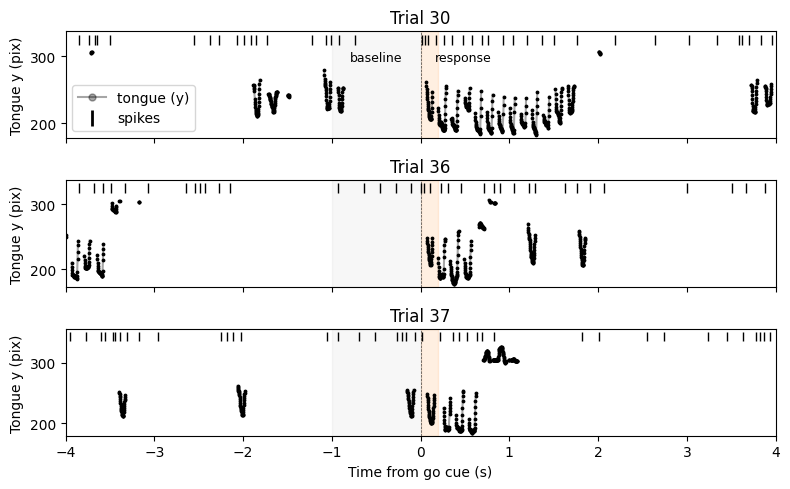

In [27]:
#plotting example trials with spikes and kins

# ---- choose trials to plot ----
trial_list = [30, 36, 37]   # <- change these as desired

go_col = "goCue_start_time_in_session"
win1 = 4.0
win2 = 4.0

fig, axes = plt.subplots(
    len(trial_list), 1,
    figsize=(8, 5),   # shorter height -> visually compressed y
    sharex=True
)

if len(trial_list) == 1:
    axes = [axes]

for ax, n in zip(axes, trial_list):
    # ---- get go cue time ----
    t0 = trials.loc[trials["trial"] == n, go_col].iloc[0]

    # ---- kinematic window ----
    mask_k = (kins["time_in_session"] >= t0 - win1) & (kins["time_in_session"] <= t0 + win2)
    kins_win = kins.loc[mask_k].copy()
    t_rel_k = kins_win["time_in_session"] - t0

    # ---- spike window ----
    spikes_arr = np.asarray(spikes)
    mask_s = (spikes_arr >= t0 - win1) & (spikes_arr <= t0 + win2)
    t_rel_s = spikes_arr[mask_s] - t0

    # ---- tongue signal: connect through NaNs within each movement_id ----
    # (plot each movement as its own line so we don't connect across movements)
    for mid, g in kins_win.groupby("movement_id", sort=False):
        # sort by time just in case
        g = g.sort_values("time_in_session")
        t_rel = g["time_in_session"] - t0

        # keep points for scatter (including NaNs is fine, they'll be skipped)
        ax.scatter(t_rel, g["y"], s=3, color="k", zorder=5)

        # for the line, drop NaNs so the line "bridges" missing detections
        g_line = g.dropna(subset=["y"])
        if len(g_line) >= 2:
            t_line = g_line["time_in_session"] - t0
            ax.plot(t_line, g_line["y"], alpha=0.35, color="k")

    # ---- spike raster above y-range ----
    ymin, ymax = kins_win["y"].min(), kins_win["y"].max()
    spike_y0 = ymax + 10
    spike_y1 = spike_y0 + 15

    for t in t_rel_s:
        ax.vlines(t, spike_y0, spike_y1, color="k", linewidth=1, zorder=10)

    # ---- shaded analysis windows (relative to go cue) ----
    base_a, base_b = cfg.baseline_window_s
    resp_a, resp_b = cfg.count_window_s

    ax.axvspan(base_a, base_b, color="0.75",alpha=0.12, zorder=0)
    ax.axvspan(resp_a, resp_b, color="tab:orange", alpha=0.12, zorder=0)

    # go cue marker
    ax.axvline(0, linestyle="--", color="0.25", linewidth=.5)

    # axis formatting for this subplot
    ax.set_xlim(-win1, win2)
    ax.set_ylim(ymin - 5, spike_y1 + 5)
    ax.set_ylabel("Tongue y (pix)")
    ax.set_title(f"Trial {n}")

# x-label on bottom axis only
axes[-1].set_xlabel("Time from go cue (s)")

# ---- Legend (top-left, only in top subplot) ----
spike_proxy = Line2D([0], [0],
                     linestyle="None",
                     marker="|",
                     color="k",
                     markersize=12,
                     markeredgewidth=2)
                     
tongue_proxy = Line2D([0], [0], color='k', marker='o',
                      markersize=5, linestyle='-', alpha=0.35)

axes[0].legend([tongue_proxy, spike_proxy],
               ["tongue (y)", "spikes"],
               loc="lower left")

# put baseline/response labels at fixed places in the axes
axes[0].text(0.4, 0.82, "baseline", transform=axes[0].transAxes,
        ha="left", va="top", fontsize=9)

axes[0].text(0.52, 0.82, "response", transform=axes[0].transAxes,
        ha="left", va="top", fontsize=9)

plt.tight_layout()

fname = "example_trials_with_kins"   # or build dynamically if you have multiple
png_path = fig_dir / f"{fname}.png"
svg_path = fig_dir / f"{fname}.svg"

if SAVE_FIG:
    fig_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.savefig(svg_path, dpi=300, bbox_inches="tight")
plt.show()


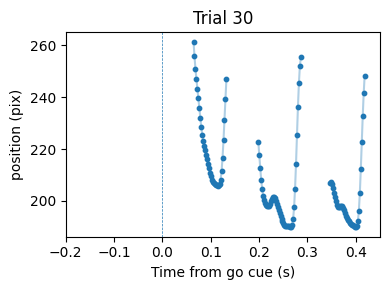

In [29]:
def plot_single_trial(
    trials,
    kins,
    trial_n,
    pre_go=2.0,
    post_go=3.0,
    y_col="y",
    go_col="goCue_start_time_in_session",
):
    # get go cue time
    t0 = trials.loc[trials["trial"] == trial_n, go_col].iloc[0]

    # restrict to window
    mask = (
        (kins["trial"] == trial_n) &
        (kins["time_in_session"] >= t0 - pre_go) &
        (kins["time_in_session"] <= t0 + post_go)
    )

    k = kins.loc[mask]
    t_rel = k["time_in_session"] - t0

    # plot
    plt.figure(figsize=(4, 3))
    plt.plot(t_rel, k[y_col], alpha=0.35)
    plt.scatter(t_rel, k[y_col], s=10)

    plt.axvline(0, linestyle="--", linewidth=0.5)
    plt.xlim(-pre_go, post_go)
    plt.xlabel("Time from go cue (s)")
    plt.ylabel("position (pix)")
    plt.title(f"Trial {trial_n}")
    plt.tight_layout()
    

plot_single_trial(trials, kins, trial_n=30, pre_go=.2, post_go=.45)

fname = "example_trial_zoom_for_reaction_time"   # or build dynamically if you have multiple
png_path = fig_dir / f"{fname}.png"
svg_path = fig_dir / f"{fname}.svg"

if SAVE_FIG:
    fig_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.savefig(svg_path, dpi=300, bbox_inches="tight")
plt.show()


### Core analysis functions

`prepare_df`, `analyze_unit_correlations`, `run_and_plot_for_predictor` — run per-unit Spearman correlations and produce summary plots.

In [ ]:


# ---------- Analysis ----------
def prepare_df(df_in: pd.DataFrame, x_col: str, y_col: str = "spike_count") -> tuple[pd.DataFrame, str]:
    """Drop NaNs for the chosen predictor and response; return cleaned df and a label."""
    label_map = {
        "reaction_time_firstmove": "first-move RT (s)",
        "reaction_time_cueresponse": "cue-response RT (s)",
        "first_spike_latency": "first-spike latency (s)",
    }
    df = df_in.dropna(subset=[x_col, y_col]).copy()
    return df, label_map.get(x_col, x_col)

def analyze_unit_correlations(df: pd.DataFrame, x_col: str, y_col: str = "spike_count",
                              min_trials: int = 3, alpha: float = 0.05) -> pd.DataFrame:
    rows = []
    for (uid, sess), g in df.groupby(["unit_id", "session"]):
        x = g[x_col].to_numpy()
        y = g[y_col].to_numpy()
        n = len(g)
        if n < min_trials:
            rows.append(
                {
                    "unit_id": uid,
                    "session": sess,
                    "n_trials": n,
                    "spearman_rho": np.nan,
                    "spearman_p": np.nan,
                    "pearson_r": np.nan,
                    "pearson_p": np.nan,
                }
            )
            continue

        rho, ps = spearmanr(x, y, nan_policy="omit")
        if np.nanstd(x) > 0 and np.nanstd(y) > 0:
            r, pp = pearsonr(x, y)
        else:
            r, pp = np.nan, np.nan

        rows.append(
            {
                "unit_id": uid,
                "session": sess,
                "n_trials": n,
                "spearman_rho": float(rho),
                "spearman_p": float(ps),
                "pearson_r": float(r),
                "pearson_p": float(pp),
            }
        )

    out = (
        pd.DataFrame(rows)
        .sort_values(["session", "unit_id"])
        .reset_index(drop=True)
    )

    # --- Add BH-FDR q-values + FDR flags (Spearman + Pearson) ---
    m_s = out["spearman_p"].notna()
    if m_s.any():
        _, q_s, _, _ = multipletests(
            out.loc[m_s, "spearman_p"].values, alpha=alpha, method="fdr_bh"
        )
        out.loc[m_s, "spearman_q"] = q_s
        out["spearman_sig_fdr"] = out["spearman_q"] < alpha
    else:
        out["spearman_q"] = np.nan
        out["spearman_sig_fdr"] = False

    m_p = out["pearson_p"].notna()
    if m_p.any():
        _, q_p, _, _ = multipletests(
            out.loc[m_p, "pearson_p"].values, alpha=alpha, method="fdr_bh"
        )
        out.loc[m_p, "pearson_q"] = q_p
        # separate flag from Spearman
        out["pearson_sig_fdr"] = out["pearson_q"] < alpha
    else:
        out["pearson_q"] = np.nan
        out["pearson_sig_fdr"] = False

    # --- derive t-statistics from correlations and n_trials ---
    def _corr_to_t(r_vec, n_vec):
        r_arr = np.asarray(r_vec, dtype=float)
        n_arr = np.asarray(n_vec, dtype=float)
        t_arr = np.full_like(r_arr, np.nan, dtype=float)

        mask = (
            np.isfinite(r_arr)
            & np.isfinite(n_arr)
            & (n_arr > 2)
            & (np.abs(r_arr) < 0.999999)
        )
        if np.any(mask):
            denom = np.maximum(1.0 - r_arr[mask] ** 2, 1e-12)
            t_arr[mask] = r_arr[mask] * np.sqrt((n_arr[mask] - 2.0) / denom)
        return t_arr

    n = out["n_trials"].to_numpy()

    # Approximate t-statistics for both Spearman rho and Pearson r (df = n-2)
    out["spearman_t"] = _corr_to_t(out["spearman_rho"].to_numpy(), n)
    out["pearson_t"]  = _corr_to_t(out["pearson_r"].to_numpy(),   n)

    return out



def pick_example_units(cor_df: pd.DataFrame, n: int = 3,
                       strategy: str = "top_abs", random_state: int = 0) -> list[tuple]:
    valid = cor_df.dropna(subset=["spearman_rho"])
    if valid.empty:
        return []
    if strategy == "random":
        ex = valid.sample(n=min(n, len(valid)), random_state=random_state)
    elif strategy == "top_neg":
        ex = valid.sort_values("spearman_rho").head(n)
    elif strategy == "top_pos":
        ex = valid.sort_values("spearman_rho", ascending=False).head(n)
    else:  # top_abs
        ex = valid.reindex(valid["spearman_rho"].abs().sort_values(ascending=False).index).head(n)
    return list(zip(ex["unit_id"], ex["session"]))

# ---------- Plotting ----------
def _add_regression_if_possible(ax, x, y, *, xscale="linear", eps=0.0):
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]

    if xscale == "log":
        # require positive x
        keep = x > 0
        x, y = x[keep], y[keep]
        if x.size < 2 or np.unique(x).size < 2:
            return

        x_fit = np.log10(x)  # or np.log(x); just be consistent
        m, b = np.polyfit(x_fit, y, 1)

        # draw line straight in log-x space
        xx = np.logspace(np.log10(np.min(x)), np.log10(np.max(x)), 200)
        ax.plot(xx, m * np.log10(xx) + b, lw=2)
        return

    # linear case
    if x.size >= 2 and np.unique(x).size >= 2:
        m, b = np.polyfit(x, y, 1)
        xx = np.linspace(np.min(x), np.max(x), 200)
        ax.plot(xx, m * xx + b, lw=2)



def plot_example_scatter(
    df: pd.DataFrame,
    examples: list[tuple],
    x_col: str,
    x_label: str,
    y_col: str = "spike_count",
    *,
    jitter_x: Union[float, str] = "auto",
    jitter_y: Union[float, str] = "auto",
    jitter_seed: int = 0,
    xscale: str = "linear",   
):
    """
    Scatter example units with optional jitter.
    """

    if not examples:
        print("No example units to plot.")
        return None

    rng = np.random.default_rng(jitter_seed)

    n = len(examples)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4), squeeze=False)

    for ax, (uid, sess) in zip(axes.ravel(), examples):
        g = df[(df["unit_id"] == uid) & (df["session"] == sess)]

        x = g[x_col].to_numpy()
        y = g[y_col].to_numpy()

        # --- if log scale, remove non-positive values ---
        if xscale == "log":
            keep = x > 0
            x = x[keep]
            y = y[keep]

        x_plot = x.copy()
        y_plot = y.copy()

        # --- auto detect integer-ish ---
        jy = jitter_y
        if jy == "auto":
            jy = 0.2 if np.all(np.isclose(y, np.round(y), atol=1e-6)) else 0.0

        jx = jitter_x
        if jx == "auto":
            jx = 0.2 if np.all(np.isclose(x, np.round(x), atol=1e-6)) else 0.0

        if isinstance(jx, (int, float)) and jx > 0:
            x_plot = x_plot + rng.normal(0, jx, size=len(x_plot))

        if isinstance(jy, (int, float)) and jy > 0:
            y_plot = y_plot + rng.normal(0, jy, size=len(y_plot))

        ax.scatter(x_plot, y_plot, s=20, alpha=0.2, edgecolors="none")

        _add_regression_if_possible(ax, x, y, xscale=xscale)

        ax.set_xscale(xscale)  

        ax.grid(True, ls=":", alpha=0.5)
        ax.set_title(f"{uid} ({sess}) • n={len(x)}")
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_col.replace("_", " "))

    fig.suptitle(f"Examples: {y_col} vs {x_label}", y=1.02)
    plt.tight_layout()

    return fig

def plot_summary_distribution(
    cor_df: pd.DataFrame,
    alpha: float = 0.05,
    x_label: str = "",
    y_label: str = "spike_count",
    volcano_uses_q: bool = True,  # kept for backward compatibility (unused)
    metric: str = "rho",
):
    """
    Single-panel summary plot: histogram of per-unit effect sizes,
    colored by significance.

    metric options (case-insensitive):

      - "rho" or "spearman_rho"  -> Spearman rho
      - "pearson_rho" or "pearson" -> Pearson r
      - "t" or "pearson_t"       -> Pearson t-statistic
      - "spearman_t"             -> Spearman t-statistic

    This keeps 'metric="rho"' and 'metric="t"' behavior logically
    compatible with the previous function, but uses a simpler
    one-panel visualization (the old middle panel).
    """
    m = metric.lower()

    if m in ("rho", "spearman_rho"):
        effect_col = "spearman_rho"
        p_col = "spearman_p"
        q_col = "spearman_q"
        effect_label = "Spearman ρ"
    elif m in ("pearson_rho", "pearson"):
        effect_col = "pearson_r"
        p_col = "pearson_p"
        q_col = "pearson_q"
        effect_label = "Pearson r"
    elif m in ("t", "pearson_t"):
        effect_col = "pearson_t"
        p_col = "pearson_p"
        q_col = "pearson_q"
        effect_label = "Pearson t-statistic"
    elif m in ("spearman_t",):
        effect_col = "spearman_t"
        p_col = "spearman_p"
        q_col = "spearman_q"
        effect_label = "Spearman t-statistic"
    else:
        raise ValueError(
            "Unknown metric '%s'. Expected one of: "
            "'rho', 'spearman_rho', 'pearson_rho', 'pearson', "
            "'t', 'pearson_t', 'spearman_t'." % metric
        )

    if effect_col not in cor_df.columns:
        print("No column '%s' in cor_df; nothing to plot for metric='%s'." % (effect_col, metric))
        return None

    # Drop rows with missing effect value
    valid = cor_df.dropna(subset=[effect_col]).copy()
    if valid.empty:
        print("No valid %s values to summarize." % effect_label)
        return None

    # Determine significance from q (preferred) or p
    have_q = (q_col in valid.columns) and valid[q_col].notna().any()
    if have_q:
        sig_mask = valid[q_col] < alpha
        sig_label = "sig (FDR)"
        nonsig_label = "not sig (FDR)"
    else:
        if p_col not in valid.columns:
            sig_mask = np.zeros(len(valid), dtype=bool)
            sig_label = "sig"
            nonsig_label = "not sig"
        else:
            sig_mask = valid[p_col] < alpha
            sig_label = "sig (p < %.3g)" % alpha
            nonsig_label = "not sig"

    vals = valid[effect_col].to_numpy()
    sig_vals = vals[sig_mask.to_numpy()]
    nonsig_vals = vals[~sig_mask.to_numpy()]

    fig, ax = plt.subplots(figsize=(5.5, 4))

    # Common bin edges so sig/nonsig histograms align
    bin_edges = np.histogram_bin_edges(vals, bins=20)

    # Build datasets & labels; stacked=True makes bar heights sum to total per bin
    datasets = [nonsig_vals, sig_vals]
    labels   = [nonsig_label, sig_label]

    ax.hist(
        datasets,
        bins=bin_edges,
        stacked=True,
        alpha=0.9,
        label=labels,
    )


    # Zero reference: meaningful for both corr and t
    ax.axvline(0.0, ls="--", lw=1)

    ax.set_xlabel(effect_label)
    ax.set_ylabel("Units")
    ax.grid(True, axis="y", ls=":", alpha=0.5)

    n_units = len(valid)
    n_sig = int(sig_mask.sum())
    ax.set_title(
        "%s vs %s\n%s (n=%d, sig=%d, α=%.3g)"
        % (y_label, x_label, effect_label, n_units, n_sig, alpha)
    )
    ax.legend(frameon=False, fontsize=8)

    # ---- enforce symmetric x-limits ----
    abs_max = np.nanmax(np.abs(vals))
    if np.isfinite(abs_max) and abs_max > 0:
        lim = abs_max * 1.05
        ax.set_xlim(-lim, lim)
    fig.tight_layout()
    return fig



def plot_summary_panels(
    cor_df: pd.DataFrame,
    alpha: float = 0.05,
    x_label: str = "",
    y_label: str = "spike_count",
    volcano_uses_q: bool = True,
    metric: str = "rho",  # NEW: "rho" (Spearman) or "t" (Pearson-derived t-stat)
):
    """
    Summary plots across units.

    metric:
        "rho" -> use Spearman ρ (existing behavior)
        "t"   -> use Pearson-derived t-statistics (column 'pearson_t')
    """
    # --- NEW: choose which effect size + stats to use ---
    if metric == "rho":
        effect_col = "spearman_rho"
        p_col = "spearman_p"
        q_col = "spearman_q"
        effect_label = "Spearman ρ"
    elif metric == "t":
        effect_col = "pearson_t"
        p_col = "pearson_p"
        q_col = "pearson_q"
        effect_label = "t-statistic (from Pearson r)"
    else:
        raise ValueError(f"Unknown metric '{metric}', expected 'rho' or 't'.")

    if effect_col not in cor_df.columns:
        print(f"No column '{effect_col}' in cor_df; nothing to plot for metric='{metric}'.")
        return None

    # require chosen effect_col; allow p/q to be missing but try to use q first
    valid = cor_df.dropna(subset=[effect_col]).copy()
    if valid.empty:
        print(f"No valid {effect_label} values to summarize.")
        return None

    have_q = (q_col in valid.columns) and valid[q_col].notna().any()
    # significance mask for counts + coloring (within valid)
    if have_q:
        sig_series = valid[q_col] < alpha
    else:
        sig_series = valid[p_col] < alpha

    n_units = len(valid)
    vals = valid[effect_col].to_numpy()
    pos_sig = int(((vals > 0) & sig_series.to_numpy()).sum())
    neg_sig = int(((vals < 0) & sig_series.to_numpy()).sum())

    # Volcano data
    if have_q and volcano_uses_q:
        finite = valid[q_col] > 0
        x_volc = valid.loc[finite, effect_col].to_numpy()
        y_volc = -np.log10(valid.loc[finite, q_col].to_numpy())
        sig_volc = (valid.loc[finite, q_col] < alpha).to_numpy()
        ylab_volc = "-log10(q)"
    else:
        finite = valid[p_col] > 0
        x_volc = valid.loc[finite, effect_col].to_numpy()
        y_volc = -np.log10(valid.loc[finite, p_col].to_numpy())
        sig_volc = (valid.loc[finite, p_col] < alpha).to_numpy()
        ylab_volc = "-log10(p)"
    pthr_y = -np.log10(alpha)

    # Sorted for lollipop
    vs = valid.sort_values(effect_col).reset_index(drop=True)
    ypos = np.arange(len(vs))
    if have_q:
        is_sig_sorted = (vs[q_col] < alpha).to_numpy()
    else:
        is_sig_sorted = (vs[p_col] < alpha).to_numpy()

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))

    # (1) Lollipop
    ax = axes[0]
    eff_vals_sorted = vs[effect_col].to_numpy()
    for i, v in enumerate(eff_vals_sorted):
        ax.hlines(i, 0, v, linewidth=1.0, alpha=0.7)
    ax.plot(
        eff_vals_sorted[~is_sig_sorted],
        ypos[~is_sig_sorted],
        "o",
        ms=4,
        alpha=0.8,
        label="not sig (FDR)",
    )
    ax.plot(
        eff_vals_sorted[is_sig_sorted],
        ypos[is_sig_sorted],
        "o",
        ms=4,
        alpha=0.9,
        color="orange",
        label="sig (FDR)",
    )
    ax.axvline(0, ls="--", lw=1)
    ax.set_yticks([])
    ax.set_xlabel(effect_label)
    ax.set_title(f"Per-unit {effect_label} (sorted)")
    ax.grid(True, axis="x", ls=":", alpha=0.5)

    # (2) Histogram colored by FDR
    ax = axes[1]
    bins = np.histogram_bin_edges(vals, bins=20)
    hist, edges = np.histogram(vals, bins=bins)
    hist_sig, _ = np.histogram(valid.loc[sig_series, effect_col], bins=bins)
    widths = np.diff(edges)
    ax.bar(
        edges[:-1],
        hist - hist_sig,
        width=widths,
        align="edge",
        alpha=0.7,
        label="not sig (FDR)",
    )
    ax.bar(
        edges[:-1],
        hist_sig,
        width=widths,
        align="edge",
        alpha=0.9,
        color="orange",
        label="sig (FDR)",
    )
    ax.axvline(0, ls="--", lw=1)
    val_max = np.max(np.abs(vals))
    ax.set_xlim(-val_max * 1.2, val_max * 1.2)
    ax.set_xlabel(effect_label)
    ax.set_ylabel("Units")
    ax.set_title(f"Distribution of {effect_label} (FDR coloring)")
    ax.grid(True, axis="y", ls=":", alpha=0.5)
    ax.legend(frameon=False, fontsize=8)

    # (3) Volcano
    ax = axes[2]
    ax.scatter(
        x_volc[~sig_volc],
        y_volc[~sig_volc],
        s=16,
        alpha=0.7,
        label="not sig (FDR)",
    )
    ax.scatter(
        x_volc[sig_volc],
        y_volc[sig_volc],
        s=16,
        alpha=0.9,
        color="orange",
        label="sig (FDR)",
    )
    ax.axhline(pthr_y, ls="--", lw=1)
    ax.set_xlabel(effect_label)
    ax.set_ylabel(ylab_volc)
    ax.set_title(f"{effect_label} vs significance (FDR)")
    ax.legend(frameon=False, fontsize=8)
    ax.grid(True, ls=":", alpha=0.5)

    fig.suptitle(
        f"{y_label} vs {x_label}  "
        f"({effect_label}, n={n_units}, FDR sig: pos={pos_sig}, neg={neg_sig}, α={alpha})",
        y=1.02,
    )
    plt.tight_layout()
    return fig


# ---------- Printed stats ----------
def print_summary_tests(cor_df: pd.DataFrame, alpha: float = 0.05):
    df = cor_df.copy()

    # Population-level tests (unchanged)
    sdf = df.dropna(subset=["spearman_rho"]).query("n_trials >= 3")
    rho = sdf["spearman_rho"].to_numpy()
    if len(rho) >= 3 and np.any(rho != 0):
        W, p_wil = wilcoxon(rho, alternative="two-sided", zero_method="wilcox")
        print(f"[Spearman ρ] Wilcoxon vs 0: W={W:.1f}, p={p_wil:.3g}, median={np.nanmedian(rho):.3f}, n_units={len(rho)}")
    else:
        print("[Spearman ρ] Not enough nonzero data for Wilcoxon.")

    neg = int(np.sum(rho < 0)); pos = int(np.sum(rho > 0))
    n_nonzero = neg + pos
    if n_nonzero > 0:
        p_sign = binomtest(neg, n_nonzero, 0.5, alternative="two-sided").pvalue
        print(f"[Spearman ρ] Sign test: negatives={neg}, positives={pos}, p={p_sign:.3g}, n_units={n_nonzero}")
    else:
        print("[Spearman ρ] No nonzero correlations for sign test.")

    pdf = df.dropna(subset=["pearson_r"]).query("n_trials >= 4")
    if not pdf.empty:
        r = np.clip(pdf["pearson_r"].to_numpy(), -0.999999, 0.999999)
        w = np.maximum(pdf["n_trials"].to_numpy() - 3, 1e-6)
        z = np.arctanh(r); z_bar = np.sum(w * z) / np.sum(w)
        se = 1.0 / np.sqrt(np.sum(w)); z_stat = z_bar / se
        from scipy.stats import norm
        p_meta = 2 * (1 - norm.cdf(abs(z_stat))); r_meta = np.tanh(z_bar)
        r_lo = np.tanh(z_bar - 1.96 * se); r_hi = np.tanh(z_bar + 1.96 * se)
        print(f"[Pearson r] Fisher-z meta: r_meta={r_meta:.3f} (95% CI {r_lo:.3f}..{r_hi:.3f}), z={z_stat:.2f}, p={p_meta:.3g}, n_units={len(pdf)}")
    else:
        print("[Pearson r] Not enough data for Fisher-z meta-analysis.")

    # FDR counts
    if "spearman_q" in df and df["spearman_q"].notna().any():
        sig = df["spearman_q"] < alpha
        pos_sig = int(((df["spearman_rho"] > 0) & sig).sum())
        neg_sig = int(((df["spearman_rho"] < 0) & sig).sum())
        print(f"[Per-unit FDR @ α={alpha}] sig units: total={int(sig.sum())}, pos={pos_sig}, neg={neg_sig}")
    else:
        print("[Per-unit FDR] No q-values present; ensure analyze_unit_correlations() added them.")


# ---------- Convenience runner for ANY predictor ----------
def run_and_plot_for_predictor(
    df_in: pd.DataFrame,
    x_col: str,
    *,
    y_col: str = "spike_count",
    example_n: int = 3,
    alpha: float = 0.05,
    filter_query=None,
    summary_metric: str = "rho",
):
    """Full pipeline for a given predictor column."""
    df0 = df_in.query(filter_query).copy() if filter_query else df_in
    df, x_label = prepare_df(df0, x_col=x_col, y_col=y_col)

    # pass alpha through so FDR in analyze_unit_correlations matches what you pass in
    cor_df = analyze_unit_correlations(
        df,
        x_col=x_col,
        y_col=y_col,
        min_trials=50,
        alpha=alpha,
    )

    examples = pick_example_units(
        cor_df,
        n=example_n,
        strategy="top_abs",
        random_state=0,
    )
    fig_examples = plot_example_scatter(
        df,
        examples,
        x_col=x_col,
        x_label=x_label,
        y_col=y_col,
    )

    # fig_summary = plot_summary_panels(
    #     cor_df,
    #     alpha=alpha,
    #     x_label=x_label,
    #     y_label=y_col,
    #     metric=summary_metric,
    # )

    fig_summary = plot_summary_distribution(
        cor_df,
        alpha=alpha,
        x_label=x_label,
        y_label=y_col,
        metric=summary_metric,
    )

    print_summary_tests(cor_df, alpha=alpha)
    return {
        "df": df,
        "cor_df": cor_df,
        "fig_examples": fig_examples,
        "fig_summary": fig_summary,
    }



No example units to plot.
[Spearman ρ] Wilcoxon vs 0: W=512.0, p=1.03e-12, median=-0.214, n_units=103
[Spearman ρ] Sign test: negatives=88, positives=15, p=9.65e-14, n_units=103
[Pearson r] Fisher-z meta: r_meta=-0.203 (95% CI -0.214..-0.193), z=-36.66, p=0, n_units=103
[Per-unit FDR @ α=0.05] sig units: total=68, pos=8, neg=60


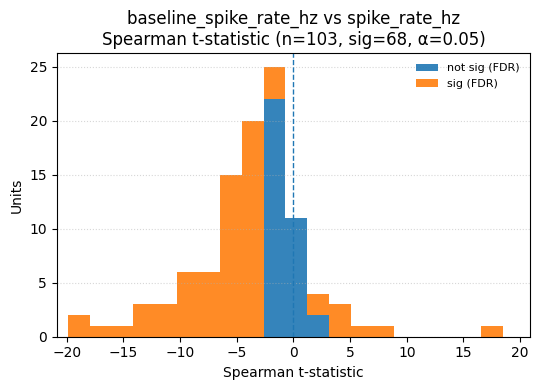

In [33]:
spkct_bl = run_and_plot_for_predictor(
    all_counts_df,
    x_col="spike_rate_hz",
    y_col="baseline_spike_rate_hz",
    example_n=0,
    alpha=0.05,
    filter_query="reaction_time_firstmove < 2",
    summary_metric='spearman_t'
)

if SAVE_FIG:
    FIG_DIR.mkdir(parents=True, exist_ok=True)

    spkct_bl["fig_summary"].savefig(FIG_DIR / "spkct_bl.png", dpi=300, bbox_inches="tight")
    spkct_bl["fig_summary"].savefig(FIG_DIR / "spkct_bl.svg", dpi=300, bbox_inches="tight")

No example units to plot.
[Spearman ρ] Wilcoxon vs 0: W=2558.0, p=0.693, median=0.002, n_units=103
[Spearman ρ] Sign test: negatives=50, positives=53, p=0.844, n_units=103
[Pearson r] Fisher-z meta: r_meta=0.036 (95% CI 0.025..0.047), z=6.33, p=2.48e-10, n_units=103
[Per-unit FDR @ α=0.05] sig units: total=32, pos=20, neg=12


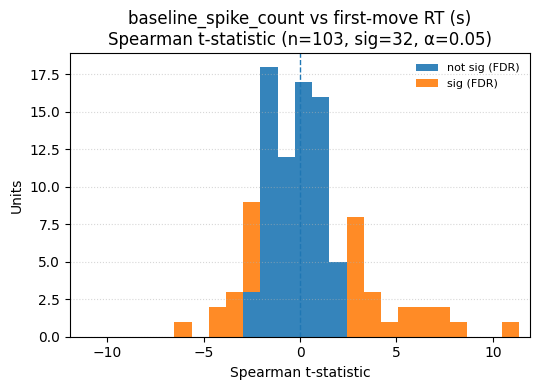

In [34]:
spkct_rt_bl = run_and_plot_for_predictor(
    all_counts_df,
    x_col="reaction_time_firstmove",
    y_col="baseline_spike_count",
    example_n=0,
    alpha=0.05,
    filter_query="reaction_time_firstmove < 2",
    summary_metric='spearman_t'
)

if SAVE_FIG:
    FIG_DIR.mkdir(parents=True, exist_ok=True)

    spkct_rt_bl["fig_summary"].savefig(FIG_DIR / "spkct_rt_bl.png", dpi=300, bbox_inches="tight")
    spkct_rt_bl["fig_summary"].savefig(FIG_DIR / "spkct_rt_bl.svg", dpi=300, bbox_inches="tight")

No example units to plot.
[Spearman ρ] Wilcoxon vs 0: W=2394.0, p=0.35, median=0.004, n_units=103
[Spearman ρ] Sign test: negatives=51, positives=52, p=1, n_units=103
[Pearson r] Fisher-z meta: r_meta=-0.011 (95% CI -0.022..-0.000), z=-2.00, p=0.045, n_units=103
[Per-unit FDR @ α=0.05] sig units: total=37, pos=22, neg=15


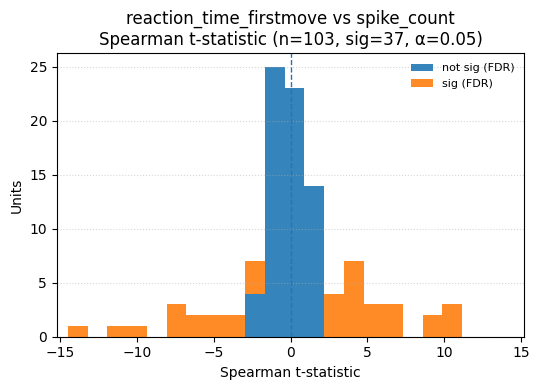

In [35]:
spkct_rt = run_and_plot_for_predictor(
    all_counts_df,
    x_col="spike_count",
    y_col="reaction_time_firstmove",
    example_n=0,
    alpha=0.05,
    filter_query="reaction_time_firstmove < 2",
    summary_metric='spearman_t'
)

if SAVE_FIG:
    FIG_DIR.mkdir(parents=True, exist_ok=True)

    spkct_rt["fig_summary"].savefig(FIG_DIR / "spkct_rt.png", dpi=300, bbox_inches="tight")
    spkct_rt["fig_summary"].savefig(FIG_DIR / "spkct_rt.svg", dpi=300, bbox_inches="tight")

No example units to plot.
[Spearman ρ] Wilcoxon vs 0: W=1938.0, p=0.0149, median=0.034, n_units=103
[Spearman ρ] Sign test: negatives=40, positives=63, p=0.0297, n_units=103
[Pearson r] Fisher-z meta: r_meta=0.022 (95% CI 0.010..0.033), z=3.63, p=0.000282, n_units=103
[Per-unit FDR @ α=0.05] sig units: total=18, pos=10, neg=8


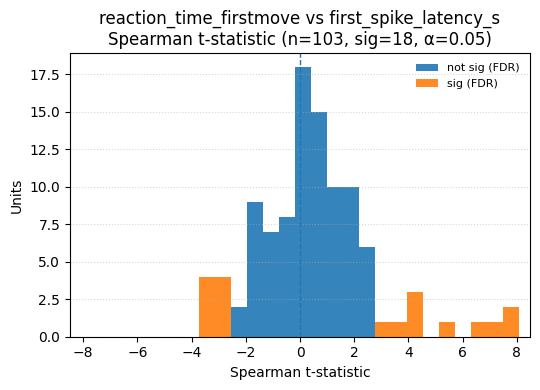

In [50]:
spklat_rt = run_and_plot_for_predictor(
    all_counts_df,
    x_col="first_spike_latency_s",
    y_col="reaction_time_firstmove",
    example_n=0,
    alpha=0.05,
    filter_query="reaction_time_firstmove < 2",
    summary_metric='spearman_t'
)

if SAVE_FIG:
    FIG_DIR.mkdir(parents=True, exist_ok=True)

    spklat_rt["fig_summary"].savefig(FIG_DIR / "spklat_rt.png", dpi=300, bbox_inches="tight")
    spklat_rt["fig_summary"].savefig(FIG_DIR / "spklat_rt.svg", dpi=300, bbox_inches="tight")

In [51]:
examples = pick_example_units(spkct_rt_bl["cor_df"], n=20, strategy="top_abs", random_state=0)
examples

[(89.0, 'behavior_784806_2025-06-20_13-39-16'),
 (14.0, 'behavior_751181_2025-02-25_12-12-35'),
 (100.0, 'behavior_782394_2025-04-24_12-07-34'),
 (145.0, 'behavior_751004_2024-12-23_14-20-03'),
 (85.0, 'behavior_758017_2025-02-06_11-26-14'),
 (22.0, 'behavior_751004_2024-12-21_13-28-28'),
 (29.0, 'behavior_751181_2025-02-25_12-12-35'),
 (193.0, 'behavior_751004_2024-12-21_13-28-28'),
 (72.0, 'behavior_784806_2025-06-20_13-39-16'),
 (46.0, 'behavior_751181_2025-02-27_11-24-47'),
 (6.0, 'behavior_751004_2024-12-21_13-28-28'),
 (44.0, 'behavior_758017_2025-02-07_14-11-08'),
 (40.0, 'behavior_751004_2024-12-20_13-26-11'),
 (367.0, 'behavior_782394_2025-04-24_12-07-34'),
 (45.0, 'behavior_763590_2025-05-01_10-59-18'),
 (28.0, 'behavior_751181_2025-02-27_11-24-47'),
 (15.0, 'behavior_758017_2025-02-07_14-11-08'),
 (55.0, 'behavior_791691_2025-06-27_13-54-30'),
 (373.0, 'behavior_782394_2025-04-24_12-07-34'),
 (649.0, 'behavior_784806_2025-06-20_13-39-16')]

In [52]:
examples = pick_example_units(spkct_rt["cor_df"], n=20, strategy="top_neg", random_state=0)
examples

[(22.0, 'behavior_751004_2024-12-21_13-28-28'),
 (145.0, 'behavior_751004_2024-12-23_14-20-03'),
 (193.0, 'behavior_751004_2024-12-21_13-28-28'),
 (649.0, 'behavior_784806_2025-06-20_13-39-16'),
 (6.0, 'behavior_751004_2024-12-21_13-28-28'),
 (146.0, 'behavior_751004_2024-12-23_14-20-03'),
 (72.0, 'behavior_784806_2025-06-20_13-39-16'),
 (263.0, 'behavior_751004_2024-12-20_13-26-11'),
 (123.0, 'behavior_751004_2024-12-22_13-09-17'),
 (268.0, 'behavior_751004_2024-12-20_13-26-11'),
 (16.0, 'behavior_754897_2025-03-14_11-28-53'),
 (28.0, 'behavior_751181_2025-02-27_11-24-47'),
 (45.0, 'behavior_763590_2025-05-01_10-59-18'),
 (29.0, 'behavior_751181_2025-02-25_12-12-35'),
 (87.0, 'behavior_716325_2024-05-31_10-31-14'),
 (89.0, 'behavior_784806_2025-06-20_13-39-16'),
 (13.0, 'behavior_751181_2025-02-27_11-24-47'),
 (14.0, 'behavior_763590_2025-05-01_10-59-18'),
 (144.0, 'behavior_751766_2025-02-13_11-31-21'),
 (56.0, 'behavior_791691_2025-06-27_13-54-30')]

,n_trials,spearman_rho,spearman_p,spearman_q,spearman_sig_fdr,pearson_r,pearson_p,pearson_q,pearson_sig_fdr
7,510,-0.541132,3.921965e-40,4.039624e-38,True,-0.364613,1.761014e-17,9.069222e-16,True


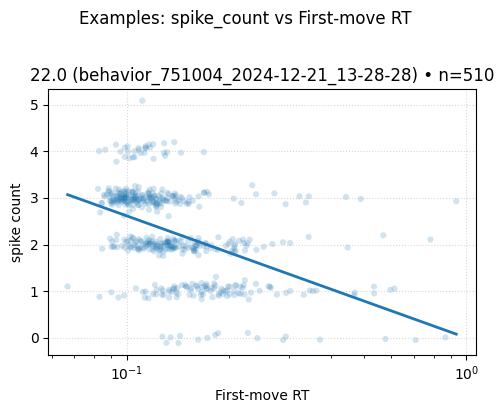

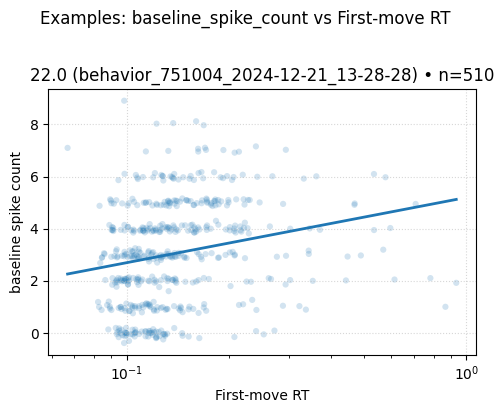

In [54]:
# unit_num = 649
# session_str = 'behavior_784806_2025-06-20_13-39-16'

# examples = [(unit_num, session_str)]

example = examples[0]

session_str = example[1]
unit_num = example[0]  

cor_row = spkct_rt["cor_df"].query(
    "session == @session_str and unit_id == @unit_num"
)

display(cor_row[[
    "n_trials", "spearman_rho", "spearman_p",
    "spearman_q", "spearman_sig_fdr",
    "pearson_r", "pearson_p", "pearson_q", "pearson_sig_fdr"
]])


fig = plot_example_scatter(
    df=spkct_rt["df"],
    examples=[examples[0]],
    x_col="reaction_time_firstmove",
    x_label="First-move RT",
    y_col="spike_count",
    xscale="log",
    jitter_y=0.1,
)
if SAVE_FIG and fig is not None:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIG_DIR / "example_unit_spkct_vs_rt.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIG_DIR / "example_unit_spkct_vs_rt.svg", dpi=300, bbox_inches="tight")    
plt.show()


fig = plot_example_scatter(
    df=spkct_rt_bl["df"],
    examples=[examples[0]],
    x_col="reaction_time_firstmove",
    x_label="First-move RT",
    y_col="baseline_spike_count",
    xscale="log",
    jitter_y=0.1,
)
if SAVE_FIG and fig is not None:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIG_DIR / "example_unit_spkct_vs_rt_bl.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIG_DIR / "example_unit_spkct_vs_rt_bl.svg", dpi=300, bbox_inches="tight")    
plt.show()

In [56]:
def plot_rt_discrete_three_groups(
    df: pd.DataFrame,
    cor_df: pd.DataFrame,
    *,
    rt_col: str = "reaction_time_firstmove",
    count_col: str = "spike_count",
    alpha: float = 0.05,
    max_spike_count: int = None,
    min_trials_per_bin: int = 5,  # Fix 3: require at least this many trials per (unit, bin)
):
    """
    Visualize mean RT vs discrete spike_count for units, categorized into
    pos/neg/none based on correlation + FDR significance.

    Normalization (Fix 1):
        rt_norm(k) = mean_rt(k) - mean_rt_unit_overall

    Fix 3:
        For a given (session, unit_id, spike_count), only include that
        bin for that unit if it has at least `min_trials_per_bin` trials.
    """
    key_cols = ["session", "unit_id"]

    # ---- trial-level cleanup ----
    df0 = df.dropna(subset=[rt_col, count_col]).copy()

    # only retain units in cor_df
    df0 = df0.merge(cor_df[key_cols].drop_duplicates(), on=key_cols, how="inner")

    if df0.empty:
        print("No overlapping units between df and cor_df.")
        fig, ax = plt.subplots()
        ax.text(0.5, 0.5, "No data", ha="center", va="center")
        ax.axis("off")
        return fig

    # ---- per-unit overall baseline RT (Fix 1) ----
    # mean RT across all trials for that unit
    baseline = (
        df0.groupby(key_cols)[rt_col]
           .mean()
    )  # Series indexed by (session, unit_id)

    # ---- unit × spike_count mean RT and trial count (for Fix 3) ----
    agg = (
        df0.groupby(key_cols + [count_col])[rt_col]
           .agg(["mean", "count"])
           .reset_index()
           .rename(columns={"mean": rt_col, "count": "n_trials_bin"})
    )

    # enforce minimum per-bin trial count (Fix 3)
    if min_trials_per_bin is not None and min_trials_per_bin > 1:
        agg = agg[agg["n_trials_bin"] >= min_trials_per_bin].copy()

    if agg.empty:
        print("No data left after applying min_trials_per_bin filter.")
        fig, ax = plt.subplots()
        ax.text(0.5, 0.5, "No data", ha="center", va="center")
        ax.axis("off")
        return fig

    g = agg

    # ---- decide max spike count, drop anything above it ----
    if max_spike_count is None:
        max_spike_count = int(g[count_col].max())
    g = g[g[count_col] <= max_spike_count].copy()

    if g.empty:
        print("No data within max_spike_count.")
        fig, ax = plt.subplots()
        ax.text(0.5, 0.5, "No data", ha="center", va="center")
        ax.axis("off")
        return fig

    x_vals = np.arange(0, max_spike_count + 1)

    # ---- normalized RT using overall baseline (Fix 1) ----
    def _norm_row(row):
        base = baseline.get((row.session, row.unit_id), np.nan)
        return row[rt_col] - base

    g["rt_norm"] = g.apply(_norm_row, axis=1)

    # ---- categories from cor_df ----
    c = cor_df.set_index(key_cols)

    if "spearman_sig_fdr" in c.columns:
        sig = c["spearman_sig_fdr"]
    elif "spearman_q" in c.columns:
        sig = c["spearman_q"] < alpha
    else:
        sig = c["spearman_p"] < alpha

    rho = c["spearman_rho"]

    cats = {}
    for key in c.index:
        if sig[key] and rho[key] > 0:
            cats[key] = "pos"
        elif sig[key] and rho[key] < 0:
            cats[key] = "neg"
        else:
            cats[key] = "none"

    # assign category to each row in g
    g["cat"] = [cats.get((row.session, row.unit_id), "none")
                for row in g.itertuples(index=False)]

    colors = {"pos": "tab:orange", "neg": "tab:blue", "none": "gray"}

    fig, ax = plt.subplots(figsize=(5.5, 4.3))
    rng = np.random.default_rng(0)

    # ---- jittered per-unit points using normalized RT ----
    for cat in ["neg", "pos"]:  # none in back
        sub = g[g["cat"] == cat]
        if sub.empty:
            continue
        xs = sub[count_col].to_numpy()
        ys = sub["rt_norm"].to_numpy()
        jitter = (rng.random(len(xs)) - 0.5) * 0.15
        ax.scatter(xs + jitter, ys, s=12, alpha=0.1,
                   color=colors[cat], label=None)

    # --- count unique units per category (for legend) ---
    unit_cats = g.drop_duplicates(subset=key_cols)["cat"].value_counts().to_dict()

    legend_labels = {
        "pos":  f"pos (n={unit_cats.get('pos', 0)})",
        "neg":  f"neg (n={unit_cats.get('neg', 0)})",
        "none": f"none (n={unit_cats.get('none', 0)})",
    }

    # --- grand mean ± SEM per group & spike_count (on rt_norm) ---
    for cat in ["pos", "neg"]:
        sub = g[g["cat"] == cat]
        if sub.empty:
            continue
        means = []
        sems = []
        for k in x_vals:
            y = sub.loc[sub[count_col] == k, "rt_norm"].to_numpy()
            if len(y) == 0:
                means.append(np.nan)
                sems.append(np.nan)
            else:
                means.append(np.nanmean(y))
                sems.append(np.nanstd(y, ddof=1) / np.sqrt(len(y)))
        means = np.array(means)
        sems = np.array(sems)

        ax.errorbar(
            x_vals, means, yerr=sems,
            fmt="o-", capsize=4,
            color=colors[cat],
            label=legend_labels[cat],
            alpha=0.9,
        )

    ax.set_xlabel(f"{count_col.replace('_',' ').title()} (window)")
    ax.set_ylabel(f"Δ {rt_col.replace('_',' ')} (s)\n(relative to unit mean RT)")
    ax.set_xticks(x_vals)
    ax.set_title("RT vs Spike Count per Unit (normalized)\nby correlation category")
    ax.grid(True, ls=":", alpha=0.4)
    ax.legend(frameon=False, fontsize=9, title="Unit group")
    plt.tight_layout()
    return fig


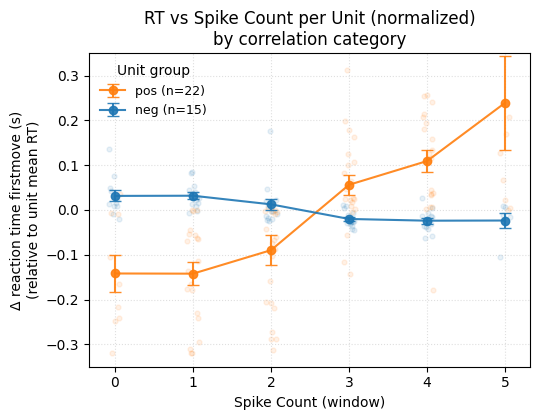

In [62]:
fig = plot_rt_discrete_three_groups(
    all_counts_df,
    spkct_rt["cor_df"],
    rt_col="reaction_time_firstmove",
    count_col="spike_count",
    alpha=0.05,
    max_spike_count=5,
    min_trials_per_bin=5,  # tweak as desired
)
plt.ylim(-.35, .35)

if SAVE_FIG:
    FIG_DIR.mkdir(parents=True, exist_ok=True)

    plt.savefig(FIG_DIR / "rt_by_spkct_groups.png", dpi=300, bbox_inches="tight")
    plt.savefig(FIG_DIR / "rt_by_spkct_groups.svg", dpi=300, bbox_inches="tight")

plt.show()


In [63]:
# # ---- Add per-unit RT~spike_count slope and visualize ----
# import numpy as np
# import matplotlib.pyplot as plt

# def add_rt_per_spike_slope(
#     df: pd.DataFrame,
#     cor_df: pd.DataFrame,
#     rt_col: str = "reaction_time_firstmove",
#     count_col: str = "spike_count",
#     min_trials: int = 10,
# ) -> pd.DataFrame:
#     """
#     For each (session, unit_id), fit RT ~ spike_count on trials and add
#     slope (sec per spike) to cor_df as 'slope_rt_per_spike'.

#     - x = spike_count
#     - y = RT  (in seconds)
#     - min_trials: minimum trials per unit to attempt a fit.
#     """
#     key_cols = ["session", "unit_id"]
#     df0 = df.dropna(subset=[rt_col, count_col]).copy()

#     rows = []
#     for (uid, sess), g in df0.groupby(["unit_id", "session"]):
#         n = len(g)
#         if n < min_trials:
#             rows.append(
#                 {"unit_id": uid, "session": sess, "slope_rt_per_spike": np.nan}
#             )
#             continue

#         x = g[count_col].to_numpy(dtype=float)  # spike count
#         y = g[rt_col].to_numpy(dtype=float)     # RT

#         if np.nanstd(x) == 0 or np.nanstd(y) == 0:
#             slope = np.nan
#         else:
#             X = np.column_stack([np.ones_like(x), x])  # intercept + slope
#             beta, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
#             slope = float(beta[1])  # seconds per spike

#         rows.append(
#             {"unit_id": uid, "session": sess, "slope_rt_per_spike": slope}
#         )

#     slopes = pd.DataFrame(rows)
#     out = cor_df.copy()
#     out = out.drop(columns=[c for c in out.columns if c.startswith("slope_rt_per_spike")], errors="ignore")
#     out = out.merge(slopes, on=key_cols, how="left")
#     return out


# # ---- compute slopes for this predictor ----
# spkct_rt["cor_df"] = add_rt_per_spike_slope(
#     spkct_rt["df"],
#     spkct_rt["cor_df"],
#     rt_col="reaction_time_firstmove",
#     count_col="spike_count",
#     min_trials=50,
# )

# cor_df = spkct_rt["cor_df"].copy()
# alpha = 0.05

# # keep only units with a defined slope
# valid = cor_df.dropna(subset=["slope_rt_per_spike"]).copy()
# if valid.empty:
#     print("No valid slope_rt_per_spike values to plot.")
# else:
#     # significance mask from Spearman q if present, else p
#     if "spearman_q" in valid.columns and valid["spearman_q"].notna().any():
#         sig_mask = valid["spearman_q"] < alpha
#         sig_label = "FDR-sig"
#         nonsig_label = "FDR-nonsig"
#     else:
#         sig_mask = valid["spearman_p"] < alpha
#         sig_label = "p-sig"
#         nonsig_label = "p-nonsig"

#     slopes = valid["slope_rt_per_spike"].to_numpy()
#     slopes_sig = slopes[sig_mask.to_numpy()]
#     slopes_nonsig = slopes[~sig_mask.to_numpy()]

#     # for symmetric x-limits
#     abs_max = np.nanmax(np.abs(slopes)) if len(slopes) else 1.0
#     if not np.isfinite(abs_max) or abs_max == 0:
#         abs_max = 1.0
#     xlim = abs_max * 1.1

#     fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

#     # ---- (1) Histogram of slopes (sig vs non-sig) ----
#     ax = axes[0]
#     bin_edges = np.histogram_bin_edges(slopes, bins=20)
#     datasets = [slopes_nonsig, slopes_sig]
#     labels = [nonsig_label, sig_label]

#     ax.hist(datasets, bins=bin_edges, stacked=True, alpha=0.9, label=labels)
#     ax.axvline(0.0, ls="--", lw=1, color="k")
#     ax.set_xlim(-xlim, xlim)
#     ax.set_xlabel("Slope: ΔRT per spike (s/spike)")
#     ax.set_ylabel("Units")
#     ax.set_title("Per-unit slopes (RT ~ spike_count)")
#     ax.legend(frameon=False, fontsize=8)
#     ax.grid(True, axis="y", ls=":", alpha=0.5)

#     # ---- (2) Slope vs Spearman rho ----
#     ax = axes[1]
#     rho = valid["spearman_rho"].to_numpy()
#     ax.scatter(rho[~sig_mask.to_numpy()], slopes_nonsig,
#                s=16, alpha=0.7, label=nonsig_label)
#     ax.scatter(rho[sig_mask.to_numpy()], slopes_sig,
#                s=16, alpha=0.9, label=sig_label)
#     ax.axhline(0.0, ls="--", lw=1, color="k")
#     ax.axvline(0.0, ls="--", lw=1, color="k")
#     ax.set_xlabel("Spearman ρ (RT vs spike_count)")
#     ax.set_ylabel("Slope (s/spike)")
#     ax.set_ylim(-xlim, xlim)
#     ax.set_title("Slope vs correlation per unit")
#     ax.legend(frameon=False, fontsize=8)
#     ax.grid(True, ls=":", alpha=0.5)

#     # ---- (3) Boxplot of slopes by sign of Spearman rho ----
#     ax = axes[2]
#     pos_mask = rho > 0
#     neg_mask = rho < 0
#     zero_mask = ~pos_mask & ~neg_mask

#     data_box = [
#         slopes[neg_mask],    # negative rho
#         slopes[zero_mask],   # near-zero rho
#         slopes[pos_mask],    # positive rho
#     ]
#     labels_box = [
#         "rho < 0",
#         "|rho| ≈ 0",
#         "rho > 0",
#     ]

#     ax.boxplot(data_box, labels=labels_box, showfliers=False)
#     ax.axhline(0.0, ls="--", lw=1, color="k")
#     ax.set_ylabel("Slope (s/spike)")
#     ax.set_ylim(-xlim, xlim)
#     ax.set_title("Slopes grouped by Spearman sign")
#     ax.grid(True, axis="y", ls=":", alpha=0.5)

#     fig.suptitle(
#         "Per-unit RT sensitivity to spikes\n"
#         f"(min_trials={50}, α={alpha})",
#         y=1.02,
#     )
#     plt.tight_layout()
#     plt.show()


In [65]:
def scatter_with_marginals_cor_compare(
    cor_df_a: pd.DataFrame,
    cor_df_b: pd.DataFrame,
    *,
    alpha: float = 0.05,
    label_a: str = "A (rate–RT)",
    label_b: str = "B (latency–RT)",
    use_spearman: bool = True,
    metric: str = "rho",       # "rho" or "t"
    bins: int = 20,
    figsize=(7, 7),
    title: str = None,
):
    """
    Compare two per-unit correlation tables (A vs B) with:
      - scatter of metric_A vs metric_B colored by significance category,
      - top/right marginal histograms showing sig vs non-sig for that axis.
    Uses FDR q if present; else falls back to raw p.

    metric : str
        "rho" → plot correlation coefficients (bounded [-1, 1])
        "t"   → plot t-statistics (unbounded, symmetric axes)
    """

    # --- column mapping ---
    col_map = {
        ("spearman", "rho"): ("spearman_rho", "Spearman ρ"),
        ("spearman", "t"):   ("spearman_t",   "Spearman t"),
        ("pearson",  "rho"): ("pearson_r",     "Pearson r"),
        ("pearson",  "t"):   ("pearson_t",     "Pearson t"),
    }
    method = "spearman" if use_spearman else "pearson"
    val_col, val_label = col_map[(method, metric)]
    p_col = f"{method}_p"
    q_col = f"{method}_q"

    xlab = f"{val_label} ({label_a})"
    ylab = f"{val_label} ({label_b})"

    # --- validate ---
    need = {"unit_id", "session", val_col, p_col}
    for name, df in [("cor_df_a", cor_df_a), ("cor_df_b", cor_df_b)]:
        missing = need - set(df.columns)
        if missing:
            raise ValueError(f"{name} missing columns: {missing}")

    # --- build merged table ---
    keep_a = ["unit_id", "session", val_col, p_col] + ([q_col] if q_col in cor_df_a.columns else [])
    keep_b = ["unit_id", "session", val_col, p_col] + ([q_col] if q_col in cor_df_b.columns else [])

    A = cor_df_a[keep_a].rename(columns={val_col: "val_a", p_col: "p_a", q_col: "q_a"}, errors="ignore")
    B = cor_df_b[keep_b].rename(columns={val_col: "val_b", p_col: "p_b", q_col: "q_b"}, errors="ignore")

    merged = pd.merge(A, B, on=["unit_id", "session"], how="inner")
    if merged.empty:
        raise ValueError("No overlapping (unit_id, session) between inputs.")

    # --- significance per axis (q preferred, else p) ---
    sig_a = (merged["q_a"] < alpha) if "q_a" in merged.columns else (merged["p_a"] < alpha)
    sig_b = (merged["q_b"] < alpha) if "q_b" in merged.columns else (merged["p_b"] < alpha)

    # --- significance categories ---
    def _cat(a, b):
        if a and b:       return "both"
        if a and not b:   return "A_only"
        if b and not a:   return "B_only"
        return "none"
    merged = merged.copy()
    merged["sig_category"] = [_cat(a, b) for a, b in zip(sig_a.values, sig_b.values)]

    # --- palette ---
    soft_red    = mcolors.to_rgba("#f4a582")
    soft_blue   = mcolors.to_rgba("#92c5de")
    intense_mix = mcolors.to_rgba("#b2182b")
    neutral     = mcolors.to_rgba("#d9d9d9")
    cat_colors  = {"both": intense_mix, "A_only": soft_red, "B_only": soft_blue, "none": neutral}

    # --- axis limits ---
    if metric == "rho":
        lo, hi = -1, 1
    else:
        finite = np.concatenate([
            merged["val_a"].dropna().values,
            merged["val_b"].dropna().values,
        ])
        bound = np.max(np.abs(finite)) * 1.05 if len(finite) else 5
        lo, hi = -bound, bound

    # --- layout ---
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 2, width_ratios=(4, 1.3), height_ratios=(1.3, 4),
                          wspace=0.05, hspace=0.05)
    ax_sc = fig.add_subplot(gs[1, 0])
    ax_tx = fig.add_subplot(gs[0, 0], sharex=ax_sc)
    ax_ry = fig.add_subplot(gs[1, 1], sharey=ax_sc)

    # --- scatter ---
    for cat, sub in merged.groupby("sig_category"):
        ax_sc.scatter(sub["val_a"], sub["val_b"], s=24, alpha=0.75,
                      color=cat_colors[cat], label=cat)

    ax_sc.set_xlim(lo, hi)
    ax_sc.set_ylim(lo, hi)
    ax_sc.set_aspect("equal", adjustable="box")
    ax_sc.axhline(0, lw=1, color="k", alpha=0.6)
    ax_sc.axvline(0, lw=1, color="k", alpha=0.6)
    ax_sc.set_xlabel(xlab)
    ax_sc.set_ylabel(ylab)
    ax_sc.legend(frameon=False, fontsize=9, title="Sig. category", loc="lower right")

    # --- best-fit line + annotation ---
    mask = np.isfinite(merged["val_a"]) & np.isfinite(merged["val_b"])
    if mask.sum() >= 2:
        r, p = pearsonr(merged.loc[mask, "val_a"], merged.loc[mask, "val_b"])
        m, b = np.polyfit(merged.loc[mask, "val_a"], merged.loc[mask, "val_b"], 1)
        xf = np.linspace(lo, hi, 200)
        ax_sc.plot(xf, m * xf + b, linestyle=":", color="black", lw=2.0)
        ax_sc.text(0.02, 0.98, f"y = {m:.2f}x + {b:.2f}\nr = {r:.2f}, p = {p:.2g}",
                   ha="left", va="top", transform=ax_sc.transAxes,
                   fontsize=9, bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))

    # --- marginal: top (A) ---
    x = merged["val_a"].to_numpy()
    bins_x = np.histogram_bin_edges(x[np.isfinite(x)], bins=bins)
    hist_all_x, edges_x = np.histogram(x, bins=bins_x)
    hist_sig_x, _       = np.histogram(merged.loc[sig_a, "val_a"], bins=bins_x)
    widths_x = np.diff(edges_x)
    ax_tx.bar(edges_x[:-1], hist_all_x - hist_sig_x, width=widths_x, align="edge",
              alpha=0.7, color="#cfcfcf", label="not sig (A)")
    ax_tx.bar(edges_x[:-1], hist_sig_x, width=widths_x, align="edge",
              alpha=0.9, color=soft_red, label="sig (A)")
    ax_tx.axvline(0, ls="--", lw=1, color="k")
    ax_tx.set_ylabel("Units")
    ax_tx.grid(True, axis="y", ls=":", alpha=0.5)
    plt.setp(ax_tx.get_xticklabels(), visible=False)
    ax_tx.tick_params(axis="x", which="both", bottom=False, top=False)

    # --- marginal: right (B) ---
    y = merged["val_b"].to_numpy()
    bins_y = np.histogram_bin_edges(y[np.isfinite(y)], bins=bins)
    hist_all_y, edges_y = np.histogram(y, bins=bins_y)
    hist_sig_y, _       = np.histogram(merged.loc[sig_b, "val_b"], bins=bins_y)
    widths_y = np.diff(edges_y)
    ax_ry.barh(edges_y[:-1], hist_all_y - hist_sig_y, height=widths_y, align="edge",
               alpha=0.7, color="#cfcfcf", label="not sig (B)")
    ax_ry.barh(edges_y[:-1], hist_sig_y, height=widths_y, align="edge",
               alpha=0.9, color=soft_blue, label="sig (B)")
    ax_ry.axhline(0, ls="--", lw=1, color="k")
    ax_ry.set_xlabel("Units")
    ax_ry.grid(True, axis="x", ls=":", alpha=0.5)
    plt.setp(ax_ry.get_yticklabels(), visible=False)
    ax_ry.tick_params(axis="y", which="both", left=False, right=False)

    if title:
        fig.suptitle(title, y=0.96)
    plt.tight_layout()
    return merged, fig

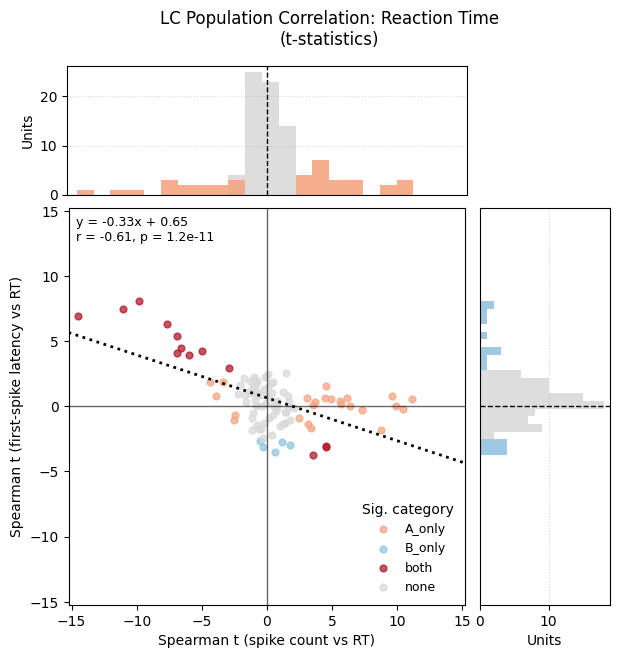

In [66]:
merged, fig = scatter_with_marginals_cor_compare(
    spkct_rt['cor_df'], spklat_rt['cor_df'],
    alpha=0.05,
    label_a="spike count vs RT",
    label_b="first-spike latency vs RT",
    use_spearman=True,
    metric="t",
    bins=20,
    title="LC Population Correlation: Reaction Time\n(t-statistics)",
)

In [67]:
# # ---- windows you want ----
# stops_ms = [50, 100, 150, 200, 250, 300]
# alpha = 0.05

# for stop_ms in stops_ms:
#     win = (0.0, stop_ms / 1000.0)

#     # (optional) reflect window in the title you already hard-coded
#     # If you want: add a title argument to scatter_with_marginals_cor_compare, otherwise ignore.

#     # --- (A) rebuild per-trial/unit table for this window ---
#     cfg = AnalysisConfig(
#         align_key="goCue",
#         count_window_s=win,
#         baseline_window_s=(-0.20, 0.0),
#         min_trials_per_group=20,
#     )

#     bundle_cache = {}
#     all_counts = []
#     for u in units_with_spikes.itertuples(index=False):
#         sess = u.session
#         if sess not in bundle_cache:
#             bundle_cache[sess] = make_session_bundle(sess, cfg)
#         all_counts.append(analyze_unit_for_session(pd.Series(u._asdict()), bundle_cache[sess], cfg))

#     all_counts_df = pd.concat(all_counts, ignore_index=True).sort_values(["session","unit_id","trial"])

#     # --- (B) run per-unit correlations for count and latency vs RT ---
#     spkct_rt = run_and_plot_for_predictor(
#         all_counts_df,
#         x_col="spike_count",
#         y_col="reaction_time_firstmove",
#         example_n=0,
#         alpha=alpha,
#         filter_query="reaction_time_firstmove < 2",
#         summary_metric="spearman_t",
#     )
#     spklat_rt = run_and_plot_for_predictor(
#         all_counts_df,
#         x_col="first_spike_latency_s",
#         y_col="reaction_time_firstmove",
#         example_n=0,
#         alpha=alpha,
#         filter_query="reaction_time_firstmove < 2",
#         summary_metric="spearman_t",
#     )

#     # --- (C) the compare plot you want ---
#     merged, fig = scatter_with_marginals_cor_compare(
#         spkct_rt["cor_df"], spklat_rt["cor_df"],
#         alpha=alpha,
#         label_a=f"spike count vs RT ({stop_ms} ms)",
#         label_b=f"first-spike latency vs RT ({stop_ms} ms)",
#         use_spearman=True,
#         bins=20,
#         figsize=(7,7),
#     )

#     if SAVE_FIG:
#         FIG_DIR.mkdir(parents=True, exist_ok=True)
#         fig.savefig(FIG_DIR / f"spklat_spkct_rt_corrs_marginals_{stop_ms}ms.png", dpi=300, bbox_inches="tight")
#         fig.savefig(FIG_DIR / f"spklat_spkct_rt_corrs_marginals_{stop_ms}ms.svg", dpi=300, bbox_inches="tight")

#     plt.show()


In [99]:



def compare_unit_correlations(
    cor_a: pd.DataFrame,
    cor_b: pd.DataFrame,
    *,
    label_a: str = "A (rate–RT)",
    label_b: str = "B (first-spike–RT)",
    use_spearman: bool = True,          # compare Spearman ρ by default
    alpha: float = 0.05,                # significance threshold
    use_fdr: bool = True,               # use q if available; else fall back to p
    sign_match_required: bool = False,  # only count overlap if signs agree
    save_fig: bool = False,
    fig_path: str = None
) -> pd.DataFrame:
    """
    Compare per-unit correlation results from two predictors (A vs B).
    Expects both cor_* to have columns: ['unit_id','session', 'spearman_rho','spearman_p', 'spearman_q'(opt),
                                         'pearson_r','pearson_p','pearson_q'(opt)]
    Returns merged table with convenient columns and a 'sig_category' label.
    """

    # --- small logging helper so we can also save to txt ---
    lines = []
    def log(msg: str = ""):
        print(msg)
        lines.append(msg)

    # --- pick columns to compare ---
    if use_spearman:
        a_rho_col, a_p_col, a_q_col = "spearman_rho", "spearman_p", "spearman_q"
        b_rho_col, b_p_col, b_q_col = "spearman_rho", "spearman_p", "spearman_q"
        xlab = f"Spearman ρ ({label_a})"; ylab = f"Spearman ρ ({label_b})"
    else:
        a_rho_col, a_p_col, a_q_col = "pearson_r", "pearson_p", "pearson_q"
        b_rho_col, b_p_col, b_q_col = "pearson_r", "pearson_p", "pearson_q"
        xlab = f"Pearson r ({label_a})"; ylab = f"Pearson r ({label_b})"

    # --- rename for clarity, then inner-join on unit/session ---
    need = {"unit_id","session", a_rho_col, a_p_col}
    for name, df in [("cor_a", cor_a), ("cor_b", cor_b)]:
        miss = need - set(df.columns)
        if miss:
            raise ValueError(f"{name} missing columns: {miss}")

    A = cor_a.rename(columns={a_rho_col:"rho_a", a_p_col:"p_a"}).copy()
    B = cor_b.rename(columns={b_rho_col:"rho_b", b_p_col:"p_b"}).copy()
    if a_q_col in A.columns: A = A.rename(columns={a_q_col:"q_a"})
    if b_q_col in B.columns: B = B.rename(columns={b_q_col:"q_b"})

    merged = pd.merge(
        A[["unit_id","session","rho_a","p_a"] + (["q_a"] if "q_a" in A.columns else [])],
        B[["unit_id","session","rho_b","p_b"] + (["q_b"] if "q_b" in B.columns else [])],
        on=["unit_id","session"],
        how="inner"
    )
    if merged.empty:
        raise ValueError("No overlapping (unit_id, session) between inputs.")

    # --- across-units correspondence of effect sizes ---
    mask_valid = merged[["rho_a","rho_b"]].notna().all(axis=1)
    if mask_valid.any():
        rho_s, p_s = spearmanr(
            merged.loc[mask_valid,"rho_a"],
            merged.loc[mask_valid,"rho_b"],
            nan_policy="omit",
        )
        r_p, p_p   = pearsonr(
            merged.loc[mask_valid,"rho_a"],
            merged.loc[mask_valid,"rho_b"],
        )
        log(f"[Across units] Spearman(rho_a, rho_b) = {rho_s:.3f} (p={p_s:.3g})   n={int(mask_valid.sum())}")
        log(f"[Across units] Pearson (rho_a, rho_b) = {r_p:.3f} (p={p_p:.3g})")
    else:
        log("[Across units] Not enough finite effect sizes for correlation.")

    # --- significance (FDR-first, then raw p) ---
    if use_fdr and ("q_a" in merged or "q_b" in merged):
        sig_a = (merged["q_a"] < alpha) if "q_a" in merged else (merged["p_a"] < alpha)
        sig_b = (merged["q_b"] < alpha) if "q_b" in merged else (merged["p_b"] < alpha)
        sig_label = "FDR"
    else:
        sig_a = merged["p_a"] < alpha
        sig_b = merged["p_b"] < alpha
        sig_label = "raw p"

    if sign_match_required:
        sign_match = np.sign(merged["rho_a"]) == np.sign(merged["rho_b"])
        both_sig = sig_a & sig_b & sign_match
    else:
        both_sig = sig_a & sig_b

    either_sig = sig_a | sig_b  # (kept in case you want later logic)

    log("\n--- Significance summary ---")
    log(f"Units (merged): {len(merged)}")
    log(f"Significant in {label_a} [{sig_label}< {alpha}]: {int(sig_a.sum())}")
    log(f"Significant in {label_b} [{sig_label}< {alpha}]: {int(sig_b.sum())}")
    log(f"Both significant{(' (sign-consistent)' if sign_match_required else '')}: {int(both_sig.sum())}")

    # contingency + Fisher exact (2x2)
    cont = pd.crosstab(sig_a, sig_b)
    for v in [False, True]:
        if v not in cont.index:   cont.loc[v] = 0
        if v not in cont.columns: cont[v] = 0
    cont = cont.sort_index(axis=0).sort_index(axis=1)
    odds, p_fish = fisher_exact(cont.values)

    log("\nContingency table (rows=A sig, cols=B sig):")
    log(str(cont))
    log(f"Fisher exact: odds={odds:.2f}, p={p_fish:.3g}")

    # --- categorize units ---
    def _cat(row):
        a = bool(row["_sig_a"]); b = bool(row["_sig_b"])
        if sign_match_required and a and b and np.sign(row["rho_a"]) != np.sign(row["rho_b"]):
            a_only = a and not b
            b_only = b and not a
            return "A_only" if a_only else ("B_only" if b_only else "none")
        if a and b: return "both"
        if a:       return "A_only"
        if b:       return "B_only"
        return "none"

    merged = merged.copy()
    merged["_sig_a"] = sig_a.values
    merged["_sig_b"] = sig_b.values
    merged["sig_category"] = merged.apply(_cat, axis=1)

    log("\nCategory counts:")
    log(str(merged["sig_category"].value_counts()))

    # ---------- Plot ----------
    fig, ax = plt.subplots(figsize=(6, 6))

    soft_red    = mcolors.to_rgba("#f4a582")   # A_only
    soft_blue   = mcolors.to_rgba("#92c5de")   # B_only
    intense_mix = mcolors.to_rgba("#b2182b")   # both
    neutral     = mcolors.to_rgba("#d9d9d9")   # none

    cat_colors = {
        "both":   intense_mix,
        "A_only": soft_red,
        "B_only": soft_blue,
        "none":   neutral,
    }

    for cat, sub in merged.groupby("sig_category"):
        ax.scatter(sub["rho_a"], sub["rho_b"], alpha=0.75, label=cat, s=24,
                   color=cat_colors.get(cat, "lightgray"))

    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_aspect("equal")

    xy_ok = np.isfinite(merged["rho_a"]) & np.isfinite(merged["rho_b"])
    if xy_ok.sum() >= 2:
        m, b = np.polyfit(merged.loc[xy_ok,"rho_a"], merged.loc[xy_ok,"rho_b"], 1)
        xfit = np.linspace(-1, 1, 200)
        yfit = m * xfit + b
        ax.plot(xfit, yfit, linestyle=":", color="black", linewidth=2.0)

    ax.axhline(0, lw=1, color="k", alpha=0.6)
    ax.axvline(0, lw=1, color="k", alpha=0.6)

    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ttl_extra = " [sign-consistent overlap]" if sign_match_required else ""
    ax.set_title(f"Per-unit correspondence of correlations{ttl_extra}")
    ax.legend(frameon=False, fontsize=9, title="Sig. category")
    fig.tight_layout()

    # --- saving: PNG, SVG, TXT ---
    if save_fig and fig_path is not None:
        fig_path = Path(fig_path)
        fig_path.parent.mkdir(parents=True, exist_ok=True)

        for ext in ("png", "svg"):
            fig.savefig(
                fig_path.with_suffix(f".{ext}"),
                dpi=300,
                bbox_inches="tight",
            )

        txt_path = fig_path.with_suffix(".txt")
        with txt_path.open("w") as f:
            f.write("\n".join(lines) + "\n")

        log(f"\nSaved figure(s) and stats to:\n  {fig_path.with_suffix('.png')}\n  {fig_path.with_suffix('.svg')}\n  {txt_path}")
    else:
        plt.show()

    # Clean up helper columns before returning
    return merged.drop(columns=["_sig_a","_sig_b"], errors="ignore")


[Across units] Spearman(rho_a, rho_b) = -0.437 (p=4.02e-06)   n=103
[Across units] Pearson (rho_a, rho_b) = -0.396 (p=3.4e-05)

--- Significance summary ---
Units (merged): 103
Significant in rate–RT [FDR< 0.05]: 37
Significant in first-spike–RT [FDR< 0.05]: 18
Both significant: 13

Contingency table (rows=A sig, cols=B sig):
q_b    False  True 
q_a                
False     61      5
True      24     13
Fisher exact: odds=6.61, p=0.000793

Category counts:
sig_category
none      61
A_only    24
both      13
B_only     5
Name: count, dtype: int64


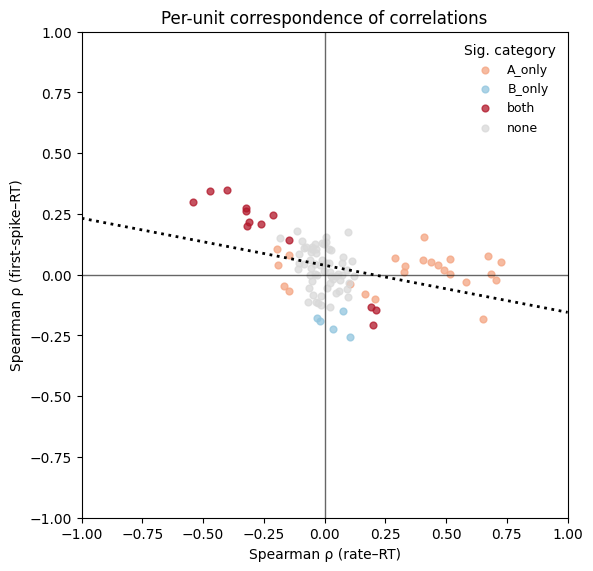

In [100]:
merged = compare_unit_correlations(
    cor_df_count, cor_df_lat,
    label_a="rate–RT", label_b="first-spike–RT",
    use_spearman=True,      # or False to compare Pearson r instead
    alpha=0.05,
    use_fdr=True,           # use q if present; else fall back to p
    sign_match_required=False,
    save_fig=SAVE_FIG,
    fig_path=FIG_DIR / "spklat_spkct_rt_corrs"
)

# Optional: save the merged comparison table
# merged.to_csv("rate_vs_firstspike_RTcorr_merged.csv", index=False)


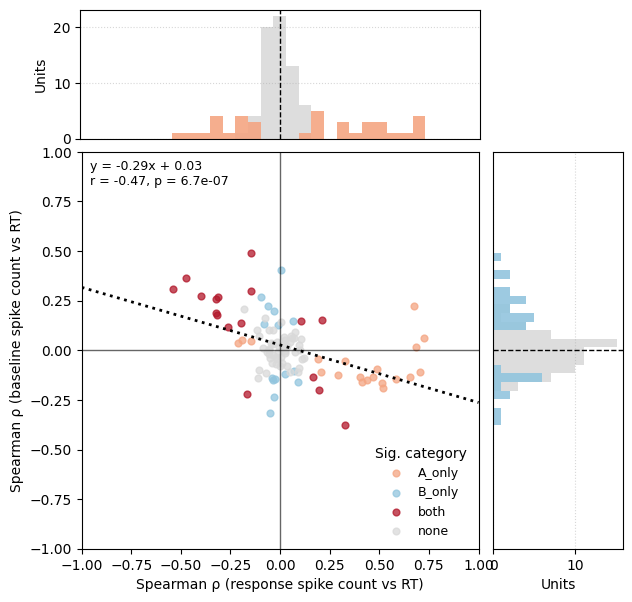

[Across units] Spearman(rho_a, rho_b) = -0.470 (p=5.33e-07)   n=103
[Across units] Pearson (rho_a, rho_b) = -0.467 (p=6.7e-07)

--- Significance summary ---
Units (merged): 103
Significant in response–RT [FDR< 0.05]: 37
Significant in baseline–RT [FDR< 0.05]: 32
Both significant: 17

Contingency table (rows=A sig, cols=B sig):
q_b    False  True 
q_a                
False     51     15
True      20     17
Fisher exact: odds=2.89, p=0.0255

Category counts:
sig_category
none      51
A_only    20
both      17
B_only    15
Name: count, dtype: int64


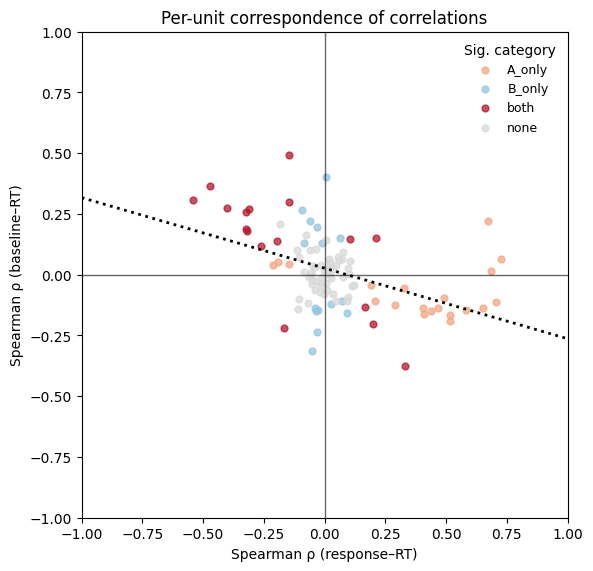

In [101]:
# compare baseline to response window correlations with spike count

cor_df_count = spkct_rt["cor_df"]
cor_df_count_bl = spkct_rt_bl["cor_df"]

merged, fig = scatter_with_marginals_cor_compare(
    cor_df_count, cor_df_count_bl,
    alpha=0.05,
    label_a="response spike count vs RT",
    label_b="baseline spike count vs RT",
    use_spearman=True,  # or False for Pearson r tables
    bins=20
)
if SAVE_FIG:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIG_DIR / "spkctbl_spkct_rt_corrs_marginals.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIG_DIR / "spkctbl_spkct_rt_corrs_marginals.svg", dpi=300, bbox_inches="tight")

plt.show()



merged = compare_unit_correlations(
    cor_df_count, cor_df_count_bl,
    label_a="response–RT", label_b="baseline–RT",
    use_spearman=True,      # or False to compare Pearson r instead
    alpha=0.05,
    use_fdr=True,           # use q if present; else fall back to p
    sign_match_required=False,
    save_fig=SAVE_FIG,
    fig_path=FIG_DIR / "spkctbl_spkct_rt_corrs"
)

### Kinematic correlations & pairwise significance

Correlate spike count with tongue kinematics features (endpoint, velocity, angle). Pairwise Fisher tests on significance overlap.

In [103]:
all_counts_df["first_move_excursion_angle_deg_abs"] = all_counts_df["first_move_excursion_angle_deg"].abs()
all_counts_df.columns

Index(['trial', 'unit_id', 'session', 'align_key', 'win_start_s', 'win_stop_s',
       'spike_count', 'spike_rate_hz', 'baseline_spike_count',
       'baseline_spike_rate_hz', 'delta_spike_count', 'lat_win_start_s',
       'lat_win_stop_s', 'first_spike_latency_s', 'had_spike_in_latency_win',
       'cue_response_movement_number', 'reaction_time_firstmove',
       'reaction_time_cueresponse', 'first_move_peak_velocity',
       'first_move_duration', 'first_move_excursion_angle_deg',
       'first_move_endpoint_x', 'first_move_endpoint_y',
       'first_move_out_duration', 'first_move_out_peak_velocity',
       'first_move_out_mean_velocity', 'first_move_out_total_distance',
       'cue_response_peak_velocity', 'cue_response_duration',
       'cue_response_excursion_angle_deg', 'cue_response_endpoint_x',
       'cue_response_endpoint_y', 'cue_response_out_duration',
       'cue_response_out_peak_velocity', 'cue_response_out_mean_velocity',
       'cue_response_out_total_distance',
     

No example units to plot.
[Spearman ρ] Wilcoxon vs 0: W=2394.0, p=0.35, median=0.004, n_units=103
[Spearman ρ] Sign test: negatives=51, positives=52, p=1, n_units=103
[Pearson r] Fisher-z meta: r_meta=-0.011 (95% CI -0.022..-0.000), z=-2.00, p=0.045, n_units=103
[Per-unit FDR @ α=0.05] sig units: total=37, pos=22, neg=15
No example units to plot.
[Spearman ρ] Wilcoxon vs 0: W=2311.0, p=0.227, median=0.003, n_units=103
[Spearman ρ] Sign test: negatives=51, positives=52, p=1, n_units=103
[Pearson r] Fisher-z meta: r_meta=-0.006 (95% CI -0.017..0.005), z=-1.09, p=0.276, n_units=103
[Per-unit FDR @ α=0.05] sig units: total=45, pos=30, neg=15
No example units to plot.
[Spearman ρ] Wilcoxon vs 0: W=2575.0, p=0.735, median=-0.017, n_units=103
[Spearman ρ] Sign test: negatives=57, positives=46, p=0.324, n_units=103
[Pearson r] Fisher-z meta: r_meta=-0.040 (95% CI -0.051..-0.029), z=-7.11, p=1.14e-12, n_units=103
[Per-unit FDR @ α=0.05] sig units: total=45, pos=19, neg=26


KeyError: ['first_move_mean_velocity']

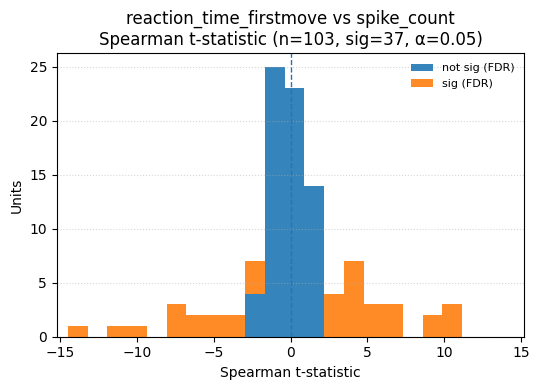

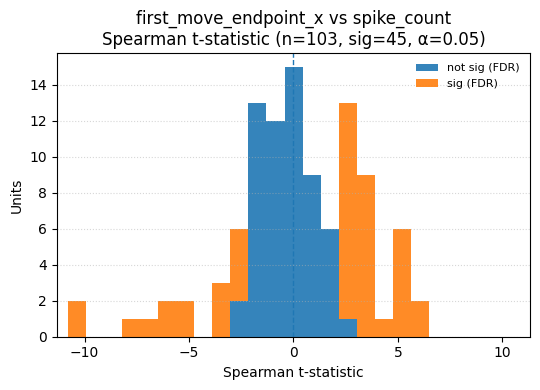

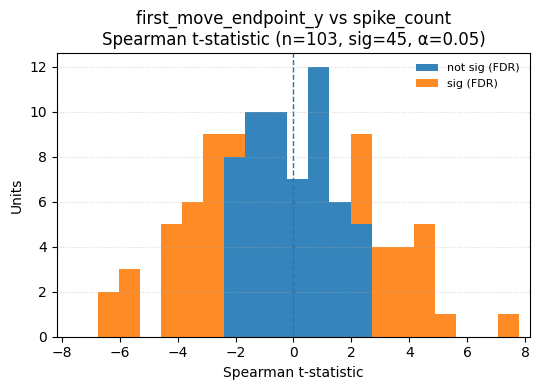

In [104]:
pairs = [
    "reaction_time_firstmove",
    "first_move_endpoint_x",
    "first_move_endpoint_y",
    "first_move_mean_velocity",
    "first_move_excursion_angle_deg_abs",
    "first_move_peak_velocity",
    "first_move_out_duration",
    "first_move_out_peak_velocity",
    "first_move_out_mean_velocity",
    "first_move_out_total_distance",
]

for y_col in pairs:
    res = run_and_plot_for_predictor(
        all_counts_df,
        x_col="spike_count",
        y_col=y_col,
        example_n=0,  # << no example panels
        alpha=0.05,
        filter_query="reaction_time_firstmove < 1",
        summary_metric="spearman_t",
    )

    if SAVE_FIG:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        fig = res["fig_summary"]
        fname = f"spike_count_vs_{y_col}_summary".replace(" ", "_")
        fig.savefig(FIG_DIR / f"{fname}.png", dpi=300, bbox_inches="tight")
        fig.savefig(FIG_DIR / f"{fname}.svg", dpi=300, bbox_inches="tight")
        print(f"Saved: {fname}.png/.svg")


No example units to plot.
[Spearman ρ] Wilcoxon vs 0: W=2394.0, p=0.35, median=0.004, n_units=103
[Spearman ρ] Sign test: negatives=51, positives=52, p=1, n_units=103
[Pearson r] Fisher-z meta: r_meta=-0.011 (95% CI -0.022..-0.000), z=-2.00, p=0.045, n_units=103
[Per-unit FDR @ α=0.05] sig units: total=37, pos=22, neg=15
No example units to plot.
[Spearman ρ] Wilcoxon vs 0: W=2311.0, p=0.227, median=0.003, n_units=103
[Spearman ρ] Sign test: negatives=51, positives=52, p=1, n_units=103
[Pearson r] Fisher-z meta: r_meta=-0.006 (95% CI -0.017..0.005), z=-1.09, p=0.276, n_units=103
[Per-unit FDR @ α=0.05] sig units: total=45, pos=30, neg=15
No example units to plot.
[Spearman ρ] Wilcoxon vs 0: W=2575.0, p=0.735, median=-0.017, n_units=103
[Spearman ρ] Sign test: negatives=57, positives=46, p=0.324, n_units=103
[Pearson r] Fisher-z meta: r_meta=-0.040 (95% CI -0.051..-0.029), z=-7.11, p=1.14e-12, n_units=103
[Per-unit FDR @ α=0.05] sig units: total=45, pos=19, neg=26
No example units to pl

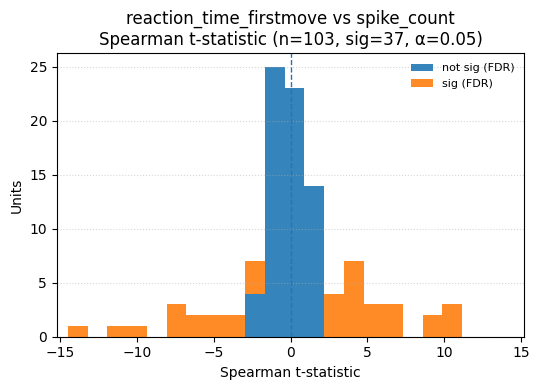

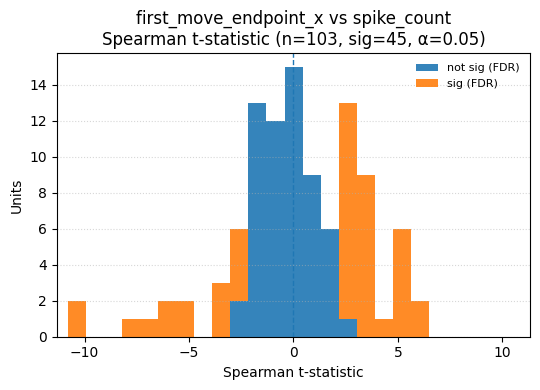

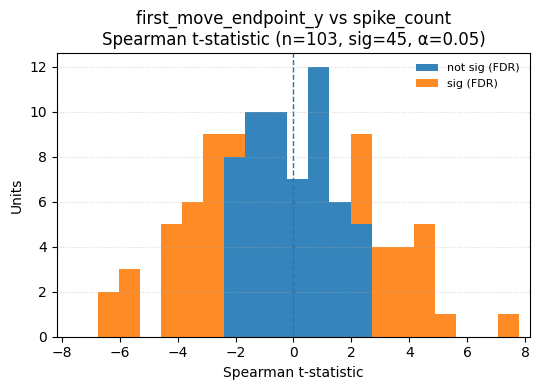

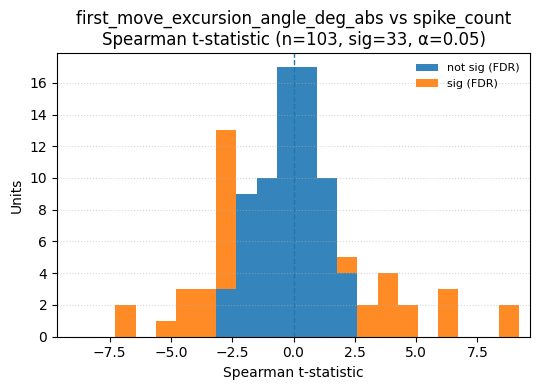

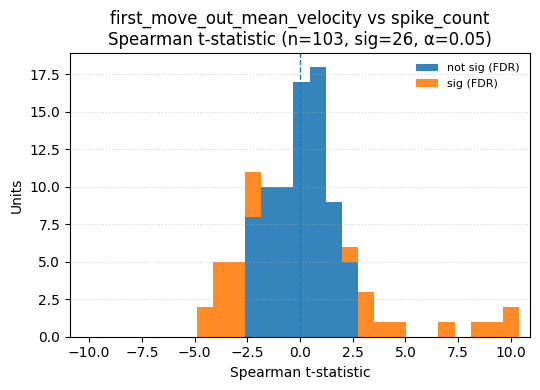

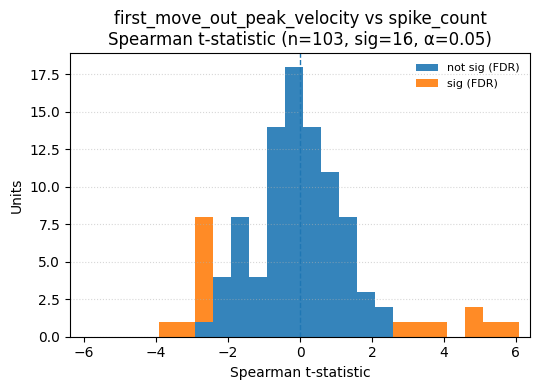

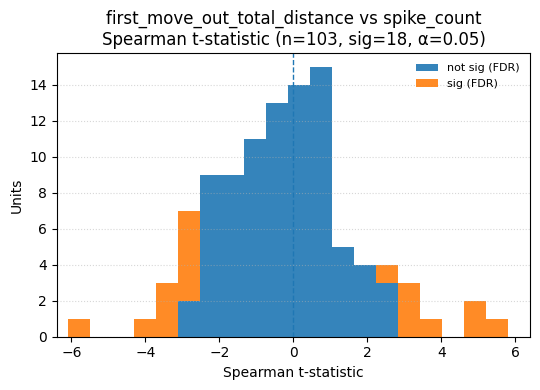

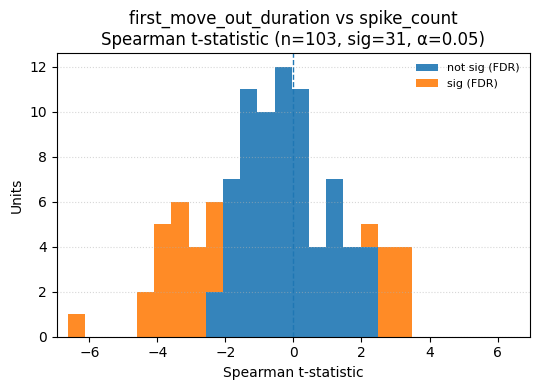

In [ ]:
pairs = {
    "RT":  "reaction_time_firstmove",
    "endptx": "first_move_endpoint_x",
    "endpty": "first_move_endpoint_y",
    "angle":  "first_move_excursion_angle_deg_abs",
    "meanv":  "first_move_out_mean_velocity",
    "peakv":  "first_move_out_peak_velocity",
    "distance": "first_move_out_total_distance",
    "duration": "first_move_out_duration",
}

dfs = {}

for key, y_col in pairs.items():
    res = run_and_plot_for_predictor(
        all_counts_df,
        x_col="spike_count",
        y_col=y_col,
        example_n=0,                 # no examples
        alpha=0.05,
        filter_query="reaction_time_firstmove < 1",
        summary_metric="spearman_t",
    )
    dfs[key] = res["cor_df"]


# --- Build significance table: (session, unit_id) × variable_name -> True/False ---

sig_series = {}
for name, df in dfs.items():
    s = (
        df
        .set_index(['session', 'unit_id'])['spearman_sig_fdr']
        .astype(bool)           # ensure bool dtype
    )
    sig_series[name] = s

sig_df = pd.concat(sig_series, axis=1)
sig_df = sig_df.fillna(False)   # if some units are missing in some dfs

# optional: count how many categories are significant per unit
sig_df['n_sig'] = sig_df.sum(axis=1)

# example: how many units are significant for RT
n_sig_RT = sig_df['RT'].sum()
print("RT significant units:", n_sig_RT)

# example: how many units are significant in any category
n_sig_any = (sig_df.drop(columns='n_sig').any(axis=1)).sum()
print("Units significant in ≥1 category:", n_sig_any)


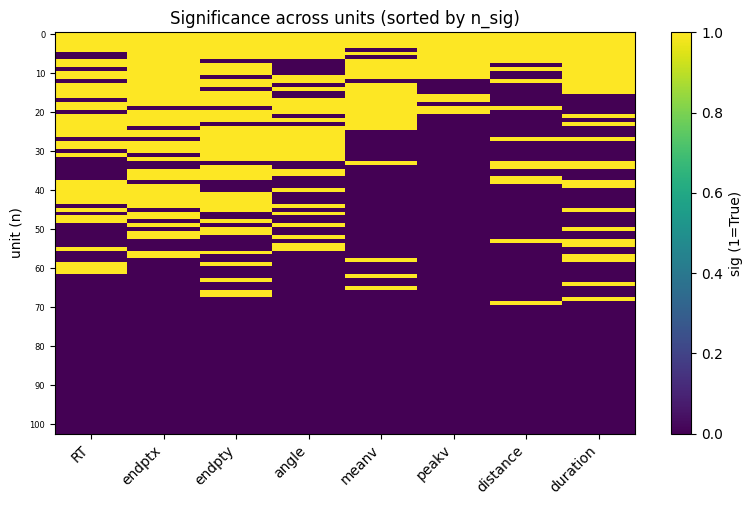

In [ ]:
def plot_significance_heatmap_ticks(sig_df, k=10, drop_zero=False, sort=True):
    bool_cols = [c for c in sig_df.columns if sig_df[c].dtype == bool]
    dfb = sig_df[bool_cols].copy()

    if drop_zero:
        dfb = dfb[dfb.any(axis=1)]

    dfb['n_sig'] = dfb.sum(axis=1)
    if sort:
        dfb = dfb.sort_values('n_sig', ascending=False)

    data = dfb[bool_cols].astype(int).values
    n = len(dfb)

    plt.figure(figsize=(8, 0.05 * n))
    im = plt.imshow(data, aspect='auto', interpolation='nearest', cmap='viridis')

    plt.colorbar(im, label='sig (1=True)')
    plt.xticks(range(len(bool_cols)), bool_cols, rotation=45, ha='right')

    # tick marks every k units
    yt = np.arange(0, n, k)
    plt.yticks(yt, yt, fontsize=6)
    plt.ylabel('unit (n)')

    plt.title('Significance across units (sorted by n_sig)')
    plt.tight_layout()

    if SAVE_FIG:
        FIG_DIR.mkdir(parents=True, exist_ok=True)

        plt.savefig(FIG_DIR / "sig_unit_heatmap.png", dpi=300, bbox_inches="tight")
        plt.savefig(FIG_DIR / "sig_unit_heatmap.svg", dpi=300, bbox_inches="tight")

    plt.show()
plot_significance_heatmap_ticks(sig_df)


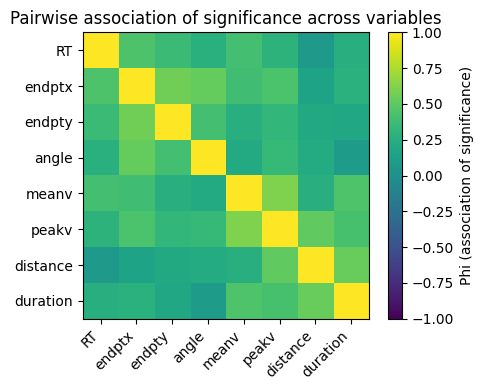

In [ ]:


def plot_pairwise_significance_association(sig_df):
    # keep only boolean columns
    bool_cols = [c for c in sig_df.columns if sig_df[c].dtype == bool]
    dfb = sig_df[bool_cols].astype(int)

    # phi = Pearson corr on 0/1
    corr = dfb.corr()

    plt.figure(figsize=(5, 4))
    im = plt.imshow(corr.values, vmin=-1, vmax=1, interpolation='nearest')
    plt.colorbar(im, label='Phi (association of significance)')
    plt.xticks(range(len(bool_cols)), bool_cols, rotation=45, ha='right')
    plt.yticks(range(len(bool_cols)), bool_cols)
    plt.title('Pairwise association of significance across variables')
    plt.tight_layout()
    plt.show()

# usage
plot_pairwise_significance_association(sig_df)


In [ ]:


def fisher_pairwise(sig_df):
    # keep only boolean columns
    bool_cols = [c for c in sig_df.columns if sig_df[c].dtype == bool]
    df = sig_df[bool_cols].copy()

    results = []

    for a, b in combinations(bool_cols, 2):
        A = df[a]
        B = df[b]

        # contingency table
        a_and_b = ((A == True) & (B == True)).sum()
        a_only  = ((A == True) & (B == False)).sum()
        b_only  = ((A == False) & (B == True)).sum()
        neither = ((A == False) & (B == False)).sum()

        table = np.array([[a_and_b, a_only],
                          [b_only,  neither]])

        oddsratio, p_value = fisher_exact(table, alternative='greater')

        results.append({
            'var_a': a,
            'var_b': b,
            'a&b': a_and_b,
            'a_only': a_only,
            'b_only': b_only,
            'neither': neither,
            'odds_ratio': oddsratio,
            'p_value': p_value,
        })

    return pd.DataFrame(results)

fisher_df = fisher_pairwise(sig_df)
fisher_df


,var_a,var_b,a&b,a_only,b_only,neither,odds_ratio,p_value
0,RT,endptx,27,10,18,48,7.200000,7.764718e-06
1,RT,endpty,25,12,20,46,4.791667,2.636417e-04
2,RT,angle,18,19,15,51,3.221053,6.838718e-03
3,RT,meanv,18,19,8,58,6.868421,6.907866e-05
4,RT,peakv,11,26,5,61,5.161538,4.076010e-03
5,RT,distance,8,29,10,56,1.544828,2.845192e-01
6,RT,duration,17,20,14,52,3.157143,8.643092e-03
7,endptx,endpty,34,11,11,47,13.206612,7.063026e-09
8,endptx,angle,27,18,6,52,13.000000,7.855537e-08
9,endptx,meanv,20,25,6,52,6.933333,8.719373e-05


In [ ]:
from statsmodels.stats.multitest import multipletests

# extract p-values
pvals = fisher_df['p_value'].to_numpy()

rej, qvals, _, _ = multipletests(pvals, method='fdr_bh')

fisher_df['q_value'] = qvals
fisher_df['sig_fdr'] = rej
sig_pairs = fisher_df[fisher_df['sig_fdr']]
sig_pairs


,var_a,var_b,a&b,a_only,b_only,neither,odds_ratio,p_value,q_value,sig_fdr
0,RT,endptx,27,10,18,48,7.200000,7.764718e-06,3.678201e-05,True
1,RT,endpty,25,12,20,46,4.791667,2.636417e-04,5.678438e-04,True
2,RT,angle,18,19,15,51,3.221053,6.838718e-03,1.063801e-02,True
3,RT,meanv,18,19,8,58,6.868421,6.907866e-05,1.793106e-04,True
4,RT,peakv,11,26,5,61,5.161538,4.076010e-03,7.133018e-03,True
6,RT,duration,17,20,14,52,3.157143,8.643092e-03,1.273719e-02,True
7,endptx,endpty,34,11,11,47,13.206612,7.063026e-09,1.799210e-07,True
8,endptx,angle,27,18,6,52,13.000000,7.855537e-08,7.331834e-07,True
9,endptx,meanv,20,25,6,52,6.933333,8.719373e-05,2.034520e-04,True
10,endptx,peakv,15,30,1,57,28.500000,9.195503e-06,3.678201e-05,True


In [ ]:
from itertools import combinations
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr
from statsmodels.stats.multitest import multipletests


def _partial_corr_from_pairwise(rxy, rxz, ryz):
    """Closed-form partial correlation of x,y controlling for z."""
    denom = np.sqrt(max(1 - rxz**2, 1e-12) * max(1 - ryz**2, 1e-12))
    return (rxy - rxz * ryz) / denom


def _partial_corr(x, y, z, method="spearman"):
    """
    Partial correlation between x and y, controlling for z.
    Returns (r_partial, p_value, n_used, t_stat).

    df = n - 3 (lose one extra df for the controlled variable).
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z = np.asarray(z, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
    x, y, z = x[mask], y[mask], z[mask]
    n = len(x)
    if n < 5 or np.std(x) == 0 or np.std(y) == 0 or np.std(z) == 0:
        return np.nan, np.nan, n, np.nan

    if method == "spearman":
        rxy, _ = spearmanr(x, y)
        rxz, _ = spearmanr(x, z)
        ryz, _ = spearmanr(y, z)
    else:
        rxy, _ = pearsonr(x, y)
        rxz, _ = pearsonr(x, z)
        ryz, _ = pearsonr(y, z)

    r_part = _partial_corr_from_pairwise(rxy, rxz, ryz)

    # t-statistic and two-sided p with df = n - 3
    df = n - 3
    if df <= 0 or abs(r_part) >= 0.999999:
        return r_part, np.nan, n, np.nan
    t = r_part * np.sqrt(df / max(1 - r_part**2, 1e-12))
    from scipy.stats import t as tdist
    p = 2 * tdist.sf(abs(t), df)
    return float(r_part), float(p), int(n), float(t)


def analyze_unit_partial_correlations(
    df: pd.DataFrame,
    x_col: str,
    y_col: str,
    control_col: str,
    method: str = "spearman",
    min_trials: int = 50,
    alpha: float = 0.05,
) -> pd.DataFrame:
    """
    Per-unit partial correlation between x_col and y_col, controlling for control_col.

    Mirrors the structure of analyze_unit_correlations so existing plotting
    functions work with metric='spearman_t' or 'pearson_t'.
    """
    rows = []
    for (uid, sess), g in df.groupby(["unit_id", "session"]):
        x = g[x_col].to_numpy()
        y = g[y_col].to_numpy()
        z = g[control_col].to_numpy()
        n = len(g)

        if n < min_trials:
            r_part, p, n_used, t = np.nan, np.nan, n, np.nan
        else:
            r_part, p, n_used, t = _partial_corr(x, y, z, method=method)

        rec = {
            "unit_id": uid,
            "session": sess,
            "n_trials": n_used,
            "control": control_col,
        }
        if method == "spearman":
            rec["spearman_rho"] = r_part
            rec["spearman_p"]   = p
            rec["spearman_t"]   = t
        else:
            rec["pearson_r"] = r_part
            rec["pearson_p"] = p
            rec["pearson_t"] = t
        rows.append(rec)

    out = pd.DataFrame(rows).sort_values(["session", "unit_id"]).reset_index(drop=True)

    # FDR
    p_col = "spearman_p" if method == "spearman" else "pearson_p"
    q_col = "spearman_q" if method == "spearman" else "pearson_q"
    sig_col = "spearman_sig_fdr" if method == "spearman" else "pearson_sig_fdr"

    m = out[p_col].notna()
    if m.any():
        _, q, _, _ = multipletests(out.loc[m, p_col].values, alpha=alpha, method="fdr_bh")
        out.loc[m, q_col] = q
        out[sig_col] = out[q_col] < alpha
    else:
        out[q_col] = np.nan
        out[sig_col] = False

    return out

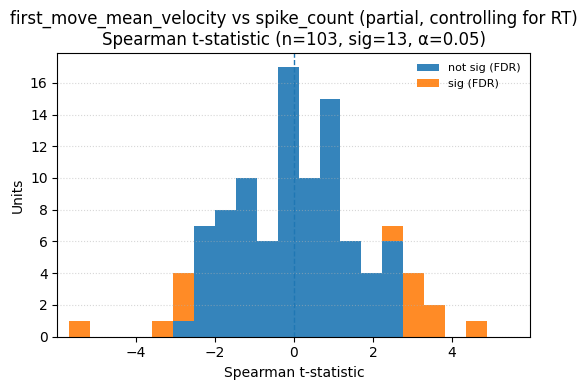

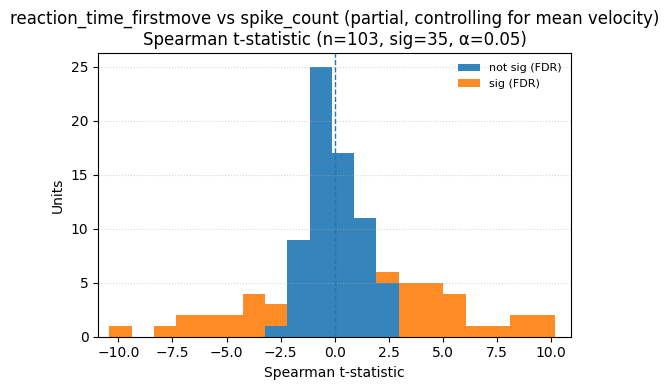

In [ ]:
df_filtered = all_counts_df.query("reaction_time_firstmove < 1").copy()

# (1) spike count vs peak velocity, controlling for RT
pc_vel_pRT = analyze_unit_partial_correlations(
    df_filtered,
    x_col="spike_count",
    y_col="first_move_mean_velocity",
    control_col="reaction_time_firstmove",
    method="spearman",
    min_trials=50,
)

fig = plot_summary_distribution(
    pc_vel_pRT,
    metric="spearman_t",
    x_label="spike_count (partial, controlling for RT)",
    y_label="first_move_mean_velocity",
)

# (2) spike count vs RT, controlling for peak velocity
pc_RT_pVel = analyze_unit_partial_correlations(
    df_filtered,
    x_col="spike_count",
    y_col="reaction_time_firstmove",
    control_col="first_move_mean_velocity",
    method="spearman",
    min_trials=50,
)

fig = plot_summary_distribution(
    pc_RT_pVel,
    metric="spearman_t",
    x_label="spike_count (partial, controlling for mean velocity)",
    y_label="reaction_time_firstmove",
)

No example units to plot.
[Spearman ρ] Wilcoxon vs 0: W=1999.0, p=0.0255, median=-0.035, n_units=103
[Spearman ρ] Sign test: negatives=65, positives=38, p=0.0101, n_units=103
[Pearson r] Fisher-z meta: r_meta=-0.035 (95% CI -0.046..-0.023), z=-6.05, p=1.43e-09, n_units=103
[Per-unit FDR @ α=0.05] sig units: total=31, pos=9, neg=22


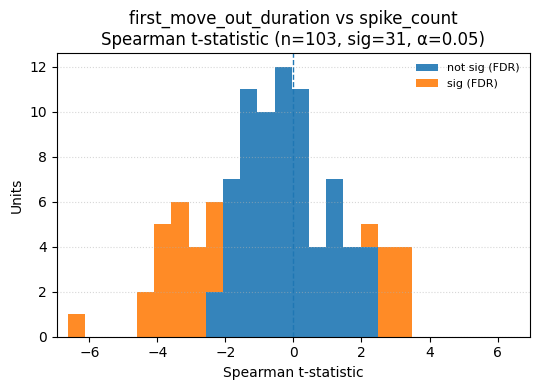

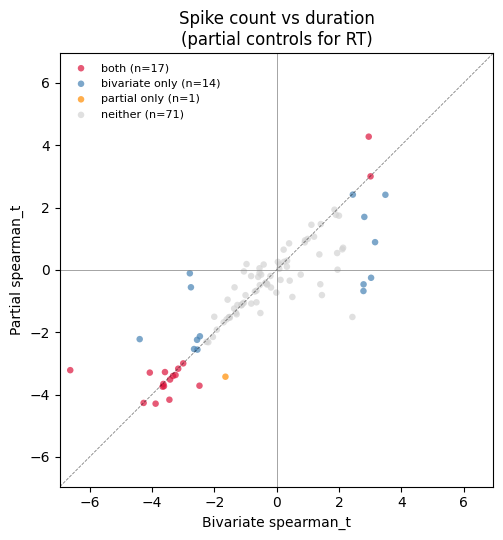

In [ ]:
def plot_bivariate_vs_partial(
    bivariate_df: pd.DataFrame,
    partial_df: pd.DataFrame,
    metric: str = "spearman_t",
    alpha: float = 0.05,
    title: str = "",
):
    """
    Scatter per-unit bivariate vs partial effect sizes.
    Color by significance class:
      - sig in both
      - sig bivariate only (effect explained by control)
      - sig partial only (effect masked by control)
      - sig in neither
    """
    biv = bivariate_df[["session", "unit_id", metric]].rename(columns={metric: "biv"})
    par = partial_df[["session", "unit_id", metric]].rename(columns={metric: "par"})

    # significance flag column inferred from metric prefix
    sig_col = "spearman_sig_fdr" if "spearman" in metric else "pearson_sig_fdr"
    biv["biv_sig"] = bivariate_df[sig_col].values
    par["par_sig"] = partial_df[sig_col].values

    merged = biv.merge(par, on=["session", "unit_id"]).dropna(subset=["biv", "par"])

    cls = np.where(
        merged["biv_sig"] & merged["par_sig"], "both",
        np.where(merged["biv_sig"] & ~merged["par_sig"], "bivariate only",
        np.where(~merged["biv_sig"] & merged["par_sig"], "partial only", "neither"))
    )
    merged["class"] = cls

    colors = {
        "both":           "crimson",
        "bivariate only": "steelblue",
        "partial only":   "darkorange",
        "neither":        "lightgray",
    }

    fig, ax = plt.subplots(figsize=(5.5, 5.5))

    for label, color in colors.items():
        sub = merged[merged["class"] == label]
        ax.scatter(sub["biv"], sub["par"], s=22, alpha=0.7,
                   color=color, edgecolor="none",
                   label=f"{label} (n={len(sub)})")

    # unity & axes
    lim = np.nanmax(np.abs(merged[["biv", "par"]].to_numpy())) * 1.05
    ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.6, alpha=0.5)
    ax.axhline(0, color="gray", lw=0.5)
    ax.axvline(0, color="gray", lw=0.5)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")

    ax.set_xlabel(f"Bivariate {metric}")
    ax.set_ylabel(f"Partial {metric}")
    ax.set_title(title)
    ax.legend(frameon=False, fontsize=8, loc="upper left")
    fig.tight_layout()
    return fig, merged


# bivariate: spike_count vs peak_velocity
res_vel = run_and_plot_for_predictor(
    all_counts_df,
    x_col="spike_count",
    y_col="first_move_out_duration",
    example_n=0,
    filter_query="reaction_time_firstmove < 1",
    summary_metric="spearman_t",
)
biv_vel = res_vel["cor_df"]

# partial: same, controlling for RT
df_filt = all_counts_df.query("reaction_time_firstmove < 1").copy()
par_vel_pRT = analyze_unit_partial_correlations(
    df_filt,
    x_col="spike_count",
    y_col="first_move_out_duration",
    control_col="reaction_time_firstmove",
)

fig, merged = plot_bivariate_vs_partial(
    biv_vel, par_vel_pRT,
    metric="spearman_t",
    title="Spike count vs duration\n(partial controls for RT)",
)

No example units to plot.
[Spearman ρ] Wilcoxon vs 0: W=2394.0, p=0.35, median=0.004, n_units=103
[Spearman ρ] Sign test: negatives=51, positives=52, p=1, n_units=103
[Pearson r] Fisher-z meta: r_meta=-0.011 (95% CI -0.022..-0.000), z=-2.00, p=0.045, n_units=103
[Per-unit FDR @ α=0.05] sig units: total=37, pos=22, neg=15


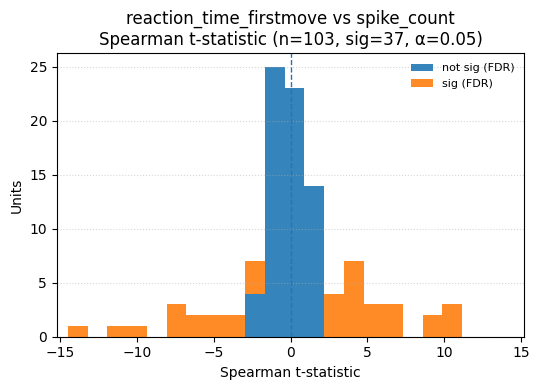

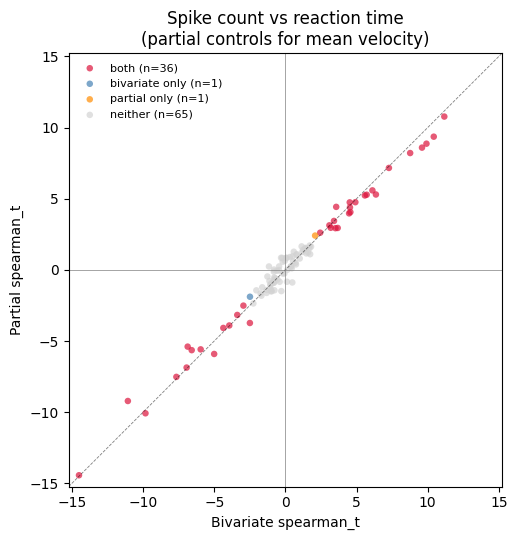

In [ ]:
# bivariate: spike_count vs rt
res_vel = run_and_plot_for_predictor(
    all_counts_df,
    x_col="spike_count",
    y_col="reaction_time_firstmove",
    example_n=0,
    filter_query="reaction_time_firstmove < 1",
    summary_metric="spearman_t",
)
biv_vel = res_vel["cor_df"]

# partial: same, controlling for RT
df_filt = all_counts_df.query("reaction_time_firstmove < 1").copy()
par_vel_pRT = analyze_unit_partial_correlations(
    df_filt,
    x_col="spike_count",
    y_col="reaction_time_firstmove",
    control_col="first_move_out_duration",
)

fig, merged = plot_bivariate_vs_partial(
    biv_vel, par_vel_pRT,
    metric="spearman_t",
    title="Spike count vs reaction time\n(partial controls for mean velocity)",
)

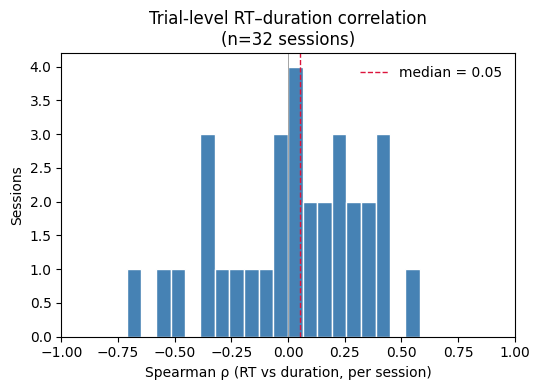

count    32.000000
mean      0.027236
std       0.317109
min      -0.710782
25%      -0.193549
50%       0.051743
75%       0.246988
max       0.580998
Name: rho, dtype: float64


In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# one ρ per session: trial-level Spearman between RT and peak velocity
df_filt = all_counts_df.query("reaction_time_firstmove < 1").copy()

# per-session unique trials (drop unit duplication)
session_trials = (df_filt
                  .drop_duplicates(["session", "trial"])
                  [["session", "reaction_time_firstmove", "first_move_out_duration"]])

session_rho = []
for sess, g in session_trials.groupby("session"):
    g = g.dropna(subset=["reaction_time_firstmove", "first_move_out_duration"])
    if len(g) < 10:
        continue
    rho, _ = spearmanr(g["reaction_time_firstmove"], g["first_move_out_duration"])
    session_rho.append({"session": sess, "rho": rho, "n_trials": len(g)})

rho_df = pd.DataFrame(session_rho)

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.hist(rho_df["rho"], bins=20, color="steelblue", edgecolor="white")
ax.axvline(0, color="gray", lw=0.5)
ax.axvline(rho_df["rho"].median(), color="crimson", ls="--", lw=1,
           label=f"median = {rho_df['rho'].median():.2f}")
ax.set_xlabel("Spearman ρ (RT vs duration, per session)")
ax.set_ylabel("Sessions")
ax.set_title(f"Trial-level RT–duration correlation\n(n={len(rho_df)} sessions)")
ax.legend(frameon=False)
ax.set_xlim(-1, 1)
plt.tight_layout()
plt.show()

print(rho_df["rho"].describe())

## Spatial analysis (CCF)

Project per-unit encoding statistics onto CCF brain coordinates to test for anatomical structure.

In [106]:
# spatial plots

import numpy as np
from trimesh import load_mesh
from ccf_utils import pir_to_lps, project_to_plane

# ---- constants / axes ----
ml, ap, dv = 0, 1, 2

BREGMA_LPS_MM = np.array([-5.7,  5.4, -0.45], dtype=float)  # bregma in LPS mm
BREGMA_PIR_VOX = np.array([216, 18, 228], dtype=float)      # bregma in PIR vox
CCF_RES_UM = 25.0                                           # um per voxel

PLANES = {
    "sag": [ap, dv],
    "hor": [ml, ap],
    "cor": [ml, dv],
}

def ccf_points_lps_mm(features_df, *, fold_left=True):
    """Return Nx3 LPS mm coords, bregma-centered; optionally left-fold ML."""
    ccfs = features_df[["x_ccf", "y_ccf", "z_ccf"]].to_numpy(dtype=float)
    ccfs = ccfs - BREGMA_LPS_MM
    if fold_left:
        ccfs[:, ml] = -np.abs(ccfs[:, ml])
    return ccfs

# ---- load mesh once + precompute contours ----
MESH_PATH = "/root/capsule/data/LC-NE_scratch_data_1/combined/ccf_maps/20250418_transformed_remesh_10_ccf25.obj"

mesh = load_mesh(MESH_PATH)
mesh_vertices_pir_vox = np.array(mesh.vertices, dtype=float)

# PIR vox -> PIR mm (bregma-centered)
mesh_vertices_pir_mm = (mesh_vertices_pir_vox - BREGMA_PIR_VOX) * (CCF_RES_UM / 1000.0)

# PIR -> LPS (still bregma-centered)
mesh_vertices_lps_mm = pir_to_lps(mesh_vertices_pir_mm)

# contours per plane (unfolded; we'll flip ML at plot time to match left-folded points)
mesh_contours = {
    name: project_to_plane(mesh_vertices_lps_mm, axes, pitch=0.02, margin=0.5)
    for name, axes in PLANES.items()
}

In [107]:
#data org for spatial plots

def _get_cor_df(cor_source):
    """Accept dict like spkct_rt (with key 'cor_df') or a raw DataFrame."""
    if isinstance(cor_source, dict):
        if "cor_df" not in cor_source:
            raise KeyError("cor_source dict must contain key 'cor_df'")
        return cor_source["cor_df"]
    return cor_source

def add_correlations(
    features_df,
    cor_source,
    *,
    prefix,
    session_col="session",
    unit_col_features="unit",
    unit_col_cor="unit_id",
    keep_cols=None,
    # if keep_cols=None, we take all non-key columns from cor_df
    validate="one_to_one",
    overwrite=False,
):
    """
    Idempotently add ONE correlation table into features_df using namespaced columns.

    - prefix: e.g. "rt" or "rt_bl" (becomes "<prefix>__<colname>")
    - overwrite=False: if columns already exist, keep existing and do nothing
    """
    feats = features_df.copy()
    cor_df = _get_cor_df(cor_source).copy()

    # normalize key colnames
    if unit_col_cor != unit_col_features:
        cor_df = cor_df.rename(columns={unit_col_cor: unit_col_features})

    keys = [session_col, unit_col_features]

    if keep_cols is None:
        keep_cols = [c for c in cor_df.columns if c not in keys]

    # build namespaced correlation frame: only keys + selected cols, renamed with prefix
    rename_map = {c: f"{prefix}__{c}" for c in keep_cols}
    cor_small = cor_df[keys + keep_cols].rename(columns=rename_map)

    # idempotency check
    target_cols = list(rename_map.values())
    already_present = all(c in feats.columns for c in target_cols)
    if already_present and not overwrite:
        print('columns already present in feats')
        return feats  # no-op

    # if some columns exist and overwrite=False, avoid duplicating by merging only missing cols
    if not overwrite:
        missing = [c for c in target_cols if c not in feats.columns]
        if len(missing) == 0:
            return feats
        # map back to original cols to subset cor_small
        cor_small = cor_small[keys + missing]

    # merge
    feats = feats.merge(cor_small, on=keys, how="left", validate=validate)

    # (optional) add abs convenience columns if spearman_t exists under this prefix
    tcol = f"{prefix}__spearman_t"
    if tcol in feats.columns:
        abscol = f"{prefix}__spearman_t_abs"
        if abscol not in feats.columns or overwrite:
            feats[abscol] = feats[tcol].abs()

    return feats

def list_corr_prefixes(features_df, *, separator="__"):
    """Quick helper: see what prefixes exist in your wide table."""
    prefixes = set()
    for c in features_df.columns:
        if separator in c:
            prefixes.add(c.split(separator, 1)[0])
    return sorted(prefixes)


# base table: ephys coords + unit metadata
features_combined = filtered_ephys.copy()

# add two correlation sources into the same table
features_combined = add_correlations(features_combined, spkct_rt,    prefix="rt")
features_combined = add_correlations(features_combined, spkct_rt_bl, prefix="rt_bl")


In [109]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable

def plot_ccf_7panel(
    features_combined,
    value_col,
    *,
    sig_col=None,                # e.g. "rt__spearman_sig_fdr" (optional)
    use_sig=False,               # if True and sig_col provided -> grey out nonsig
    fold_left=True,
    # expects these globals from your "CCF prep" cell:
    #   BREGMA_LPS_MM, PLANES, mesh_contours, ml, ap, dv
    point_size=15,
    point_alpha=0.7,
    dv_ylim_2d=(-5, -3),
    dv_xlim_1d=(-5, -3),
    n_bins=8,
    title=None,
):
    """
    Minimal 7-panel plot:
      col0: histogram
      col1-3: sag/hor/cor 2D maps with mesh background
      col4-6: DV/ML/AP 1D scatter + binned mean

    Inputs:
      features_combined: dataframe with x_ccf,y_ccf,z_ccf and value_col
      value_col: column to color points by
      sig_col/use_sig: optional significance masking
    """
    # ---- 1) pull values + base mask ----
    vals = features_combined[value_col].to_numpy(dtype=float)
    base_mask = np.isfinite(vals)

    if not np.any(base_mask):
        raise ValueError(f"No finite values found in column '{value_col}'")

    # ---- 2) build LPS mm coords, bregma-centered, optionally left-folded ----
    ccfs = features_combined[["x_ccf", "y_ccf", "z_ccf"]].to_numpy(dtype=float)
    ccfs = ccfs - BREGMA_LPS_MM
    if fold_left:
        ccfs[:, ml] = -np.abs(ccfs[:, ml])

    # ---- 3) significance mask (optional) ----
    if use_sig and (sig_col is not None) and (sig_col in features_combined.columns):
        sig_mask = features_combined[sig_col].to_numpy(dtype=bool) & base_mask
        nonsig_mask = (~sig_mask) & base_mask
    else:
        sig_mask = base_mask
        nonsig_mask = np.zeros_like(base_mask, dtype=bool)

    # ---- 4) choose norm/cmap similar to your pipeline ----
    vals_for_scale = vals[sig_mask] if np.any(sig_mask) else vals[base_mask]
    vals_for_scale = vals_for_scale[np.isfinite(vals_for_scale)]

    has_neg = np.any(vals_for_scale < 0)
    has_pos = np.any(vals_for_scale > 0)

    if has_neg and has_pos:
        amp = np.nanquantile(np.abs(vals_for_scale), 0.92)
        if not (np.isfinite(amp) and amp > 0):
            amp = np.nanmax(np.abs(vals_for_scale))
        if not (np.isfinite(amp) and amp > 0):
            amp = 1.0
        norm = Normalize(vmin=-amp, vmax=amp)
        cmap = plt.get_cmap("coolwarm")
        center_line, lower_limit, upper_limit = 0.0, -amp, amp
    else:
        amp = np.nanquantile(np.abs(vals_for_scale), 0.975)
        if not (np.isfinite(amp) and amp > 0):
            amp = np.nanmax(np.abs(vals_for_scale))
        if not (np.isfinite(amp) and amp > 0):
            amp = 1.0
        norm = Normalize(vmin=0.0, vmax=amp)
        cmap = plt.get_cmap("viridis_r")
        center_line = float(np.nanmean(vals_for_scale))
        lower_limit = float(np.nanmin(vals_for_scale))
        upper_limit = float(np.nanmax(vals_for_scale))

    # ---- 5) figure layout ----
    fig, axes = plt.subplots(1, 7, figsize=(18, 3))
    ax_hist = axes[0]

    # ---- panel 0: histogram ----
    ax_hist.hist(vals[base_mask], bins=30, color="gray", alpha=0.7)
    ax_hist.set_title(title or value_col)
    ax_hist.axvline(center_line, color="k", linestyle="--", linewidth=1, label="mean")
    ax_hist.axvline(upper_limit, color="red", linestyle="--", linewidth=1, label="max")
    ax_hist.axvline(lower_limit, color="blue", linestyle="--", linewidth=1, label="min")
    ax_hist.legend(frameon=False, fontsize=8)

    # precompute colors for sig points
    sig_vals = vals[sig_mask]
    rgba_sig = cmap(norm(sig_vals))
    rgba_sig[:, -1] = point_alpha

    ccfs_sig = ccfs[sig_mask]
    ccfs_non = ccfs[nonsig_mask]

    axis_labels_2d = {ml: "ML (mm, folded)" if fold_left else "ML (mm)", ap: "AP (mm)", dv: "DV (mm)"}

    # ---- panels 1-3: sag/hor/cor ----
    for (plane_name, plane_axes), ax in zip(PLANES.items(), axes[1:4]):
        # mesh background (flip ML to match left-folded coords)
        for c in mesh_contours[plane_name]:
            c_plot = c.copy()
            if fold_left:
                if plane_axes[0] == ml:
                    c_plot[:, 0] *= -1
                if plane_axes[1] == ml:
                    c_plot[:, 1] *= -1
            ax.fill(c_plot[:, 0], c_plot[:, 1], color="lightgray", alpha=0.3, linewidth=0)

        # nonsig grey
        if np.any(nonsig_mask):
            ax.scatter(
                ccfs_non[:, plane_axes[0]],
                ccfs_non[:, plane_axes[1]],
                color="lightgrey",
                s=point_size,
                alpha=0.5,
                edgecolors="none",
            )

        # sig colored
        ax.scatter(
            ccfs_sig[:, plane_axes[0]],
            ccfs_sig[:, plane_axes[1]],
            facecolors=rgba_sig,
            edgecolors="none",
            s=point_size,
        )

        ax.set_xlabel(axis_labels_2d[plane_axes[0]])
        ax.set_ylabel(axis_labels_2d[plane_axes[1]])
        ax.set_aspect("equal")
        if dv_ylim_2d is not None and plane_axes[1] == dv:
            ax.set_ylim(list(dv_ylim_2d))

    # ---- panels 4-6: DV/ML/AP 1D scatter + binned mean ----
    axis_order = [dv, ml, ap]
    axis_labels_1d = {dv: "DV (mm)", ml: axis_labels_2d[ml], ap: "AP (mm)"}

    for j, axis_idx in enumerate(axis_order):
        ax1d = axes[4 + j]
        x = ccfs[:, axis_idx]
        y = vals

        mask_xy = np.isfinite(x) & np.isfinite(y)
        x = x[mask_xy]
        y = y[mask_xy]

        colors_xy = cmap(norm(y))
        colors_xy[:, -1] = point_alpha
        ax1d.scatter(x, y, s=20, facecolors=colors_xy, edgecolors="none")

        # binned mean
        if x.size > 0 and n_bins > 0:
            edges = np.linspace(x.min(), x.max(), n_bins + 1)
            centers = 0.5 * (edges[:-1] + edges[1:])
            means = np.full(n_bins, np.nan)
            for i in range(n_bins):
                in_bin = (x >= edges[i]) & (x < edges[i + 1])
                if np.any(in_bin):
                    means[i] = np.nanmean(y[in_bin])
            ax1d.plot(centers, means, color="k", linewidth=2, marker="o", markersize=4, label="binned mean")

        ax1d.set_xlabel(axis_labels_1d[axis_idx])
        ax1d.set_ylabel(value_col if j == 0 else "")
        ax1d.set_title(f"{value_col} vs {['DV','ML','AP'][j]}")
        if dv_xlim_1d is not None and axis_idx == dv:
            ax1d.set_xlim(list(dv_xlim_1d))
        ax1d.legend(frameon=False, fontsize=7)

    # ---- colorbar to the right of panel 3 (coronal) ----
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    divider = make_axes_locatable(axes[3])
    cax = divider.append_axes("right", size="5%", pad="3%")
    fig.colorbar(sm, cax=cax, label=value_col)

    plt.tight_layout()
    return fig, axes



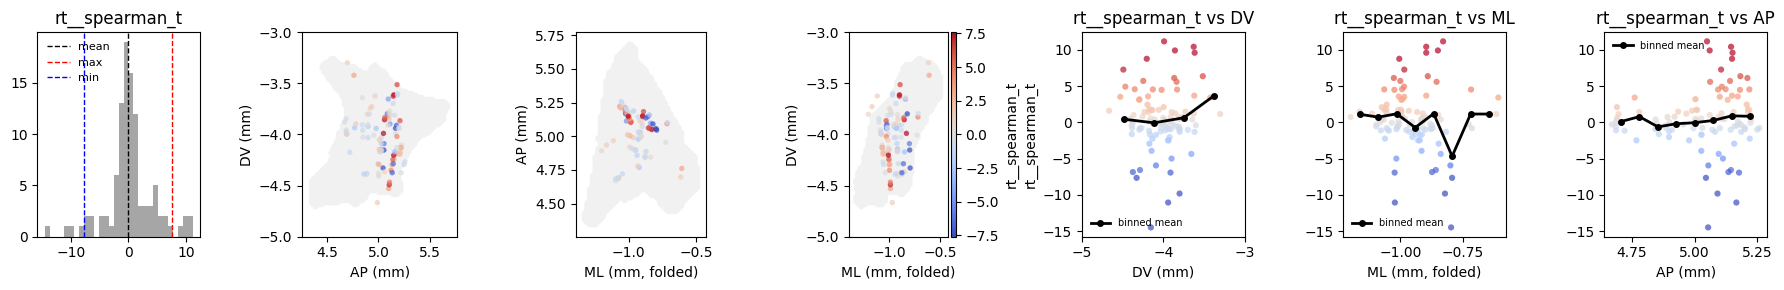

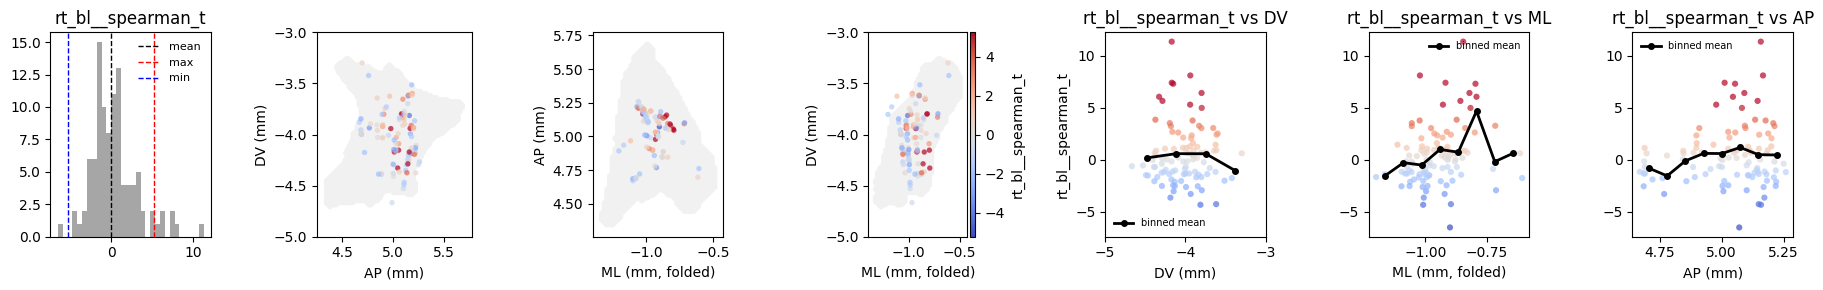

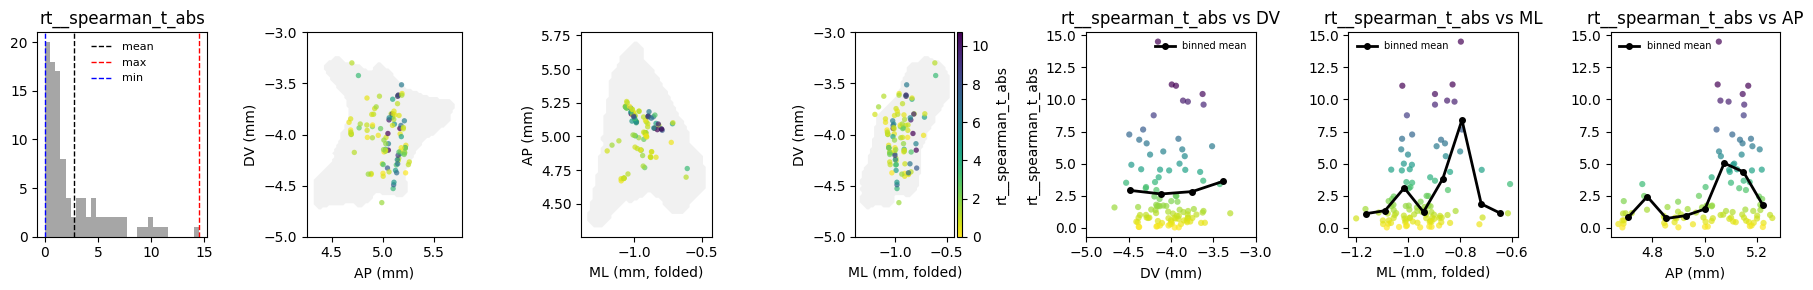

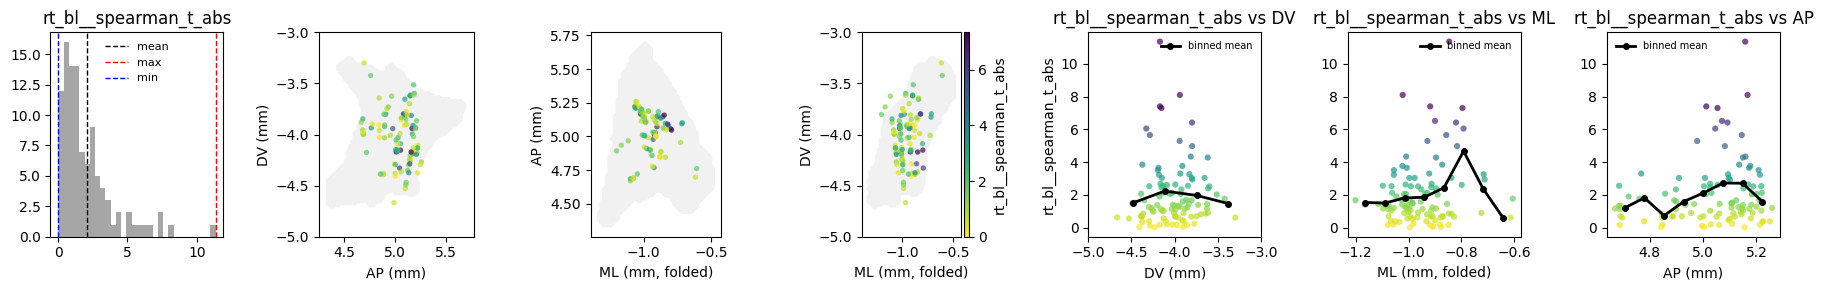

In [110]:
# plot rt spearman_t
plot_ccf_7panel(features_combined, "rt__spearman_t")

# plot rt_bl spearman_t
plot_ccf_7panel(features_combined, "rt_bl__spearman_t")

# plot rt spearman_t_abs
plot_ccf_7panel(features_combined, "rt__spearman_t_abs")

# plot rt_bl spearman_t
plot_ccf_7panel(features_combined, "rt_bl__spearman_t_abs")

plt.show()


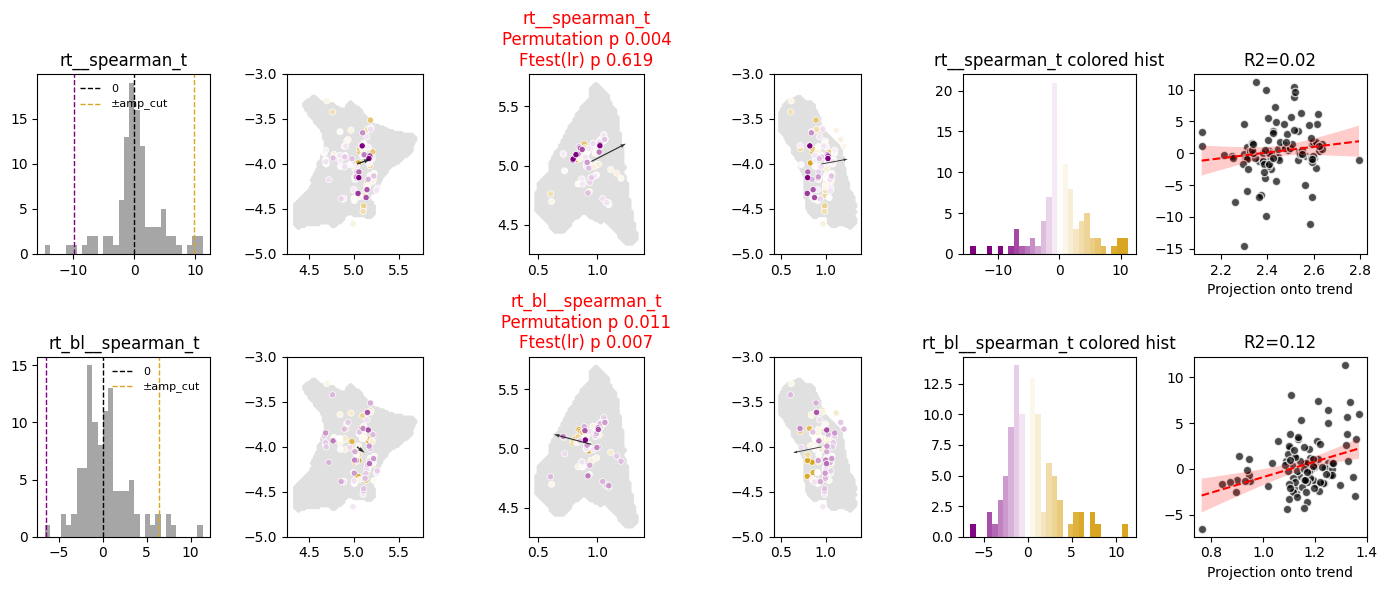

In [ ]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import Normalize, LinearSegmentedColormap
from sklearn.linear_model import LinearRegression
from scipy import stats
from statsmodels.stats.multitest import multipletests
from trimesh import load_mesh

MESH_PATH = "/root/capsule/data/LC-NE_scratch_data_1/combined/ccf_maps/20250418_transformed_remesh_10_ccf25.obj"

def a(
    coords,
    values,
    *,
    k_neighbors=15,
    n_splits=5,
    permutations=5000,
    seed=0,
    return_null=False,
):
    """
    Combines:
      (1) Linear trend test: value ~ x + y + z (PERMUTATION test; permute values, keep coords fixed)
      (2) 5-fold CV predictability with kNN (distance-weighted) + permutation p-value

    Returns a dictionary of results.
    """
    import numpy as np
    import statsmodels.api as sm
    from sklearn.model_selection import KFold
    from sklearn.neighbors import KNeighborsRegressor
    from sklearn.metrics import r2_score

    rng = np.random.default_rng(seed)

    X = np.asarray(coords, float)
    y = np.asarray(values, float)

    # drop NaNs / infs; reshape X to N x D
    X = X.reshape(X.shape[0], -1)
    ok = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    X = X[ok]
    y = y[ok]
    n = y.size
    if n < 10:
        raise ValueError(f"Too few valid points after filtering (n={n}).")

    # -------------------------
    # (1) Linear regression trend (PERMUTATION p-value)
    # -------------------------
    X_const = sm.add_constant(X)  # [1, x, y, z] (or [1, ...D dims])

    model_full = sm.OLS(y, X_const).fit()
    r2_obs = float(model_full.rsquared)

    # Deterministic per-permutation seeds (same pattern you used below)
    perm_seeds = np.random.SeedSequence(seed + 12345).spawn(permutations)
    perm_seeds_uint = np.array(
        [s.generate_state(1, dtype=np.uint32)[0] for s in perm_seeds],
        dtype=np.uint32
    )

    def _one_perm_r2_linear(s_uint):
        r = np.random.default_rng(int(s_uint))
        y_perm = r.permutation(y)
        return sm.OLS(y_perm, X_const).fit().rsquared

    # compute permutation null (parallel if possible)
    try:
        from joblib import Parallel, delayed
        r2_perm = np.asarray(
            Parallel(n_jobs=-1, prefer="processes")(
                delayed(_one_perm_r2_linear)(s_uint) for s_uint in perm_seeds_uint
            ),
            dtype=float,
        )
    except Exception:
        r2_perm = np.empty(permutations, float)
        for i, s_uint in enumerate(perm_seeds_uint):
            r2_perm[i] = _one_perm_r2_linear(s_uint)

    # one-sided permutation p-value (greater-than)
    p_trend_perm = (np.sum(r2_perm >= r2_obs) + 1) / (permutations + 1)

    # (Optional) also report the classic F-stat if you still want it (no p-value)
    # This is just for interpretability; p-value comes from permutations.
    # F = ( (SSE_null - SSE_full)/df1 ) / ( SSE_full/df2 )
    y_mean = y.mean()
    sse_null = np.sum((y - y_mean) ** 2)
    sse_full = np.sum(model_full.resid ** 2)
    df1 = X_const.shape[1] - 1
    df2 = n - X_const.shape[1]
    f_stat = ((sse_null - sse_full) / df1) / (sse_full / df2) if df2 > 0 else np.nan

    # -------------------------
    # (2) CV predictability (kNN) + permutation test (parallel)
    # -------------------------
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    def cv_r2(y_target):
        preds = np.zeros_like(y_target)
        for tr, te in kf.split(X):
            model = KNeighborsRegressor(
                n_neighbors=min(k_neighbors, len(tr)),
                weights="distance",
            )
            model.fit(X[tr], y_target[tr])
            preds[te] = model.predict(X[te])
        return r2_score(y_target, preds)

    r2_cv_obs = cv_r2(y)

    perm_seeds = np.random.SeedSequence(seed).spawn(permutations)
    perm_seeds_uint = np.array([s.generate_state(1, dtype=np.uint32)[0] for s in perm_seeds], dtype=np.uint32)

    def _one_perm_r2_knn(s_uint):
        r = np.random.default_rng(int(s_uint))
        return cv_r2(r.permutation(y))

    try:
        from joblib import Parallel, delayed
        r2_cv_perm = np.asarray(
            Parallel(n_jobs=-1, prefer="processes")(
                delayed(_one_perm_r2_knn)(s_uint) for s_uint in perm_seeds_uint
            ),
            dtype=float,
        )
    except Exception:
        r2_cv_perm = np.empty(permutations, float)
        for i, s_uint in enumerate(perm_seeds_uint):
            r2_cv_perm[i] = _one_perm_r2_knn(s_uint)

    p_cv = (np.sum(r2_cv_perm >= r2_cv_obs) + 1) / (permutations + 1)

    out = {
        "n_used": int(n),
        "inputs": {
            "k_neighbors": int(k_neighbors),
            "n_splits": int(n_splits),
            "permutations": int(permutations),
            "seed": int(seed),
        },
        "linear_trend": {
            "coef_const_x_y_z": model_full.params.tolist(),  # [const, b1..bD]
            "r2": float(r2_obs),
            "F_stat": float(f_stat),
            "p_value_permutation_r2": float(p_trend_perm),
            "null_mean_r2": float(np.mean(r2_perm)),
            "null_std_r2": float(np.std(r2_perm, ddof=1)),
        },
        "cv_predictability_knn": {
            "r2_cv": float(r2_cv_obs),
            "p_value_permutation": float(p_cv),
            "null_mean": float(np.mean(r2_cv_perm)),
            "null_std": float(np.std(r2_cv_perm, ddof=1)),
        },
    }

    if return_null:
        out["linear_trend"]["r2_null_distribution"] = r2_perm.tolist()
        out["cv_predictability_knn"]["r2_null_distribution"] = r2_cv_perm.tolist()

    return out

# ----------------------------
# 0) Geometry + CCF coords (same as your cell)
# ----------------------------
ml, ap, dv = 0, 1, 2
planes = {'sag': [ap, dv], 'hor': [ml, ap], 'cor': [ml, dv]}

norm = Normalize(vmin=0, vmax=1)

mesh = load_mesh(MESH_PATH)
mesh_vertices = np.array(mesh.vertices, dtype=float)
mesh_vertices = (mesh_vertices - np.array([216, 18, 228], dtype=float)) * 25 / 1000.0
mesh_vertices_lps = pir_to_lps(mesh_vertices)
mesh_vertices_mm = mesh_vertices_lps

# --- 3D anatomical points ---
ccfs = features_combined[['x_ccf', 'y_ccf', 'z_ccf']].values.astype(float)
bregma_LPS_mm = np.array([-5.7, 5.4, -0.45], dtype=float)
ccfs = ccfs - bregma_LPS_mm
ccfs[:, ml] = np.abs(ccfs[:, ml])  # mirror ML to left hemisphere

mesh_contours = {
    plane_name: project_to_plane(mesh_vertices_mm, plane_axes, pitch=0.02, margin=0.5)
    for plane_name, plane_axes in planes.items()
}

# ----------------------------
# 1) Feature map for RT T-stats (color -> white -> color)
# ----------------------------
rt_colors = LinearSegmentedColormap.from_list(
    'rt_t',
    [(0.0, 'purple'), (0.5, 'white'), (1.0, 'goldenrod')]
)
rt_bl_colors = LinearSegmentedColormap.from_list(
    'rt_bl_t',
    [(0.0, 'purple'), (0.5, 'white'), (1.0, 'goldenrod')]
)

feature_map = {
    'rt__spearman_t': rt_colors,
    'rt_bl__spearman_t': rt_bl_colors,
}

# ----------------------------
# 2) Spatial dependence analysis for these RT features (so arrows + pvals exist)
# ----------------------------
# mask = (features_combined['selected'].values > 0)  # same as your plotting mask
mask = np.ones(len(features_combined), dtype=bool)
spatial_dependence_results = {}

for feature_name in feature_map.keys():
    values = features_combined[feature_name].values.astype(float)
    result = spatial_dependence_summary(
        ccfs[mask, :],
        values[mask],
        k_neighbors=30,
        n_splits=5,
        permutations=2000,
        seed=42,
    )
    spatial_dependence_results[feature_name] = result

# FDR for knn
p_values = [spatial_dependence_results[f]['cv_predictability_knn']['p_value_permutation'] for f in feature_map.keys()]
reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')
for i, f in enumerate(feature_map.keys()):
    spatial_dependence_results[f]['cv_predictability_knn']['p_value_permutation_fdr'] = pvals_corrected[i]
    spatial_dependence_results[f]['cv_predictability_knn']['significant_fdr'] = reject[i]

# FDR for trend
p_values = [spatial_dependence_results[f]['linear_trend']['p_value_permutation_r2'] for f in feature_map.keys()]
reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')
for i, f in enumerate(feature_map.keys()):
    spatial_dependence_results[f]['linear_trend']['p_value_permutation_r2_fdr'] = pvals_corrected[i]
    spatial_dependence_results[f]['linear_trend']['significant_fdr'] = reject[i]

# optional save
if 'target_folder' in globals() and 'criteria_name' in globals():
    output_file = os.path.join(target_folder, f'spatial_dependence_results_RT_{criteria_name}.pkl')
    with open(output_file, 'wb') as f:
        pickle.dump(spatial_dependence_results, f)

# ----------------------------
# 3) Plot (exact style), with ONE fix: do NOT loop planes over axes[ind, 1:]
# ----------------------------
# mask = features_combined['be_filter'].values.astype(bool) if 'be_filter' in features_combined.columns else mask
# mask = (features_combined['selected'].values > 0)
mask = np.ones(len(features_combined), dtype=bool)

fig, axes = plt.subplots(len(feature_map), 6, figsize=(14, 3 * len(feature_map)))
axes = np.atleast_2d(axes)

for ind, (feature, colormap) in enumerate(feature_map.items()):
    color = features_combined[feature].values.astype(float)

    # === Normalize colors to 0–1 ===
    amp_cut = np.nanquantile(np.abs(color), 0.95)
    if not np.isfinite(amp_cut) or amp_cut <= 0:
        amp_cut = np.nanmax(np.abs(color))
    if not np.isfinite(amp_cut) or amp_cut <= 0:
        amp_cut = 1.0

    color_reg = 0.5 + 0.5 * color / amp_cut
    color_reg = np.clip(color_reg, 0, 1)

    center_line = 0.0
    upper_limit = amp_cut
    lower_limit = -amp_cut

    # === Histogram of feature values ===
    ax_hist = axes[ind, 0]
    ax_hist.hist(color[np.isfinite(color)], bins=30, color='gray', alpha=0.7)
    ax_hist.set_title(feature)
    ax_hist.axvline(center_line, color='k', linestyle='--', linewidth=1, label='0')
    ax_hist.axvline(upper_limit, color=colormap(1.0), linestyle='--', linewidth=1, label='±amp_cut')
    ax_hist.axvline(lower_limit, color=colormap(0.0), linestyle='--', linewidth=1)
    ax_hist.legend(frameon=False, fontsize=8)

    # === Sort and filter ===
    valid = mask & np.isfinite(color_reg) & np.all(np.isfinite(ccfs), axis=1)
    sort_ind = np.argsort(color_reg[valid])[::-1]

    ccfs_plot = ccfs[valid][sort_ind]
    color_reg_plot = color_reg[valid][sort_ind]

    # === Precompute RGBA facecolors ===
    rgba_colors = colormap(color_reg_plot)
    rgba_colors[:, -1] = 1

    # === Arrow from spatial dependence trend ===
    coef = spatial_dependence_results[feature]['linear_trend']['coef_const_x_y_z']
    arrow_start = np.nanmean(ccfs[valid], axis=0)
    arrow_vec = np.array([coef[1], coef[2], coef[3]], dtype=float)
    nrm = np.linalg.norm(arrow_vec)
    if np.isfinite(nrm) and nrm > 0:
        arrow_vec = arrow_vec / nrm
    else:
        arrow_vec = np.array([1.0, 0.0, 0.0])

    # === 2D plane projections (ONLY 3 axes) ===
    for plane, ax in zip(planes.keys(), axes[ind, 1:4]):
        for c in mesh_contours[plane]:
            ax.fill(c[:, 0], c[:, 1], color='lightgray', alpha=0.7, linewidth=0)

        ax.scatter(
            ccfs_plot[:, planes[plane][0]],
            ccfs_plot[:, planes[plane][1]],
            facecolors=rgba_colors,
            edgecolors=[1, 1, 1],
            s=20,
            linewidths=0.5,
        )

        ax.quiver(
            arrow_start[planes[plane][0]],
            arrow_start[planes[plane][1]],
            arrow_vec[planes[plane][0]],
            arrow_vec[planes[plane][1]],
            angles='xy', scale_units='xy', scale=3,
            color='k', width=0.01, alpha=0.8
        )

        if plane == 'hor':
            if (spatial_dependence_results[feature]['cv_predictability_knn']['p_value_permutation'] < 0.05 or
                spatial_dependence_results[feature]['linear_trend']['p_value_permutation_r2'] < 0.05):
                title_color = 'red'
            else:
                title_color = 'black'
            ax.set_title(
                f"{feature}\n"
                f"Permutation p {spatial_dependence_results[feature]['cv_predictability_knn']['p_value_permutation']:.3f}\n"
                f"Ftest(lr) p {spatial_dependence_results[feature]['linear_trend']['p_value_permutation_r2']:.3f}",
                color=title_color
            )

        ax.set_aspect('equal')
        if planes[plane][1] == dv:
            ax.set_ylim([-5, -3])

    # === colored histogram panel (axes[ind, 4]) ===
    ax_hist_color = axes[ind, 4]
    finite_color = color[np.isfinite(color)]
    edges = np.linspace(np.nanmin(finite_color), np.nanmax(finite_color), 30)
    bin_centers = 0.5 * (edges[:-1] + edges[1:])
    bin_colors = colormap(np.clip(0.5 + 0.5 * bin_centers / amp_cut, 0, 1))
    counts = np.histogram(finite_color, bins=edges)[0]
    w = edges[1] - edges[0]
    for i in range(len(bin_centers)):
        ax_hist_color.bar(bin_centers[i], counts[i], width=w, color=bin_colors[i], alpha=1)
    ax_hist_color.set_title(f'{feature} colored hist')

    # === projection scatter panel (axes[ind, 5]) ===
    ax_scatter = axes[ind, 5]
    ccf_proj = ccfs @ arrow_vec
    ax_scatter.scatter(ccf_proj, color, alpha=0.7, edgecolors='white', color='k')
    ax_scatter.set_xlabel('Projection onto trend')

    valid_mask = np.isfinite(color) & np.isfinite(ccf_proj)
    if np.sum(valid_mask) > 2:
        X = ccf_proj[valid_mask].reshape(-1, 1)
        y = color[valid_mask]
        reg = LinearRegression().fit(X, y)

        x_fit = np.linspace(np.nanmin(ccf_proj[valid_mask]), np.nanmax(ccf_proj[valid_mask]), 100)
        y_fit = reg.predict(x_fit.reshape(-1, 1))

        n = len(X)
        x_mean = np.mean(X)
        Sxx = np.sum((X - x_mean) ** 2)

        y_pred = reg.predict(X)
        residuals = y - y_pred
        s_err = np.sqrt(np.sum(residuals ** 2) / (n - 2))

        t_val = stats.t.ppf(0.975, df=n - 2)
        conf = t_val * s_err * np.sqrt(1 / n + (x_fit - x_mean) ** 2 / Sxx)

        ax_scatter.plot(x_fit, y_fit, 'r--')
        ax_scatter.fill_between(x_fit, y_fit - conf, y_fit + conf, color='red', alpha=0.2, edgecolor='none')
        ax_scatter.set_title(f'R2={reg.score(X, y):.2f}')

plt.tight_layout()

if SAVE_FIG:
        FIG_DIR.mkdir(parents=True, exist_ok=True)

        plt.savefig(FIG_DIR / "spatial_tstats.png", dpi=300, bbox_inches="tight")
        plt.savefig(FIG_DIR / "spatial_tstats.svg", dpi=300, bbox_inches="tight")

In [112]:
def spatial_dependence_summary(
    coords,
    values,
    *,
    k_neighbors=15,
    n_splits=5,
    permutations=5000,
    seed=0,
    return_null=False,
):
    """
    Combines:
      (1) Linear trend test: value ~ x + y + z (PERMUTATION test; permute values, keep coords fixed)
      (2) 5-fold CV predictability with kNN (distance-weighted) + permutation p-value

    Returns a dictionary of results.
    """
    import numpy as np
    import statsmodels.api as sm
    from sklearn.model_selection import KFold
    from sklearn.neighbors import KNeighborsRegressor
    from sklearn.metrics import r2_score

    rng = np.random.default_rng(seed)

    X = np.asarray(coords, float)
    y = np.asarray(values, float)

    # drop NaNs / infs; reshape X to N x D
    X = X.reshape(X.shape[0], -1)
    ok = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    X = X[ok]
    y = y[ok]
    n = y.size
    if n < 10:
        raise ValueError(f"Too few valid points after filtering (n={n}).")

    # -------------------------
    # (1) Linear regression trend (PERMUTATION p-value)
    # -------------------------
    X_const = sm.add_constant(X)  # [1, x, y, z] (or [1, ...D dims])

    model_full = sm.OLS(y, X_const).fit()
    r2_obs = float(model_full.rsquared)

    # Deterministic per-permutation seeds (same pattern you used below)
    perm_seeds = np.random.SeedSequence(seed + 12345).spawn(permutations)
    perm_seeds_uint = np.array(
        [s.generate_state(1, dtype=np.uint32)[0] for s in perm_seeds],
        dtype=np.uint32
    )

    def _one_perm_r2_linear(s_uint):
        r = np.random.default_rng(int(s_uint))
        y_perm = r.permutation(y)
        return sm.OLS(y_perm, X_const).fit().rsquared

    # compute permutation null (parallel if possible)
    try:
        from joblib import Parallel, delayed
        r2_perm = np.asarray(
            Parallel(n_jobs=-1, prefer="processes")(
                delayed(_one_perm_r2_linear)(s_uint) for s_uint in perm_seeds_uint
            ),
            dtype=float,
        )
    except Exception:
        r2_perm = np.empty(permutations, float)
        for i, s_uint in enumerate(perm_seeds_uint):
            r2_perm[i] = _one_perm_r2_linear(s_uint)

    # one-sided permutation p-value (greater-than)
    p_trend_perm = (np.sum(r2_perm >= r2_obs) + 1) / (permutations + 1)

    # (Optional) also report the classic F-stat if you still want it (no p-value)
    # This is just for interpretability; p-value comes from permutations.
    # F = ( (SSE_null - SSE_full)/df1 ) / ( SSE_full/df2 )
    y_mean = y.mean()
    sse_null = np.sum((y - y_mean) ** 2)
    sse_full = np.sum(model_full.resid ** 2)
    df1 = X_const.shape[1] - 1
    df2 = n - X_const.shape[1]
    f_stat = ((sse_null - sse_full) / df1) / (sse_full / df2) if df2 > 0 else np.nan

    # -------------------------
    # (2) CV predictability (kNN) + permutation test (parallel)
    # -------------------------
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    def cv_r2(y_target):
        preds = np.zeros_like(y_target)
        for tr, te in kf.split(X):
            model = KNeighborsRegressor(
                n_neighbors=min(k_neighbors, len(tr)),
                weights="distance",
            )
            model.fit(X[tr], y_target[tr])
            preds[te] = model.predict(X[te])
        return r2_score(y_target, preds)

    r2_cv_obs = cv_r2(y)

    perm_seeds = np.random.SeedSequence(seed).spawn(permutations)
    perm_seeds_uint = np.array([s.generate_state(1, dtype=np.uint32)[0] for s in perm_seeds], dtype=np.uint32)

    def _one_perm_r2_knn(s_uint):
        r = np.random.default_rng(int(s_uint))
        return cv_r2(r.permutation(y))

    try:
        from joblib import Parallel, delayed
        r2_cv_perm = np.asarray(
            Parallel(n_jobs=-1, prefer="processes")(
                delayed(_one_perm_r2_knn)(s_uint) for s_uint in perm_seeds_uint
            ),
            dtype=float,
        )
    except Exception:
        r2_cv_perm = np.empty(permutations, float)
        for i, s_uint in enumerate(perm_seeds_uint):
            r2_cv_perm[i] = _one_perm_r2_knn(s_uint)

    p_cv = (np.sum(r2_cv_perm >= r2_cv_obs) + 1) / (permutations + 1)

    out = {
        "n_used": int(n),
        "inputs": {
            "k_neighbors": int(k_neighbors),
            "n_splits": int(n_splits),
            "permutations": int(permutations),
            "seed": int(seed),
        },
        "linear_trend": {
            "coef_const_x_y_z": model_full.params.tolist(),  # [const, b1..bD]
            "r2": float(r2_obs),
            "F_stat": float(f_stat),
            "p_value_permutation_r2": float(p_trend_perm),
            "null_mean_r2": float(np.mean(r2_perm)),
            "null_std_r2": float(np.std(r2_perm, ddof=1)),
        },
        "cv_predictability_knn": {
            "r2_cv": float(r2_cv_obs),
            "p_value_permutation": float(p_cv),
            "null_mean": float(np.mean(r2_cv_perm)),
            "null_std": float(np.std(r2_cv_perm, ddof=1)),
        },
    }

    if return_null:
        out["linear_trend"]["r2_null_distribution"] = r2_perm.tolist()
        out["cv_predictability_knn"]["r2_null_distribution"] = r2_cv_perm.tolist()

    return out

In [113]:
print("Prefixes now present:", list_corr_prefixes(features_combined))
print([c for c in features_combined.columns if c.startswith("rt__")][:])
print([c for c in features_combined.columns if c.startswith("rt_bl__")][:])

Prefixes now present: ['rt', 'rt_bl']
['rt__n_trials', 'rt__spearman_rho', 'rt__spearman_p', 'rt__pearson_r', 'rt__pearson_p', 'rt__spearman_q', 'rt__spearman_sig_fdr', 'rt__pearson_q', 'rt__pearson_sig_fdr', 'rt__spearman_t', 'rt__pearson_t', 'rt__spearman_t_abs']
['rt_bl__n_trials', 'rt_bl__spearman_rho', 'rt_bl__spearman_p', 'rt_bl__pearson_r', 'rt_bl__pearson_p', 'rt_bl__spearman_q', 'rt_bl__spearman_sig_fdr', 'rt_bl__pearson_q', 'rt_bl__pearson_sig_fdr', 'rt_bl__spearman_t', 'rt_bl__pearson_t', 'rt_bl__spearman_t_abs']


In [114]:
value_col = "rt__spearman_t"

ccfs = ccf_points_lps_mm(features_combined)
vals = features_combined[value_col].to_numpy(dtype=float)

res_signed = spatial_dependence_summary(
    ccfs,                 # N x 3 (ML, AP, DV) in mm, bregma-centered, ML left-folded
    vals,                 # N (spearman_t)
    k_neighbors=10,
    n_splits=5,
    permutations=5000,
    seed=0,
    return_null=False,
)

print("SIGNED t-stats")
print("n_used:", res_signed["n_used"])
print("Linear trend: R2 =", res_signed["linear_trend"]["r2"],
      "p_perm =", res_signed["linear_trend"]["p_value_permutation_r2"])
print("coefs: ", res_signed['linear_trend']['coef_const_x_y_z'])
print("kNN CV: R2cv =", res_signed["cv_predictability_knn"]["r2_cv"],
      "p_perm =", res_signed["cv_predictability_knn"]["p_value_permutation"])

vals_abs = np.abs(vals)

res_abs = spatial_dependence_summary(
    ccfs,
    vals_abs,
    k_neighbors=10,
    n_splits=5,
    permutations=5000,
    seed=0,
)

print("ABS VALUE t-stats")
print("n_used:", res_abs["n_used"])
print("Linear trend: R2 =", res_abs["linear_trend"]["r2"],
      "p_perm =", res_abs["linear_trend"]["p_value_permutation_r2"])
print("coefs: ", res_abs['linear_trend']['coef_const_x_y_z'])
print("kNN CV: R2cv =", res_abs["cv_predictability_knn"]["r2_cv"],
      "p_perm =", res_abs["cv_predictability_knn"]["p_value_permutation"])

SIGNED t-stats
n_used: 100
Linear trend: R2 = 0.017815836776252425 p_perm = 0.6190761847630474
coefs:  [-10.650554692432806, -3.935546584889865, 2.0229713316572826, 0.7339268041780938]
kNN CV: R2cv = 0.0204430229442073 p_perm = 0.016796640671865627
ABS VALUE t-stats
n_used: 100
Linear trend: R2 = 0.15240742916306427 p_perm = 0.0021995600879824036
coefs:  [-20.000225768875453, 7.8239301354055435, 5.749885002748403, -0.31199738449017045]
kNN CV: R2cv = 0.07163825360193465 p_perm = 0.007398520295940812


In [115]:
value_col = "rt_bl__spearman_t"

ccfs = ccf_points_lps_mm(features_combined)
vals = features_combined[value_col].to_numpy(dtype=float)

res_signed = spatial_dependence_summary(
    ccfs,                 # N x 3 (ML, AP, DV) in mm, bregma-centered, ML left-folded
    vals,                 # N (spearman_t)
    k_neighbors=10,
    n_splits=5,
    permutations=5000,
    seed=0,
    return_null=False,
)

print("SIGNED t-stats")
print("n_used:", res_signed["n_used"])
print("Linear trend: R2 =", res_signed["linear_trend"]["r2"],
      "p_perm =", res_signed["linear_trend"]["p_value_permutation_r2"])
print("coefs: ", res_signed['linear_trend']['coef_const_x_y_z'])
print("kNN CV: R2cv =", res_signed["cv_predictability_knn"]["r2_cv"],
      "p_perm =", res_signed["cv_predictability_knn"]["p_value_permutation"])
vals_abs = np.abs(vals)

res_abs = spatial_dependence_summary(
    ccfs,
    vals_abs,
    k_neighbors=10,
    n_splits=5,
    permutations=5000,
    seed=0,
)

print("ABS VALUE t-stats")
print("n_used:", res_abs["n_used"])
print("Linear trend: R2 =", res_abs["linear_trend"]["r2"],
      "p_perm =", res_abs["linear_trend"]["p_value_permutation_r2"])
print("coefs: ", res_abs['linear_trend']['coef_const_x_y_z'])
print("kNN CV: R2cv =", res_abs["cv_predictability_knn"]["r2_cv"],
      "p_perm =", res_abs["cv_predictability_knn"]["p_value_permutation"])


SIGNED t-stats
n_used: 100
Linear trend: R2 = 0.12276884345579642 p_perm = 0.006798640271945611
coefs:  [-9.369370616720435, 8.024073156447006, 2.1331979975921076, -1.6626108969233666]
kNN CV: R2cv = 0.013070149227314087 p_perm = 0.021795640871825634
ABS VALUE t-stats
n_used: 100
Linear trend: R2 = 0.10082915909890167 p_perm = 0.02439512097580484
coefs:  [-4.471296693021049, 3.4079678595174516, 2.663847017000707, 0.9093885592840779]
kNN CV: R2cv = -0.009543595156739304 p_perm = 0.041791641671665665


## External model comparison

Compare RT encoding (Spearman T) with AIND behavioral model outputs (Sue): outcome encoding, Q-value encoding, baseline firing.

In [116]:
#sue model encoding table

path = "/root/capsule/scratch/features_combined_beh_all.pkl"

sue_features = pd.read_pickle(path)
sue = sue_features.copy()




In [117]:


# --- RT table (yours) ---
rt_df = features_combined[[
    "session", "unit", "rt__spearman_t", "rt_bl__spearman_t"
]].copy()

rt_df["session"] = rt_df["session"].astype(str)
rt_df["unit"]    = rt_df["unit"].astype(str)
rt_df["session_prefix"] = rt_df["session"].map(get_session_prefix)

# --- Sue table ---
sue = sue_features.copy()
sue["session"] = sue["session"].astype(str)

if "unit_id" in sue.columns and "unit" not in sue.columns:
    sue = sue.rename(columns={"unit_id": "unit"})
sue["unit"] = sue["unit"].astype(str)

# add prefix (Sue may already have it, but this is safe)
if "session_prefix" not in sue.columns:
    sue["session_prefix"] = sue["session"].map(get_session_prefix)
else:
    sue["session_prefix"] = sue["session_prefix"].astype(str)

In [118]:
rt_prefixes  = set(rt_df["session_prefix"].dropna().unique())
sue_prefixes = set(sue["session_prefix"].dropna().unique())

print("RT prefixes:", len(rt_prefixes))
print("Sue prefixes:", len(sue_prefixes))
print("Prefix overlap:", len(rt_prefixes & sue_prefixes))

# show a few missing prefixes on each side
print("Prefixes in RT not in Sue:", list(sorted(rt_prefixes - sue_prefixes))[:10])
print("Prefixes in Sue not in RT:", list(sorted(sue_prefixes - rt_prefixes))[:10])

RT prefixes: 32
Sue prefixes: 125
Prefix overlap: 30
Prefixes in RT not in Sue: ['behavior_751004_2024-12-22', 'behavior_758017_2025-02-06']
Prefixes in Sue not in RT: ['behavior_751004_2024-12-19', 'behavior_751181_2025-02-26', 'behavior_752014_2025-03-25', 'behavior_754897_2025-03-13', 'behavior_758017_2025-02-04', 'behavior_763590_2025-05-02', 'behavior_781166_2025-05-13', 'behavior_781166_2025-05-15', 'behavior_781166_2025-05-16', 'behavior_784803_2025-07-02']


In [138]:
# =========================
# MERGE on session_prefix + unit
# =========================

# 1) RT keys + small table
rt_small = rt_df[["session_prefix", "unit", "rt__spearman_t", "rt_bl__spearman_t"]].copy()

# (optional) sanity: RT should be unique
print("RT duplicates:", rt_small.duplicated(["session_prefix", "unit"]).sum())

# 2) filter Sue to only rows that could match
keys = rt_small[["session_prefix", "unit"]].drop_duplicates()

sue_filtered = sue.merge(
    keys,
    on=["session_prefix", "unit"],
    how="inner",
    validate="many_to_one",
)

print("Sue filtered rows:", len(sue_filtered))
print("Sue filtered duplicates:", sue_filtered.duplicated(["session_prefix", "unit"]).sum())

# 3) if duplicates remain, you must resolve them before validate='one_to_one'
# If you *expect* none, keep this assert to fail loudly:
assert sue_filtered.duplicated(["session_prefix", "unit"]).sum() == 0, "Duplicates remain in sue_filtered"

# 4) final merge
sue_plus = sue_filtered.merge(
    rt_small,
    on=["session_prefix", "unit"],
    how="left",
    validate="one_to_one",
)

# 5) quick checks
print("Merged rows:", len(sue_plus))
print("RT missing rate:", sue_plus["rt__spearman_t"].isna().mean())
print("RT BL missing rate:", sue_plus["rt_bl__spearman_t"].isna().mean())

sue_plus[["session_prefix","unit","rt__spearman_t","rt_bl__spearman_t"]].head(10)

RT duplicates: 0
Sue filtered rows: 86
Sue filtered duplicates: 0
Merged rows: 86
RT missing rate: 0.011627906976744186
RT BL missing rate: 0.011627906976744186


,session_prefix,unit,rt__spearman_t,rt_bl__spearman_t
0,behavior_716325_2024-05-31,87.0,-3.380804,1.030683
1,behavior_716325_2024-05-31,377.0,-0.217355,3.011629
2,behavior_751004_2024-12-20,40,-1.318154,4.978847
3,behavior_751004_2024-12-20,263,-5.952942,2.610642
4,behavior_751004_2024-12-20,268,-4.360319,3.041167
5,behavior_751004_2024-12-21,6,-7.660083,6.049645
6,behavior_751004_2024-12-21,22,-14.503441,7.303435
7,behavior_751004_2024-12-21,33,NaN,NaN
8,behavior_751004_2024-12-23,145,-11.069021,8.098628
9,behavior_751004_2024-12-23,146,-6.940844,3.765652


rt__spearman_t vs T_baseline_hit_all: n = 72, rho = 0.302, p = 0.01


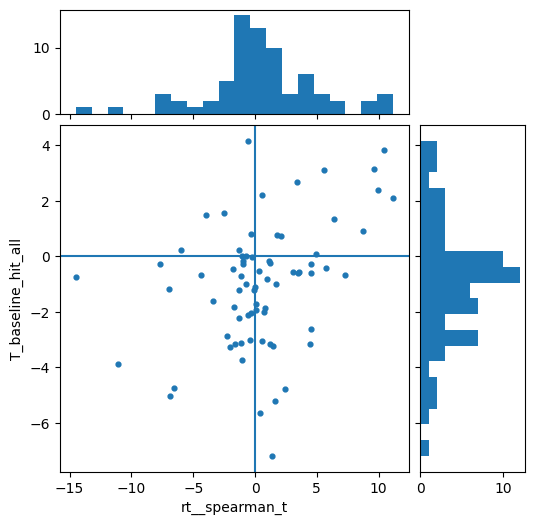

rt__spearman_t vs T_outcome_com_mc: n = 85, rho = -0.098, p = 0.37


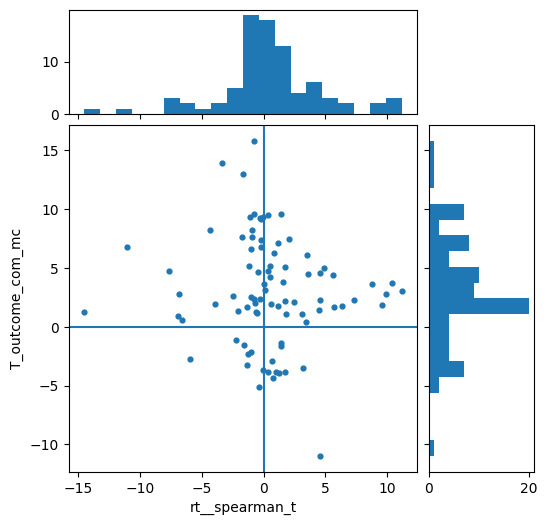

rt__spearman_t vs T_baseline_svs_hit: n = 85, rho = -0.038, p = 0.73


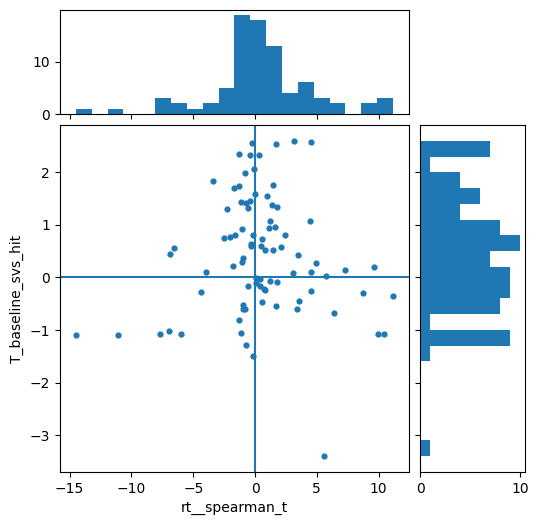

rt__spearman_t vs T_Qchosen_e_ori: n = 85, rho = 0.038, p = 0.73


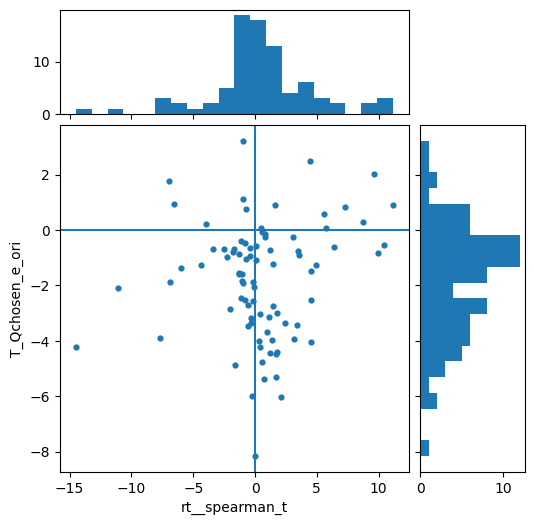

rt_bl__spearman_t vs T_baseline_hit_all: n = 72, rho = -0.275, p = 0.019


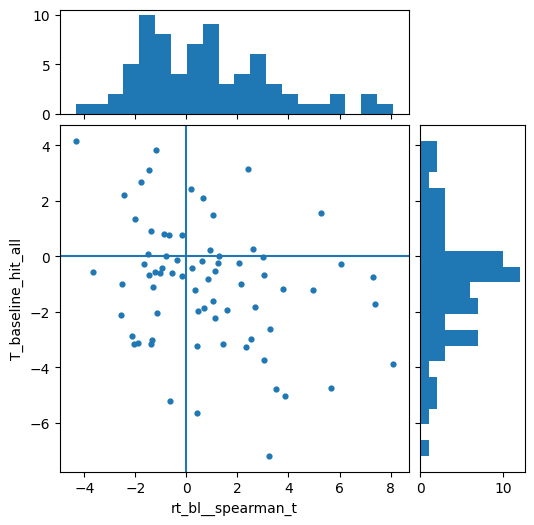

rt_bl__spearman_t vs T_outcome_com_mc: n = 85, rho = -0.047, p = 0.67


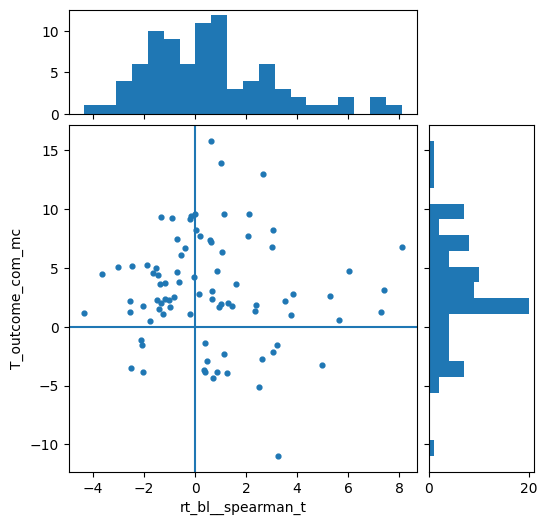

rt_bl__spearman_t vs T_baseline_svs_hit: n = 85, rho = 0.030, p = 0.79


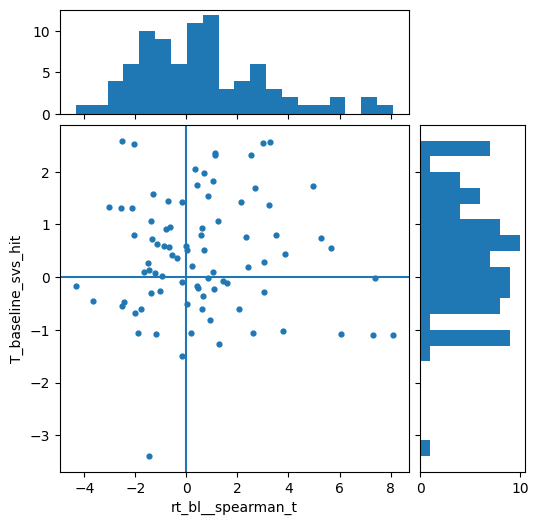

rt_bl__spearman_t vs T_Qchosen_e_ori: n = 85, rho = 0.098, p = 0.37


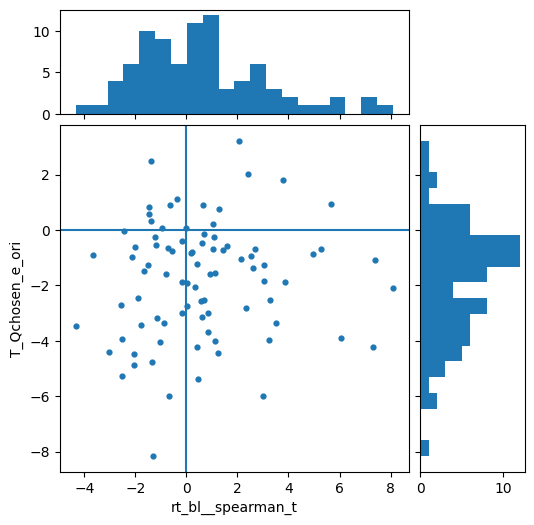

In [140]:


# columns
my_cols  = ["rt__spearman_t", "rt_bl__spearman_t"]
sue_cols = ["T_baseline_hit_all", "T_outcome_com_mc",
            "T_baseline_svs_hit", "T_Qchosen_e_ori"]

def scatter_with_marginals(x, y, x_label, y_label, bins=20):
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]
    n = x.size

    # Spearman correlation
    if n >= 3:
        rho, p = spearmanr(x, y)
        stat_str = f"rho = {rho:.3f}, p = {p:.2g}"
    else:
        rho, p = np.nan, np.nan
        stat_str = "insufficient n"

    # Print results
    print(f"{x_label} vs {y_label}: n = {n}, {stat_str}")

    # layout
    fig = plt.figure(figsize=(6, 6))
    gs = fig.add_gridspec(
        2, 2,
        width_ratios=(4, 1.2),
        height_ratios=(1.2, 4),
        hspace=0.05,
        wspace=0.05
    )

    ax_scatter = fig.add_subplot(gs[1, 0])
    ax_histx   = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
    ax_histy   = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

    # scatter
    ax_scatter.scatter(x, y, s=12)
    ax_scatter.axhline(0)
    ax_scatter.axvline(0)
    ax_scatter.set_xlabel(x_label)
    ax_scatter.set_ylabel(y_label)

    # marginals
    ax_histx.hist(x, bins=bins)
    ax_histy.hist(y, bins=bins, orientation="horizontal")

    ax_histx.tick_params(labelbottom=False)
    ax_histy.tick_params(labelleft=False)

    plt.tight_layout()
    plt.show()


for my_col in my_cols:
    for sue_col in sue_cols:
        x = sue_plus[my_col].to_numpy()
        y = sue_plus[sue_col].to_numpy()
        scatter_with_marginals(x, y, my_col, sue_col, bins=20)

In [123]:


my_cols = ["rt__spearman_t", "rt_bl__spearman_t"]

def spearman_screen_T_cols(
    df: pd.DataFrame,
    my_cols,
    t_prefix: str = "T_",
    *,
    min_n: int = 10,
    rank_by: str = "abs_rho",   # "abs_rho" or "rho" or "p"
) -> dict:
    """
    Compute Spearman correlations between each column in `my_cols`
    and every column in `df` whose name starts with `t_prefix`.

    Returns
    -------
    dict[str, pd.DataFrame]
        Mapping from my_col -> results table with columns:
        ['t_col', 'n', 'rho', 'p', 'abs_rho']
    """
    t_cols = [c for c in df.columns if isinstance(c, str) and c.startswith(t_prefix)]
    if len(t_cols) == 0:
        raise ValueError(f"No columns found starting with prefix '{t_prefix}'")

    out = {}

    for my_col in my_cols:
        if my_col not in df.columns:
            raise ValueError(f"my_col '{my_col}' not found in df.columns")

        rows = []
        x_all = df[my_col].to_numpy()

        for t_col in t_cols:
            y_all = df[t_col].to_numpy()
            m = np.isfinite(x_all) & np.isfinite(y_all)
            n = int(m.sum())

            if n < max(3, min_n):
                rho, p = np.nan, np.nan
            else:
                # spearmanr handles ties; with finite-filtering above, nan_policy is not needed
                rho, p = spearmanr(x_all[m], y_all[m])

            rows.append(
                {"t_col": t_col, "n": n, "rho": rho, "p": p, "abs_rho": np.abs(rho) if np.isfinite(rho) else np.nan}
            )

        res = pd.DataFrame(rows)

        if rank_by == "abs_rho":
            res = res.sort_values(["abs_rho", "p"], ascending=[False, True])
        elif rank_by == "rho":
            res = res.sort_values(["rho", "p"], ascending=[False, True])
        elif rank_by == "p":
            res = res.sort_values(["p", "abs_rho"], ascending=[True, False])
        else:
            raise ValueError("rank_by must be one of: 'abs_rho', 'rho', 'p'")

        out[my_col] = res.reset_index(drop=True)

    return out


# --- run screen ---
tables = spearman_screen_T_cols(
    sue_plus,
    my_cols,
    t_prefix="T_",
    min_n=10,
    rank_by="abs_rho",
)

# dictionary: my_col -> list of top 5 T_ columns
top5_dict = {
    my_col: tables[my_col].head(5)["t_col"].tolist()
    for my_col in my_cols
}

# --- print top 5 for each my_col ---
for my_col, tab in tables.items():
    top5 = tab.head(5).copy()
    print("\n" + "=" * 80)
    print(f"Top 5 T_ correlates for {my_col}")
    print(top5[["t_col", "n", "rho", "p"]].to_string(index=False))


Top 5 T_ correlates for rt__spearman_t
             t_col  n       rho        p
T_response_hit_all 72 -0.535951 0.000001
   T_ratio_hit_all 72 -0.482668 0.000018
   T_Qchosen_l_ori 85  0.327418 0.002223
    T_Qchosen_l_mc 85  0.327418 0.002223
T_baseline_hit_all 72  0.301563 0.010045

Top 5 T_ correlates for rt_bl__spearman_t
               t_col  n       rho        p
  T_baseline_hit_all 72 -0.275420 0.019201
     T_outcome_l_ori 85 -0.246453 0.022982
      T_outcome_l_mc 85 -0.246453 0.022982
T_outcome:ipsi_l_ori 85 -0.243033 0.025013
 T_outcome:ipsi_l_mc 85 -0.243033 0.025013



Plotting top 5 for rt__spearman_t
rt__spearman_t vs T_response_hit_all: n = 72, rho = -0.536, p = 1.2e-06


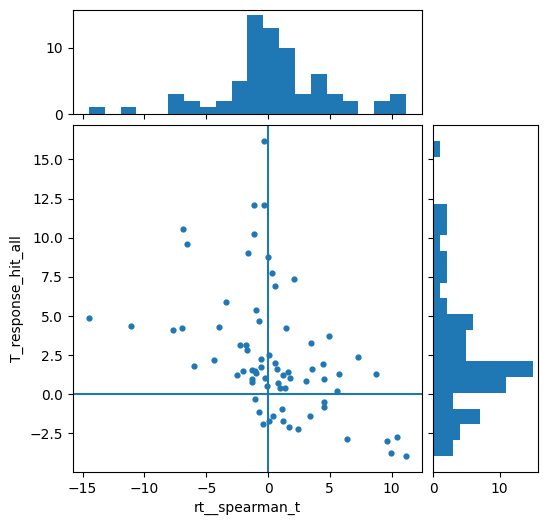

rt__spearman_t vs T_ratio_hit_all: n = 72, rho = -0.483, p = 1.8e-05


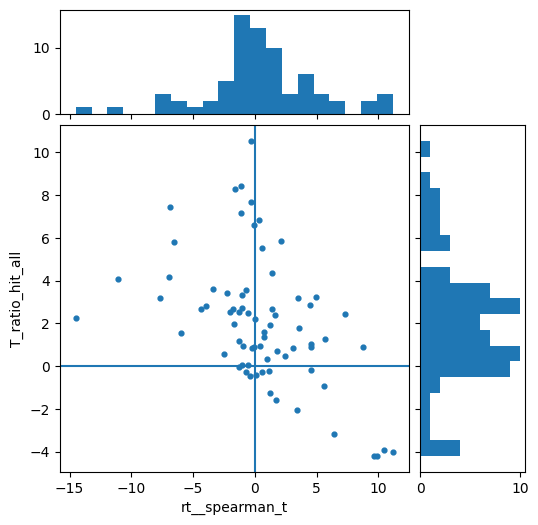

rt__spearman_t vs T_Qchosen_l_ori: n = 85, rho = 0.327, p = 0.0022


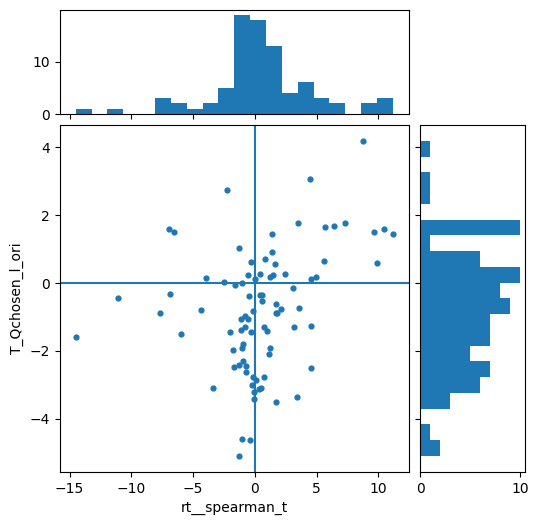

rt__spearman_t vs T_Qchosen_l_mc: n = 85, rho = 0.327, p = 0.0022


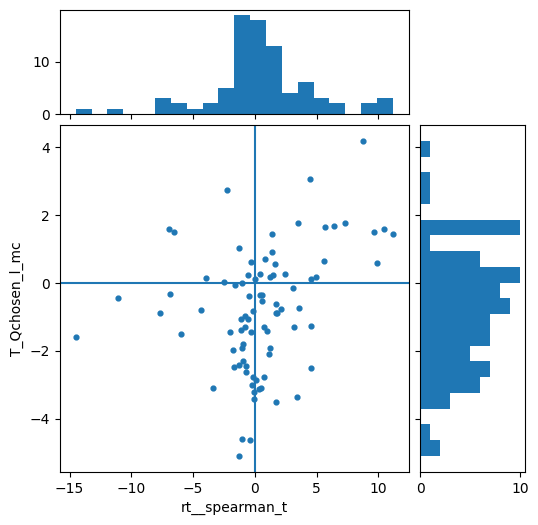

rt__spearman_t vs T_baseline_hit_all: n = 72, rho = 0.302, p = 0.01


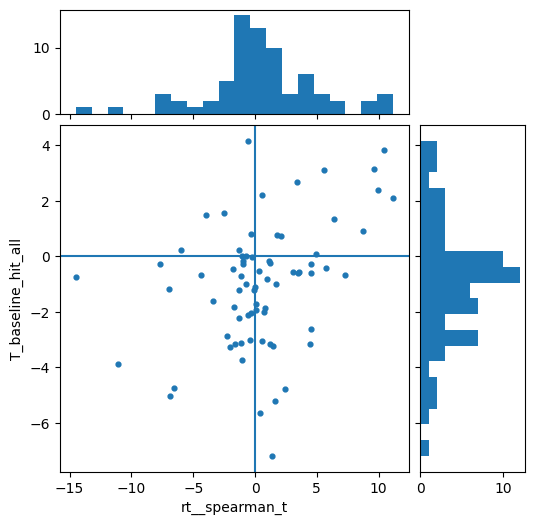


Plotting top 5 for rt_bl__spearman_t
rt_bl__spearman_t vs T_baseline_hit_all: n = 72, rho = -0.275, p = 0.019


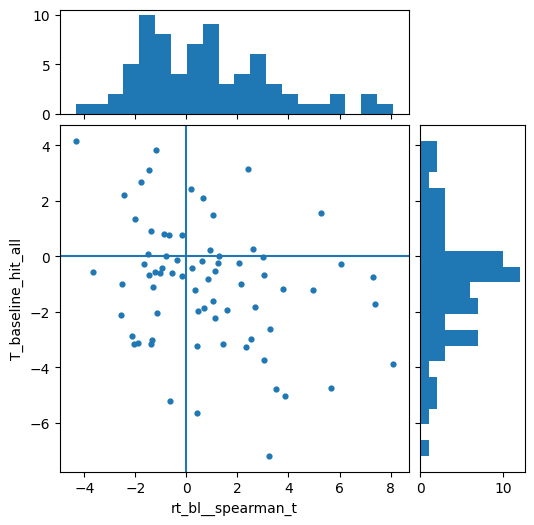

rt_bl__spearman_t vs T_outcome_l_ori: n = 85, rho = -0.246, p = 0.023


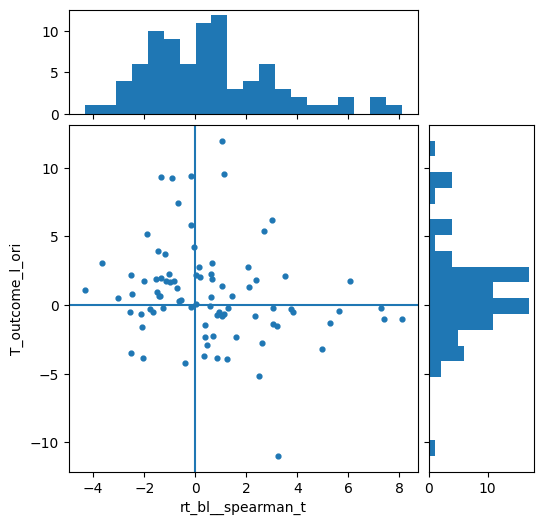

rt_bl__spearman_t vs T_outcome_l_mc: n = 85, rho = -0.246, p = 0.023


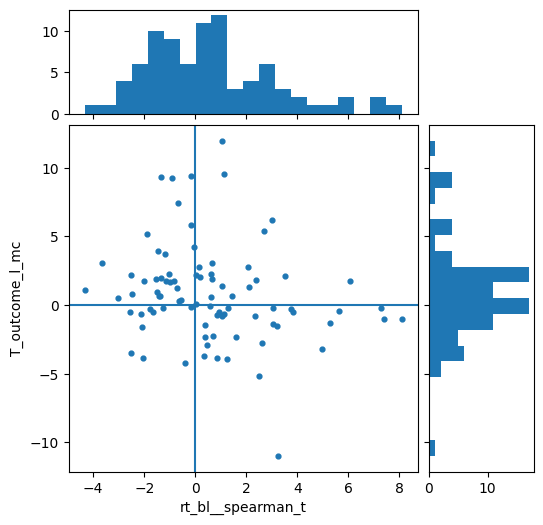

rt_bl__spearman_t vs T_outcome:ipsi_l_ori: n = 85, rho = -0.243, p = 0.025


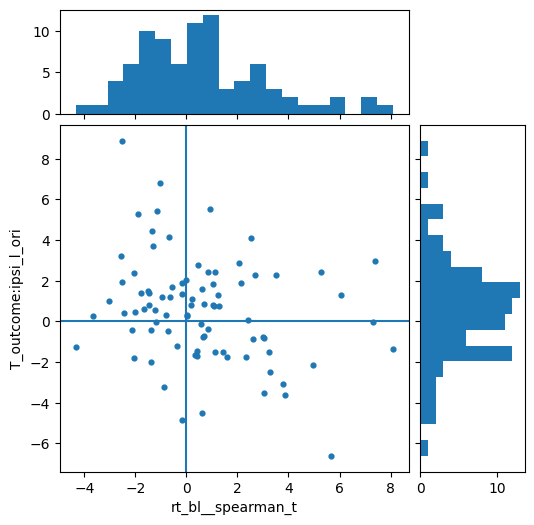

rt_bl__spearman_t vs T_outcome:ipsi_l_mc: n = 85, rho = -0.243, p = 0.025


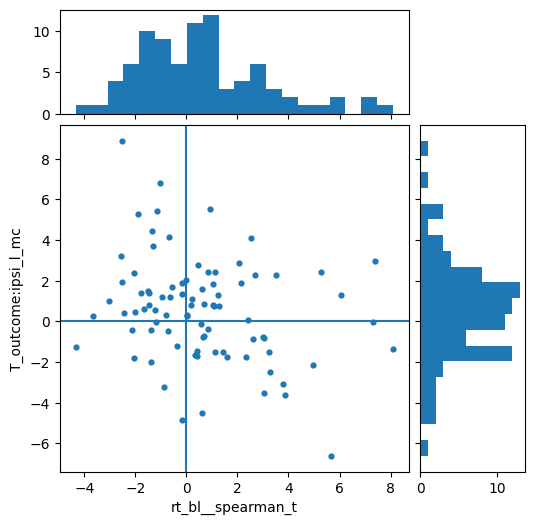

In [124]:
for my_col in my_cols:
    print(f"\nPlotting top 5 for {my_col}")
    for sue_col in top5_dict[my_col]:
        x = sue_plus[my_col].to_numpy()
        y = sue_plus[sue_col].to_numpy()
        scatter_with_marginals(x, y, my_col, sue_col, bins=20)

In [148]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests


def build_sue_plus_with_rt_models(
    *,
    sue_features_path: str,
    all_counts_df: pd.DataFrame,
    get_session_prefix,
    rt_col: str = "reaction_time_firstmove",
    count_col: str = "spike_count",
    baseline_col: str = "baseline_spike_count",
    unit_col_counts: str = "unit_id",
    session_col_counts: str = "session",
    min_trials: int = 50,
    alpha: float = 0.05,
    log_rt: bool = True,
    zscore_rt: bool = True,
) -> pd.DataFrame:
    """
    Compute TWO per-(session_prefix, unit) regressions:
        count_col    ~ 1 + RT
        baseline_col ~ 1 + RT

    Merge those RT regression results into Sue's table on (session_prefix, unit),
    keeping only relevant columns:
        coef_rt, T_rt, p_rt, q_rt
        coef_rt_bl, T_rt_bl, p_rt_bl, q_rt_bl

    Uses robust merge-by-session_prefix+unit with unit canonicalization.
    """

    def canon_unit(x):
        try:
            return str(int(float(x)))
        except Exception:
            return str(x)

    def add_keys(df: pd.DataFrame, session_col: str, unit_col: str) -> pd.DataFrame:
        out = df.copy()
        out[session_col] = out[session_col].astype(str)
        out[unit_col] = out[unit_col].map(canon_unit)
        out["session_prefix"] = out[session_col].map(get_session_prefix).astype(str)
        out["unit"] = out[unit_col].astype(str)
        return out

    def _fit_per_key(counts: pd.DataFrame, y_col: str, *, suffix: str) -> pd.DataFrame:
        rows = []
        for (sp, u), g in counts.groupby(["session_prefix", "unit"]):
            g = g.dropna(subset=[rt_col, y_col])
            if g.empty:
                rows.append({"session_prefix": sp, "unit": u, "n_trials": 0,
                             f"coef_{suffix}": np.nan, f"T_{suffix}": np.nan, f"p_{suffix}": np.nan})
                continue

            rt = g[rt_col].to_numpy(dtype=float)
            y = g[y_col].to_numpy(dtype=float)

            if log_rt:
                m = np.isfinite(rt) & (rt > 0) & np.isfinite(y)
                rt, y = rt[m], y[m]
            else:
                m = np.isfinite(rt) & np.isfinite(y)
                rt, y = rt[m], y[m]

            n = int(rt.size)
            if n < min_trials or np.nanstd(rt) == 0 or np.nanstd(y) == 0:
                rows.append({"session_prefix": sp, "unit": u, "n_trials": n,
                             f"coef_{suffix}": np.nan, f"T_{suffix}": np.nan, f"p_{suffix}": np.nan})
                continue

            x = np.log(rt) if log_rt else rt
            if zscore_rt:
                x = (x - np.nanmean(x)) / np.nanstd(x)

            X = sm.add_constant(x)
            try:
                res = sm.OLS(y, X).fit()
                rows.append({
                    "session_prefix": sp,
                    "unit": u,
                    "n_trials": n,
                    f"coef_{suffix}": float(res.params[1]),
                    f"T_{suffix}": float(res.tvalues[1]),
                    f"p_{suffix}": float(res.pvalues[1]),
                })
            except Exception:
                rows.append({"session_prefix": sp, "unit": u, "n_trials": n,
                             f"coef_{suffix}": np.nan, f"T_{suffix}": np.nan, f"p_{suffix}": np.nan})

        out = pd.DataFrame(rows).reset_index(drop=True)

        # FDR across all keys for this model
        out[f"q_{suffix}"] = np.nan
        m = out[f"p_{suffix}"].notna()
        if m.any():
            _, q, _, _ = multipletests(out.loc[m, f"p_{suffix}"].values, alpha=alpha, method="fdr_bh")
            out.loc[m, f"q_{suffix}"] = q
        return out

    # -----------------------------
    # 1) Sue table (keys)
    # -----------------------------
    sue = pd.read_pickle(sue_features_path).copy()
    sue["session"] = sue["session"].astype(str)
    if "unit_id" in sue.columns and "unit" not in sue.columns:
        sue = sue.rename(columns={"unit_id": "unit"})
    sue["unit"] = sue["unit"].map(canon_unit)

    if "session_prefix" not in sue.columns:
        sue["session_prefix"] = sue["session"].map(get_session_prefix)
    sue["session_prefix"] = sue["session_prefix"].astype(str)

    sue_dups = sue.duplicated(["session_prefix", "unit"]).sum()
    if sue_dups:
        raise ValueError(f"Sue table has {sue_dups} duplicate (session_prefix, unit) keys. Resolve before merging.")

    # -----------------------------
    # 2) Counts table (keys)
    # -----------------------------
    counts = add_keys(all_counts_df, session_col_counts, unit_col_counts)

    for c in [rt_col, count_col, baseline_col]:
        if c not in counts.columns:
            raise ValueError(f"Column '{c}' not found in all_counts_df after keying")

    # -----------------------------
    # 3) Fit the two RT models
    # -----------------------------
    rt_main = _fit_per_key(counts, count_col, suffix="rt")
    rt_base = _fit_per_key(counts, baseline_col, suffix="rt_bl")

    if rt_main.duplicated(["session_prefix", "unit"]).sum():
        raise ValueError("Duplicates in rt_main keys.")
    if rt_base.duplicated(["session_prefix", "unit"]).sum():
        raise ValueError("Duplicates in rt_base keys.")

    rt_models = rt_main.merge(rt_base, on=["session_prefix", "unit"], how="outer", validate="one_to_one")
    rt_models = rt_models.rename(columns={"n_trials_x": "n_trials", "n_trials_y": "n_trials_bl"})

    # keep only relevant columns
    rt_models = rt_models[
        ["session_prefix", "unit",
         "n_trials", "coef_rt", "T_rt", "p_rt", "q_rt",
         "n_trials_bl", "coef_rt_bl", "T_rt_bl", "p_rt_bl", "q_rt_bl"]
    ]

    # -----------------------------
    # Key diagnostics BEFORE merge
    # -----------------------------
    sue_keys = set(zip(sue["session_prefix"], sue["unit"]))
    rt_keys  = set(zip(rt_models["session_prefix"], rt_models["unit"]))
    rt_not_in_sue = sorted(rt_keys - sue_keys)

    print("Sue keys:", len(sue_keys))
    print("RT model keys:", len(rt_keys))
    print("Key overlap:", len(sue_keys & rt_keys))
    print("RT keys NOT in Sue:", len(rt_not_in_sue))
    if rt_not_in_sue:
        print("\nRT keys not found in Sue:")
        for k in rt_not_in_sue:
            print(k)

    # -----------------------------
    # 4) Single merge into Sue
    # -----------------------------
    sue_plus = sue.merge(rt_models, on=["session_prefix", "unit"], how="left", validate="one_to_one")

    print("T_rt missing rate:", float(sue_plus["T_rt"].isna().mean()))
    print("T_rt_bl missing rate:", float(sue_plus["T_rt_bl"].isna().mean()))

    return sue_plus


# =========================
# USAGE
# =========================
sue_plus = build_sue_plus_with_rt_models(
    sue_features_path="/root/capsule/scratch/features_combined_beh_all.pkl",
    all_counts_df=all_counts_df,
    get_session_prefix=get_session_prefix,
    rt_col="reaction_time_firstmove",
    count_col="spike_count",
    baseline_col="baseline_spike_count",
    unit_col_counts="unit_id",
    session_col_counts="session",
    min_trials=50,
    alpha=0.05,
    log_rt=True,
    zscore_rt=True,
)

Sue keys: 297
RT model keys: 103
Key overlap: 85
RT keys NOT in Sue: 18

RT keys not found in Sue:
('behavior_716325_2024-05-31', '197')
('behavior_751004_2024-12-21', '193')
('behavior_751004_2024-12-22', '123')
('behavior_751766_2025-02-11', '49')
('behavior_754897_2025-03-12', '10')
('behavior_754897_2025-03-12', '100')
('behavior_758017_2025-02-05', '39')
('behavior_758017_2025-02-06', '85')
('behavior_758017_2025-02-07', '17')
('behavior_758017_2025-02-07', '31')
('behavior_761038_2025-04-15', '259')
('behavior_761038_2025-04-16', '10')
('behavior_761038_2025-04-16', '47')
('behavior_763590_2025-05-01', '45')
('behavior_782394_2025-04-23', '228')
('behavior_782394_2025-04-24', '100')
('behavior_784806_2025-06-20', '89')
('behavior_791691_2025-06-25', '63')
T_rt missing rate: 0.7138047138047138
T_rt_bl missing rate: 0.7138047138047138


In [149]:
# Print all Sue keys (session_prefix, unit)

sue_keys = sorted(set(zip(sue_plus["session_prefix"], sue_plus["unit"])))

print("Total Sue keys:", len(sue_keys))
print("\nAll Sue keys:\n")

for k in sue_keys:
    print(k)

Total Sue keys: 297

All Sue keys:

('behavior_716325_2024-05-31', '377')
('behavior_716325_2024-05-31', '379')
('behavior_716325_2024-05-31', '87')
('behavior_751004_2024-12-19', '297')
('behavior_751004_2024-12-20', '263')
('behavior_751004_2024-12-20', '268')
('behavior_751004_2024-12-20', '40')
('behavior_751004_2024-12-21', '22')
('behavior_751004_2024-12-21', '33')
('behavior_751004_2024-12-21', '48')
('behavior_751004_2024-12-21', '6')
('behavior_751004_2024-12-23', '145')
('behavior_751004_2024-12-23', '146')
('behavior_751004_2024-12-23', '21')
('behavior_751181_2025-02-25', '14')
('behavior_751181_2025-02-25', '29')
('behavior_751181_2025-02-26', '273')
('behavior_751181_2025-02-26', '39')
('behavior_751181_2025-02-26', '46')
('behavior_751181_2025-02-26', '61')
('behavior_751181_2025-02-26', '62')
('behavior_751181_2025-02-26', '77')
('behavior_751181_2025-02-27', '13')
('behavior_751181_2025-02-27', '244')
('behavior_751181_2025-02-27', '28')
('behavior_751181_2025-02-27', 

In [150]:
import numpy as np
import matplotlib.pyplot as plt


def plot_T_scatter_and_polar(
    df: pd.DataFrame,
    *,
    t_x_col: str,
    t_y_col: str,
    coef_x_col: str,
    coef_y_col: str,
    p_x_col: str = None,     # if provided, highlights points with p_x<thresh and uses them for polar
    thresh: float = 0.05,
    base_filter_col: str = None,  # e.g. "selected"
    tier_col: str = "tier_1",     # optional overlay; skipped if missing
    polar_bins: int = 20,
    figsize=(12, 6),
    title: str = None,
    show: bool = True,
):
    """
    One figure:
      (left) scatter of T stats (t_x vs t_y), with optional highlight by p_x<thresh
      (right) polar histogram of coefficient-vector angles from (coef_x, coef_y)
             using the same subset as highlighted points (or all if p_x_col is None).

    Notes
    -----
    - If p_x_col is not None:
        * scatter: gray filled points are p_x<thresh
        * polar: uses only p_x<thresh points
      If p_x_col is None:
        * scatter: all points
        * polar: all points
    - If tier_col exists, overlays those points on both panels.
    """

    # -----------------------------
    # base filter
    # -----------------------------
    if base_filter_col is None:
        base = np.ones(len(df), dtype=bool)
    else:
        if base_filter_col not in df.columns:
            raise ValueError(f"base_filter_col '{base_filter_col}' not in df.columns")
        base = df[base_filter_col].astype(bool).to_numpy()

    # -----------------------------
    # fetch arrays
    # -----------------------------
    for c in [t_x_col, t_y_col, coef_x_col, coef_y_col]:
        if c not in df.columns:
            raise ValueError(f"Missing column '{c}'")

    T_x = df[t_x_col].to_numpy()
    T_y = df[t_y_col].to_numpy()
    bx  = df[coef_x_col].to_numpy()
    by  = df[coef_y_col].to_numpy()

    p_x = None
    if p_x_col is not None:
        if p_x_col not in df.columns:
            raise ValueError(f"Missing column '{p_x_col}'")
        p_x = df[p_x_col].to_numpy()

    # apply base filter to everything
    T_x, T_y, bx, by = T_x[base], T_y[base], bx[base], by[base]
    if p_x is not None:
        p_x = p_x[base]

    # -----------------------------
    # scatter masks
    # -----------------------------
    m_sc = np.isfinite(T_x) & np.isfinite(T_y)
    if p_x is None:
        m_sig = m_sc
    else:
        m_sig = m_sc & np.isfinite(p_x) & (p_x < thresh)

    # -----------------------------
    # figure layout
    # -----------------------------
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    ax_sc = axes[0]

    # all points
    ax_sc.scatter(T_x[m_sc], T_y[m_sc],
                  facecolors="none", edgecolors="k", s=30, label="all")

    # highlighted points
    if p_x is not None:
        ax_sc.scatter(T_x[m_sig], T_y[m_sig],
                      color="gray", edgecolors="none", s=30,
                      label=f"{p_x_col} < {thresh:g}")

    ax_sc.axhline(0, color="k", linestyle="--", linewidth=1)
    ax_sc.axvline(0, color="k", linestyle="--", linewidth=1)
    ax_sc.set_xlabel(t_x_col)
    ax_sc.set_ylabel(t_y_col)
    ax_sc.set_title("T-statistics")
    ax_sc.legend(frameon=False)

    # polar axis
    axes[1].remove()
    ax_pol = fig.add_subplot(1, 2, 2, polar=True)

    # vectors used in polar
    m_vec = m_sig & np.isfinite(bx) & np.isfinite(by)
    vec = np.column_stack([bx[m_vec], by[m_vec]])

    if vec.shape[0] == 0:
        ax_pol.set_title("Polar histogram (no points after filtering)")
        ax_pol.set_yticks([])
    else:
        edges = np.linspace(-np.pi, np.pi, 4 * polar_bins + 1)
        pos = vec[:, 0] > 0
        neg = ~pos

        theta = np.arctan2(vec[neg, 1], vec[neg, 0])
        ax_pol.hist(theta, bins=edges, alpha=0.7, edgecolor="none", density=True)

        theta = np.arctan2(vec[pos, 1], vec[pos, 0])
        ax_pol.hist(theta, bins=edges, alpha=0.7, edgecolor="none", density=True)

        # theta_all = np.arctan2(vec[:, 1], vec[:, 0])
        # ax_pol.hist(theta_all, bins=edges, alpha=0.5, edgecolor="none", density=True, label="all")
        
        ax_pol.set_yticks([])
        ax_pol.set_title("Polar histogram (coef vectors)")

    # -----------------------------
    # optional tier overlay
    # -----------------------------
    if tier_col in df.columns:
        tier = df[tier_col].astype(bool).to_numpy()[base]
        m_anti_sc = tier & m_sc
        if np.any(m_anti_sc):
            ax_sc.scatter(T_x[m_anti_sc], T_y[m_anti_sc], s=25, alpha=0.6, edgecolors="none", label=tier_col)
            ax_sc.legend(frameon=False)

        m_anti_vec = tier & m_vec
        if np.any(m_anti_vec):
            theta_anti = np.arctan2(by[m_anti_vec], bx[m_anti_vec])
            ax_pol.scatter(theta_anti, 0.9 * np.ones_like(theta_anti), alpha=0.5, edgecolors="none", s=45)
    else:
        print(f"[plot_T_scatter_and_polar] '{tier_col}' not found; skipping overlay.")

    if title:
        fig.suptitle(title, fontsize=14)

    fig.tight_layout()

    if "SAVE_FIG" in globals() and SAVE_FIG:
        if "FIG_DIR" not in globals():
            raise ValueError("SAVE_FIG is True but FIG_DIR is not defined.")

        FIG_DIR.mkdir(parents=True, exist_ok=True)

        fname = f"{t_x_col}_vs_{t_y_col}_scatter_polar"

        png_path = FIG_DIR / f"{fname}.png"
        svg_path = FIG_DIR / f"{fname}.svg"

        fig.savefig(png_path, dpi=300, bbox_inches="tight")
        fig.savefig(svg_path, dpi=300, bbox_inches="tight")

        print(f"Saved:\n  {png_path}\n  {svg_path}")

    if show:
        plt.show()
        return None   # <- prevents duplicate display in notebooks
    else:
        plt.close(fig)
        return fig

In [151]:
# SAVE_FIG = FALSE
FIG_DIR = Path("/root/capsule/scratch/figures/ephys_kinematics_panels/1sbaseline_200msresponse")


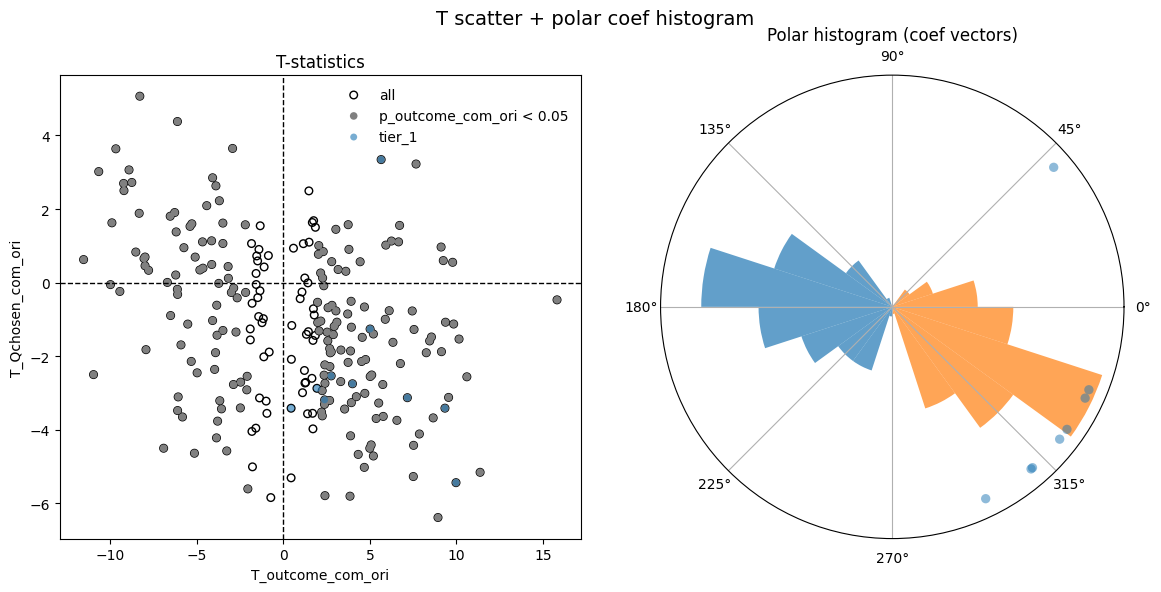

In [152]:
plot_T_scatter_and_polar(
    sue_plus,
    t_x_col="T_outcome_com_ori",
    t_y_col="T_Qchosen_com_ori",
    coef_x_col="coef_outcome_com_ori",
    coef_y_col="coef_Qchosen_com_ori",
    p_x_col="p_outcome_com_ori",   # highlight + polar subset
    thresh=0.05,
    base_filter_col="selected",     # set None if not present
    tier_col="tier_1",
    title="T scatter + polar coef histogram",
    polar_bins=5,
)

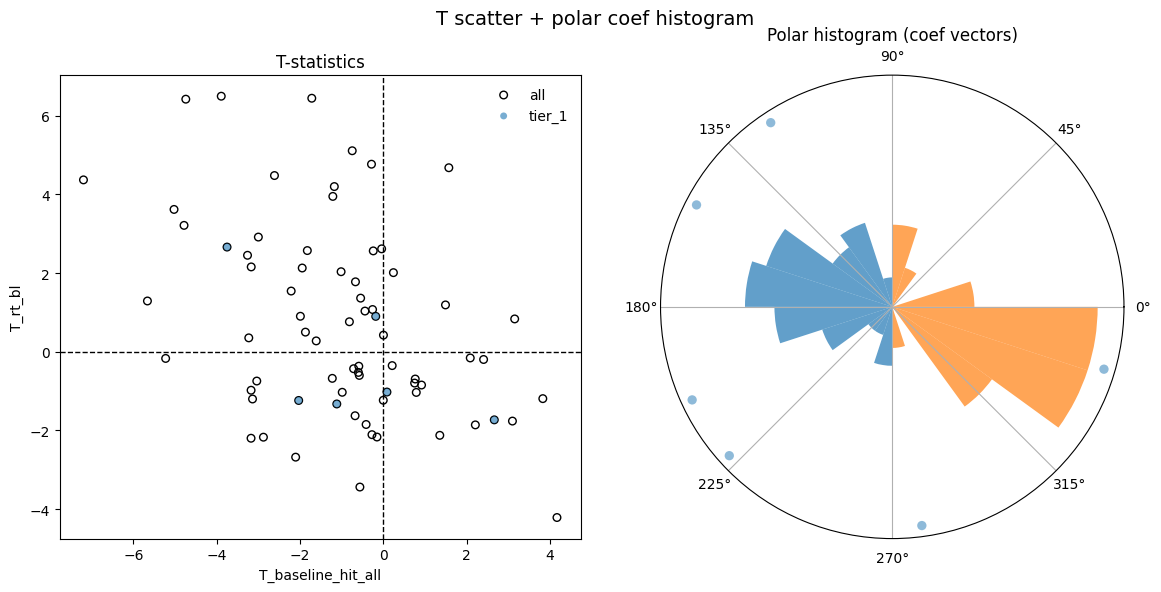

In [154]:
plot_T_scatter_and_polar(
    sue_plus,
    t_x_col="T_baseline_hit_all",
    t_y_col="T_rt_bl",
    coef_x_col="coef_baseline_hit_all",
    coef_y_col="coef_rt_bl",
    polar_bins=5,
    # p_x_col="p_response_hit_all",   # highlight + polar subset
    thresh=0.05,
    # base_filter_col="selected",     # set None if not present
    tier_col="tier_1",
    title="T scatter + polar coef histogram",
)

In [155]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

# --- screen T_rt + T_rt_bl against all Sue T_ cols ---
my_cols = ["T_rt", "T_rt_bl"]

def spearman_screen_T_vs_T(
    df: pd.DataFrame,
    my_cols,
    t_prefix: str = "T_",
    *,
    min_n: int = 10,
    rank_by: str = "abs_rho",   # "abs_rho" or "rho" or "p"
) -> dict:
    t_cols = [c for c in df.columns if isinstance(c, str) and c.startswith(t_prefix)]
    if len(t_cols) == 0:
        raise ValueError(f"No columns found starting with prefix '{t_prefix}'")

    out = {}
    for my_col in my_cols:
        if my_col not in df.columns:
            raise ValueError(f"my_col '{my_col}' not found in df.columns")

        # don't correlate a column with itself
        these_t_cols = [c for c in t_cols if c != my_col]

        x_all = df[my_col].to_numpy()
        rows = []

        for t_col in these_t_cols:
            y_all = df[t_col].to_numpy()
            m = np.isfinite(x_all) & np.isfinite(y_all)
            n = int(m.sum())

            if n < max(3, min_n):
                rho, p = np.nan, np.nan
            else:
                rho, p = spearmanr(x_all[m], y_all[m])

            rows.append(
                {"t_col": t_col, "n": n, "rho": rho, "p": p,
                 "abs_rho": np.abs(rho) if np.isfinite(rho) else np.nan}
            )

        res = pd.DataFrame(rows)

        if rank_by == "abs_rho":
            res = res.sort_values(["abs_rho", "p"], ascending=[False, True])
        elif rank_by == "rho":
            res = res.sort_values(["rho", "p"], ascending=[False, True])
        elif rank_by == "p":
            res = res.sort_values(["p", "abs_rho"], ascending=[True, False])
        else:
            raise ValueError("rank_by must be one of: 'abs_rho', 'rho', 'p'")

        out[my_col] = res.reset_index(drop=True)

    return out


tables = spearman_screen_T_vs_T(
    sue_plus,
    my_cols,
    t_prefix="T_",
    min_n=10,
    rank_by="abs_rho",
)

# top-5 list per RT column
top5_dict = {c: tables[c].head(5)["t_col"].tolist() for c in my_cols}

# print
for c in my_cols:
    top5 = tables[c].head(5)
    print("\n" + "=" * 80)
    print(f"Top 5 Sue T_ correlates for {c}")
    print(top5[["t_col", "n", "rho", "p"]].to_string(index=False))

print("\nTop5 dict:", top5_dict)


Top 5 Sue T_ correlates for T_rt
             t_col  n       rho        p
T_response_hit_all 72 -0.522381 0.000003
   T_ratio_hit_all 72 -0.470738 0.000030
           T_rt_bl 85 -0.424643 0.000051
   T_Qchosen_l_ori 85  0.335001 0.001725
    T_Qchosen_l_mc 85  0.335001 0.001725

Top 5 Sue T_ correlates for T_rt_bl
                  t_col  n       rho        p
                   T_rt 85 -0.424643 0.000051
     T_baseline_hit_all 72 -0.361535 0.001807
        T_outcome_l_ori 85 -0.280066 0.009431
         T_outcome_l_mc 85 -0.280066 0.009431
T_outcome:ipsi_indi_ori 85 -0.213191 0.050112

Top5 dict: {'T_rt': ['T_response_hit_all', 'T_ratio_hit_all', 'T_rt_bl', 'T_Qchosen_l_ori', 'T_Qchosen_l_mc'], 'T_rt_bl': ['T_rt', 'T_baseline_hit_all', 'T_outcome_l_ori', 'T_outcome_l_mc', 'T_outcome:ipsi_indi_ori']}


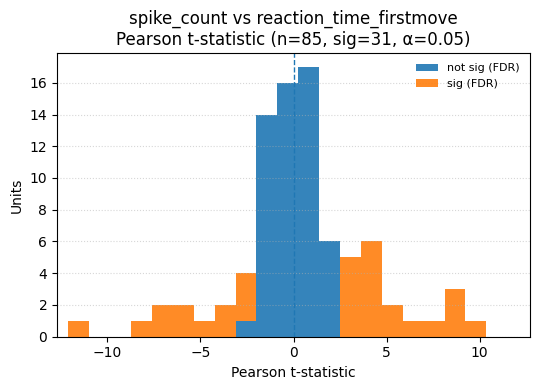

In [118]:
# --- regression (count ~ RT) ---
reg_df = sue_plus[["T_rt", "p_rt", "q_rt"]].rename(
    columns={
        "T_rt": "pearson_t",   # plotter uses this name for metric="t"
        "p_rt": "pearson_p",
        "q_rt": "pearson_q",
    }
).copy()

fig = plot_summary_distribution(
    reg_df,
    alpha=0.05,
    x_label="reaction_time_firstmove",
    y_label="spike_count",
    metric="t",          # uses pearson_t / pearson_q if present
)
plt.show()

PerUnitStatsRegistry (68 entries):
  spkct_vs_rt                               n= 103  sig=  37  source=cor_df
  sue::Qchosen_com_mc                       n=  86  sig=  28  source=sue
  sue::Qchosen_com_ori                      n=  86  sig=  28  source=sue
  sue::Qchosen_e_mc                         n=  86  sig=  35  source=sue
  sue::Qchosen_e_ori                        n=  86  sig=  35  source=sue
  sue::Qchosen_indi_mc                      n=  86  sig=  16  source=sue
  sue::Qchosen_indi_ori                     n=  86  sig=  16  source=sue
  sue::Qchosen_l_mc                         n=  86  sig=  18  source=sue
  sue::Qchosen_l_ori                        n=  86  sig=  18  source=sue
  sue::amp_abs_com_mc                       n=  86  sig=  26  source=sue
  sue::amp_abs_com_ori                      n=  86  sig=  26  source=sue
  sue::amp_abs_e_mc                         n=  86  sig=  34  source=sue
  sue::amp_abs_e_ori                        n=  86  sig=  34  source=sue
  sue::amp_ab

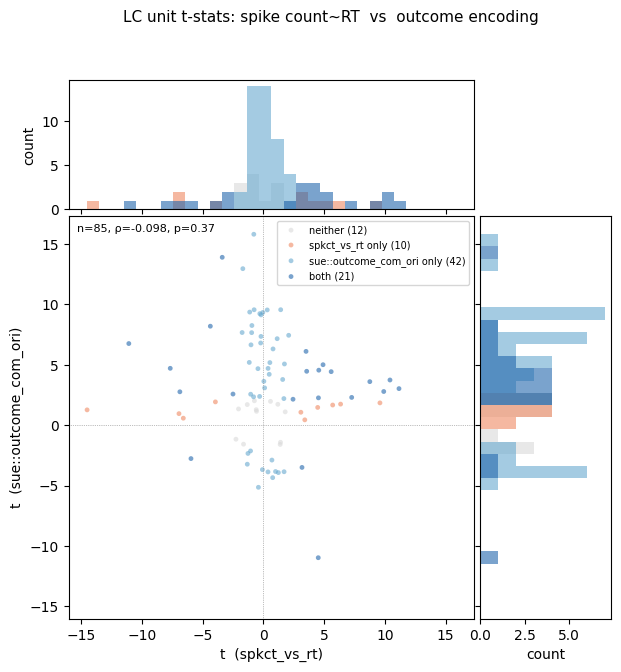

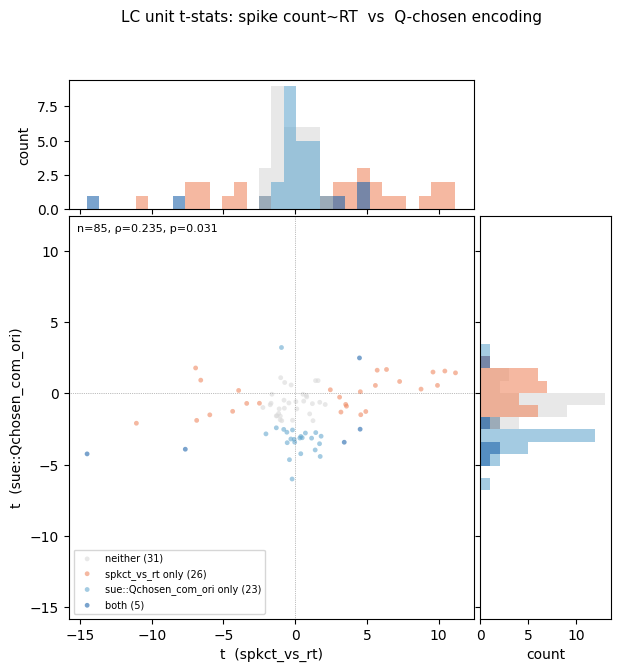


Top 15 Sue variables correlated with RT encoding:
                     entry  n       rho        p  abs_rho
     sue::response_hit_all 72 -0.535951 0.000001 0.535951
        sue::ratio_hit_all 72 -0.482668 0.000018 0.482668
         sue::Qchosen_l_mc 85  0.327418 0.002223 0.327418
        sue::Qchosen_l_ori 85  0.327418 0.002223 0.327418
     sue::baseline_hit_all 72  0.301563 0.010045 0.301563
       sue::Qchosen_com_mc 85  0.234532 0.030735 0.234532
      sue::Qchosen_com_ori 85  0.234532 0.030735 0.234532
         sue::outcome_e_mc 85 -0.232949 0.031913 0.232949
        sue::outcome_e_ori 85 -0.232949 0.031913 0.232949
 sue::outcome:ipsi_indi_mc 85  0.218194 0.044845 0.218194
sue::outcome:ipsi_indi_ori 85  0.218194 0.044845 0.218194
      sue::Qchosen_indi_mc 85  0.212195 0.051220 0.212195
     sue::Qchosen_indi_ori 85  0.212195 0.051220 0.212195
    sue::outcome:ipsi_l_mc 85  0.200215 0.066179 0.200215
   sue::outcome:ipsi_l_ori 85  0.200215 0.066179 0.200215


In [142]:
# %% Registry demo: RT correlation t-stats vs Sue encoding t-stats
#
# Assumes you have already run:
#   - the correlation pipeline  -> spkct_rt (dict with key "cor_df")
#   - Sue's table loaded        -> sue_plus (DataFrame with T_*, p_*, coef_* columns)
#   - get_session_prefix defined

from per_unit_stats_registry import PerUnitStatsRegistry

# --- 1. Build registry ---
reg = PerUnitStatsRegistry(get_session_prefix=get_session_prefix, alpha=0.05)

# Register your Spearman correlation result (accepts the dict directly)
reg.register_cor_df("spkct_vs_rt", spkct_rt)

# Bulk-register all of Sue's T_ columns (each becomes "sue::{suffix}")
reg.register_sue(sue_plus)

# Sanity check
print(reg)                         # shows all entries with n, sig counts
print(reg.get("sue::outcome_com_ori").head())   # peek at one entry

# --- 2. Compare: spike count~RT  vs  outcome encoding ---
merged_outcome = reg.compare(
    "spkct_vs_rt",
    "sue::outcome_com_ori",
    title="LC unit t-stats: spike count~RT  vs  outcome encoding",
)

# --- 3. Compare: spike count~RT  vs  Q-chosen encoding ---
merged_qchosen = reg.compare(
    "spkct_vs_rt",
    "sue::Qchosen_com_ori",
    title="LC unit t-stats: spike count~RT  vs  Q-chosen encoding",
)

# --- 4. Screen RT t-stats against ALL Sue columns at once ---
screen_results = reg.screen("spkct_vs_rt", source="sue", top_n=15)
print("\nTop 15 Sue variables correlated with RT encoding:")
print(screen_results.to_string(index=False))

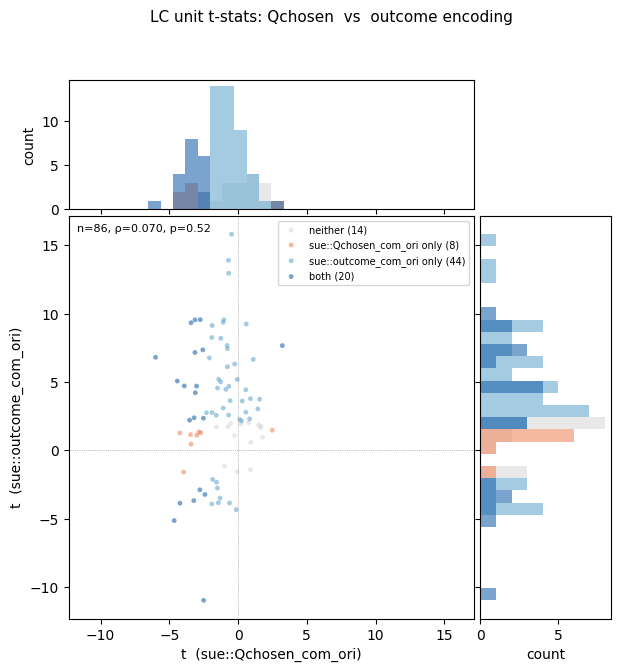

In [143]:
# --- 2. Compare: spike count~RT  vs  outcome encoding ---
merged_outcome_Qchosen = reg.compare(
    "sue::Qchosen_com_ori",
    "sue::outcome_com_ori",
    title="LC unit t-stats: Qchosen  vs  outcome encoding",
)

## Temporal encoding: ridge regression

Time-bin spike counts in a wide peri-event window and fit ridge regression against RT to identify when RT-predictive firing occurs.

In [31]:
#try an analysis via ridge regression to find most relevant bins across the population

analysis_window_s = (-5.00, 2.00)   # 0–300 ms after go cue
bin_width_s = 0.250       # 250 ms bins

bin_edges = np.arange(
    analysis_window_s[0],
    analysis_window_s[1] + 1e-9,   # avoid floating-point off-by-one
    bin_width_s,
)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])


In [32]:
from typing import Sequence

def make_time_binned_unit_df(
    unit_row: pd.Series,
    bundle: dict,
    bin_edges: Sequence[float],
    rt_col: str = "reaction_time_firstmove",
) -> pd.DataFrame:
    """
    For a single unit in a single session, build a per-trial table with:
      - spike counts in multiple post-cue time bins
      - reaction time and other movement features (joined from trial_features).
    
    Returns a DataFrame with columns:
      ['session', 'unit_id', 'trial', 'spk_bin_0', ..., 'spk_bin_{K-1}', rt_col, ...]
    """

    session = bundle["session"]
    unit_id = unit_row["unit_id"]

    # spikes → session time
    spikes = np.asarray(unit_row["spike_times"], dtype=float) - bundle["session_offset"]
    spikes.sort()

    # align times (goCue) per trial
    align_times = bundle["align_times"]  # Series: index=trial, value=t0
    trials = align_times.index
    t0_map = align_times.to_dict()

    # trial_features already has RTs and kinematics
    trial_features = bundle["trial_features"]

    # number of bins
    n_bins = len(bin_edges) - 1

    records = []
    for tr in trials:
        t0 = t0_map.get(tr, np.nan)
        if not np.isfinite(t0):
            continue

        row = {
            "session": session,
            "unit_id": unit_id,
            "trial": int(tr),
        }

        # spike counts for each bin relative to t0
        for k in range(n_bins):
            win_rel = (bin_edges[k], bin_edges[k + 1])  # relative (s) after t0
            n = count_spikes_in_window(spikes, t0, win_rel)
            row[f"spk_bin_{k}"] = int(n)

        records.append(row)

    df_unit = pd.DataFrame(records).set_index("trial")

    # join RT and kinematics
    df_unit = df_unit.join(trial_features, how="left")

    # reset index for convenience
    df_unit = df_unit.reset_index()  # 'trial' becomes a column again

    return df_unit


In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV

def fit_temporal_rt_model(
    df_unit: pd.DataFrame,
    rt_col: str = "reaction_time_firstmove",
    prefix: str = "spk_bin_",
):
    """
    Fit a ridge regression of log(RT) on spike counts across time bins.
    Returns a dict with coefficients, bin names, and the fitted model.
    """

    # pick only trials with both RT and spike bins defined
    bin_cols = [c for c in df_unit.columns if c.startswith(prefix)]
    df = df_unit.dropna(subset=[rt_col] + bin_cols).copy()

    if df.empty:
        raise ValueError("No trials with both RT and spike bins available.")

    X = df[bin_cols].to_numpy(dtype=float)
    y = np.log(df[rt_col].to_numpy(dtype=float))  # log-RT often nicer
    # y = df[rt_col].to_numpy(dtype=float)  # log-RT often nicer

    # standardize predictors
    scaler = StandardScaler()
    Xz = scaler.fit_transform(X)

    # regularization path (you can tweak this grid)
    alphas = np.logspace(-3, 3, 20)

    model = RidgeCV(alphas=alphas, store_cv_values=False)
    model.fit(Xz, y)

    beta = model.coef_  # one coefficient per bin

    return {
        "bin_cols": bin_cols,
        "beta": beta,
        "alpha": model.alpha_,
        "intercept": model.intercept_,
        "scaler": scaler,
        "model": model,
    }


In [34]:

results = []  # stores per-unit outputs

for u in units_with_spikes.itertuples(index=False):
    session = u.session

    # Cache bundles like your other loop
    if session not in bundle_cache:
        print(f"{session} not in session bundle")
        continue

    bundle = bundle_cache[session]

    # Convert tuple row to a pd.Series, same trick you used
    unit_row = pd.Series(u._asdict())

    # ---- STEP 1: time-binned trial table ----
    try:
        df_unit_binned = make_time_binned_unit_df(
            unit_row=unit_row,
            bundle=bundle,
            bin_edges=bin_edges,
            rt_col="reaction_time_firstmove",  # or "reaction_time_cueresponse"
        )
    except Exception as e:
        print(f"[warn] could not build binned df for unit {unit_row.unit_id} in {session}: {e}")
        continue

    # need enough trials to fit model
    bin_cols = [c for c in df_unit_binned.columns if c.startswith("spk_bin_")]
    df_clean = df_unit_binned.dropna(subset=["reaction_time_firstmove"] + bin_cols)
    if len(df_clean) < 10:   # arbitrary low threshold
        print(f"[warn] skipping unit {unit_row.unit_id} in {session} (not enough trials)")
        continue

    # ---- STEP 2: fit ridge model ----
    try:
        fit = fit_temporal_rt_model(
            df_unit_binned,
            rt_col="reaction_time_firstmove",
            prefix="spk_bin_",
        )
    except Exception as e:
        print(f"[warn] model fit failed for unit {unit_row.unit_id} in {session}: {e}")
        continue

    beta = fit["beta"]                 # array length K
    alpha = fit["alpha"]              # chosen ridge regularization
    bin_cols = fit["bin_cols"]

    # store summary row (vector or flattened)
    results.append({
        "session": session,
        "unit_id": unit_row.unit_id,
        "n_trials": len(df_clean),
        "alpha": alpha,
        "beta": beta,                  # store as array
        "bin_centers": bin_centers,    # optionally store as array
    })


ridge_df = pd.DataFrame(results)

# optional: explode betas into separate columns
K = len(bin_centers)
for k in range(K):
    ridge_df[f"beta_{k}"] = ridge_df["beta"].apply(lambda b: float(b[k]))



[warn] model fit failed for unit 12.0 in behavior_761038_2025-04-18_12-37-39: Input y contains infinity or a value too large for dtype('float64').
[warn] model fit failed for unit 15.0 in behavior_761038_2025-04-18_12-37-39: Input y contains infinity or a value too large for dtype('float64').


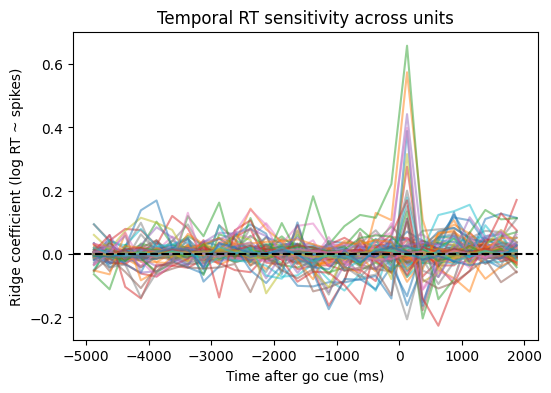

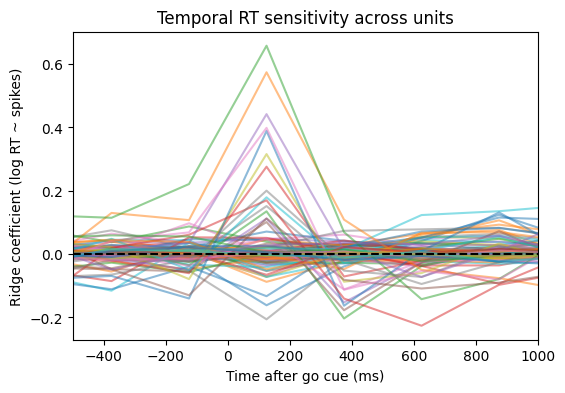

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
for _, row in ridge_df.iterrows():
    plt.plot(bin_centers*1000, row["beta"], alpha=0.5)
plt.axhline(0, ls="--", color="black")
plt.xlabel("Time after go cue (ms)")
plt.ylabel("Ridge coefficient (log RT ~ spikes)")
plt.title("Temporal RT sensitivity across units")
if SAVE_FIG:
    FIG_DIR.mkdir(parents=True, exist_ok=True)

    plt.savefig(FIG_DIR / "spkct_ridge_temporal_sensitivity.png", dpi=300, bbox_inches="tight")
    plt.savefig(FIG_DIR / "spkct_ridge_temporal_sensitivity.svg", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(6,4))
for _, row in ridge_df.iterrows():
    plt.plot(bin_centers*1000, row["beta"], alpha=0.5)
plt.axhline(0, ls="--", color="black")
plt.xlabel("Time after go cue (ms)")
plt.ylabel("Ridge coefficient (log RT ~ spikes)")
plt.title("Temporal RT sensitivity across units")
plt.xlim(-500, 1000) 

if SAVE_FIG:
    FIG_DIR.mkdir(parents=True, exist_ok=True)

    plt.savefig(FIG_DIR / "spkct_ridge_temporal_sensitivity_zoom.png", dpi=300, bbox_inches="tight")
    plt.savefig(FIG_DIR / "spkct_ridge_temporal_sensitivity_zoom.svg", dpi=300, bbox_inches="tight")

plt.show()

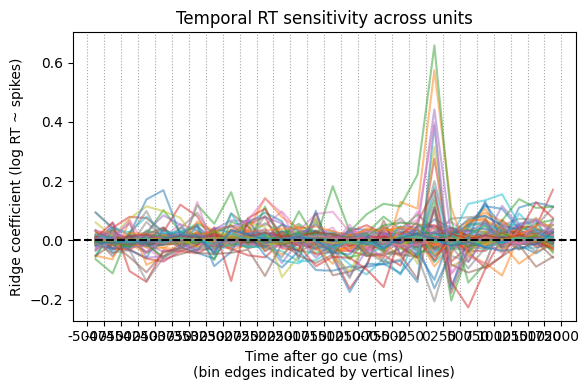

In [39]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))

# per-unit β(t) curves
for _, row in ridge_df.iterrows():
    ax.plot(bin_centers * 1000, row["beta"], alpha=0.5, zorder=1)

# horizontal zero reference
ax.axhline(0, ls="--", color="black", zorder=2)

# ---- vertical lines at bin edges ----
bin_edges_ms = bin_edges * 1000
for be in bin_edges_ms:
    ax.axvline(be, color='grey', linestyle=':', linewidth=0.8, alpha=0.7, zorder=0)

# ---- X axis ticks at bin edges ----
ax.set_xticks(bin_edges_ms)
ax.set_xticklabels([f"{be:.0f}" for be in bin_edges_ms])

# labels
ax.set_xlabel("Time after go cue (ms)\n(bin edges indicated by vertical lines)")
ax.set_ylabel("Ridge coefficient (log RT ~ spikes)")
ax.set_title("Temporal RT sensitivity across units")

plt.tight_layout()
plt.show()


In [40]:
import numpy as np

beta_mat = np.stack(ridge_df["beta"].to_numpy(), axis=0)
mean_beta = beta_mat.mean(axis=0)
sem_beta = beta_mat.std(axis=0, ddof=1) / np.sqrt(beta_mat.shape[0])

bin_width_ms = (bin_edges[1] - bin_edges[0]) * 1000.0


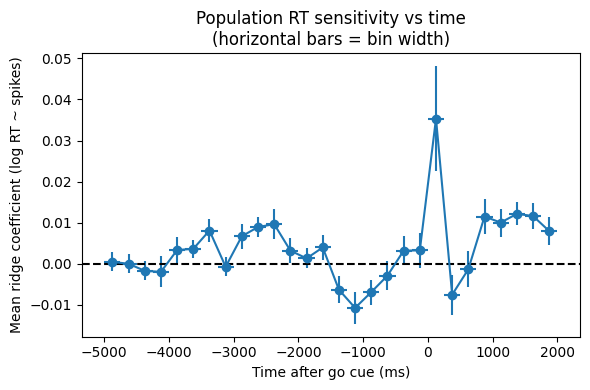

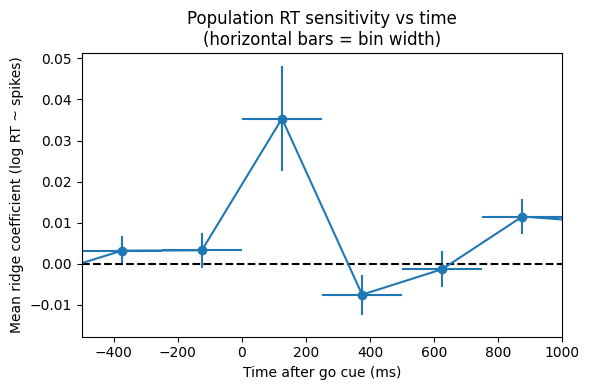

In [41]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(
    bin_centers * 1000,
    mean_beta,
    yerr=sem_beta,
    xerr=bin_width_ms / 2.0,
    fmt="o-",
    capsize=0,
)
ax.axhline(0, ls="--", color="black")
ax.set_xlabel("Time after go cue (ms)")
ax.set_ylabel("Mean ridge coefficient (log RT ~ spikes)")
ax.set_title("Population RT sensitivity vs time\n(horizontal bars = bin width)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(
    bin_centers * 1000,
    mean_beta,
    yerr=sem_beta,
    xerr=bin_width_ms / 2.0,
    fmt="o-",
    capsize=0,
)
ax.axhline(0, ls="--", color="black")
ax.set_xlabel("Time after go cue (ms)")
ax.set_ylabel("Mean ridge coefficient (log RT ~ spikes)")
ax.set_title("Population RT sensitivity vs time\n(horizontal bars = bin width)")
ax.set_xlim(-500, 1000)
plt.tight_layout()
plt.show()


## Window comparison (WIP / archived)

Analyses comparing early vs late spike windows and pre vs post-cue encoding. Code below is preserved for reference but is not run by default.

In [ ]:
# import statsmodels.api as sm


# def _zscore(x: np.ndarray) -> np.ndarray:
#     x = np.asarray(x, dtype=float)
#     mu = np.nanmean(x)
#     sd = np.nanstd(x)  # ddof=0 to match prior code
#     if not np.isfinite(sd) or sd == 0:
#         return np.full_like(x, np.nan, dtype=float)
#     return (x - mu) / sd


# def _circular_shift(arr: np.ndarray, k: int) -> np.ndarray:
#     k = int(k) % len(arr)
#     if k == 0:
#         return arr
#     return np.concatenate([arr[k:], arr[:k]])


# def _fit_sm_ols_betas(y: np.ndarray, x_pre: np.ndarray, x_post: np.ndarray):
#     """
#     OLS: y ~ 1 + z(x_pre) + z(x_post) using statsmodels.
#     Returns betas: (intercept, beta_pre, beta_post)
#     """
#     zpre = _zscore(x_pre)
#     zpost = _zscore(x_post)

#     m = np.isfinite(y) & np.isfinite(zpre) & np.isfinite(zpost)
#     if m.sum() < 10:
#         return None

#     Y = y[m]
#     X = np.column_stack([zpre[m], zpost[m]])
#     X = sm.add_constant(X, has_constant="add")  # adds intercept column

#     res = sm.OLS(Y, X).fit()
#     # params: [const, pre, post]
#     return res.params.astype(float)


# def analyze_unit_joint_rt_model_statsmodels(
#     df_unit: pd.DataFrame,
#     *,
#     rt_col: str = "reaction_time_firstmove",
#     pre_col: str = "baseline_spike_rate_hz",
#     post_col: str = "spike_rate_hz",
#     rt_max_s: float = 1.0,
#     min_trials: int = 20,
#     n_perm: int = 1000,
#     random_state: int = 0,
#     min_shift: int = 5,
# ):
#     """
#     Per-unit joint model using statsmodels OLS:
#         log(RT) ~ 1 + z(pre_rate) + z(post_rate)

#     Significance via circular-shift permutation on y (two-sided).
#     Also returns statsmodels' classic OLS p-values (not drift-robust).
#     """
#     d = df_unit[[rt_col, pre_col, post_col, "trial"]].copy()

#     # filter RT (log RT with cap at 1s)
#     rt = pd.to_numeric(d[rt_col], errors="coerce").to_numpy(dtype=float)
#     keep = np.isfinite(rt) & (rt > 0) & (rt < float(rt_max_s))
#     d = d.loc[keep].copy()
#     if len(d) < int(min_trials):
#         return None

#     # sort so circular shift respects temporal adjacency
#     d = d.sort_values("trial")

#     x_pre = pd.to_numeric(d[pre_col], errors="coerce").to_numpy(dtype=float)
#     x_post = pd.to_numeric(d[post_col], errors="coerce").to_numpy(dtype=float)
#     y = np.log(pd.to_numeric(d[rt_col], errors="coerce").to_numpy(dtype=float))

#     beta = _fit_sm_ols_betas(y, x_pre, x_post)
#     if beta is None:
#         return None

#     b0, bpre, bpost = float(beta[0]), float(beta[1]), float(beta[2])
#     bdiff = float(bpost - bpre)

#     # --- Also compute classic OLS p-values from statsmodels (optional; assumes i.i.d.) ---
#     # Build same design matrix for the observed data
#     zpre = _zscore(x_pre)
#     zpost = _zscore(x_post)
#     m = np.isfinite(y) & np.isfinite(zpre) & np.isfinite(zpost)
#     Y = y[m]
#     X = sm.add_constant(np.column_stack([zpre[m], zpost[m]]), has_constant="add")
#     res = sm.OLS(Y, X).fit()

#     p_pre_ols = float(res.pvalues[1])   # pre
#     p_post_ols = float(res.pvalues[2])  # post

#     # Wald test for beta_post - beta_pre = 0 using covariance of params
#     # L * beta = 0, where L = [0, -1, +1] (const cancels)
#     wald = res.wald_test(np.array([[0.0, -1.0, 1.0]]))
#     p_diff_ols = float(wald.pvalue)

#     # --- circular-shift permutation on y ---
#     rng = np.random.RandomState(random_state)
#     n = len(d)
#     lo = min_shift
#     hi = max(lo + 1, n - min_shift)

#     null_pre = np.zeros(n_perm, dtype=float)
#     null_post = np.zeros(n_perm, dtype=float)
#     null_diff = np.zeros(n_perm, dtype=float)

#     for i in range(n_perm):
#         k = rng.randint(lo, hi)
#         y_perm = _circular_shift(y, k)
#         b = _fit_sm_ols_betas(y_perm, x_pre, x_post)
#         if b is None:
#             null_pre[i] = np.nan
#             null_post[i] = np.nan
#             null_diff[i] = np.nan
#         else:
#             null_pre[i] = float(b[1])
#             null_post[i] = float(b[2])
#             null_diff[i] = float(b[2] - b[1])

#     mpre = np.isfinite(null_pre)
#     mpost = np.isfinite(null_post)
#     mdiff = np.isfinite(null_diff)

#     p_pre_perm = (1.0 + np.sum(np.abs(null_pre[mpre]) >= abs(bpre))) / (mpre.sum() + 1.0)
#     p_post_perm = (1.0 + np.sum(np.abs(null_post[mpost]) >= abs(bpost))) / (mpost.sum() + 1.0)
#     p_diff_perm = (1.0 + np.sum(np.abs(null_diff[mdiff]) >= abs(bdiff))) / (mdiff.sum() + 1.0)

#     return {
#         "n_trials": int(len(d)),
#         "intercept": b0,
#         "beta_pre": bpre,
#         "beta_post": bpost,
#         "beta_post_minus_pre": bdiff,

#         # drift-robust-ish permutation p-values
#         "p_beta_pre_perm": float(p_pre_perm),
#         "p_beta_post_perm": float(p_post_perm),
#         "p_beta_post_minus_pre_perm": float(p_diff_perm),

#         # classic OLS p-values (often optimistic if drift/autocorr)
#         "p_beta_pre_ols": p_pre_ols,
#         "p_beta_post_ols": p_post_ols,
#         "p_beta_post_minus_pre_ols": p_diff_ols,
#     }


In [ ]:
# # new model comparison for baseline vs response windows


# import numpy as np
# import pandas as pd

# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LinearRegression


# # ============================================================
# # 1) Add baseline/response rates to your existing all_counts_df
# # ============================================================
# def add_prepost_rates_from_all_counts(
#     df: pd.DataFrame,
#     *,
#     baseline_window_s=(-1.0, 0.0),
#     response_window_s=(0.0, 0.2),
#     baseline_count_col="baseline_spike_count",
#     response_rate_col="spike_rate_hz",
# ) -> pd.DataFrame:
#     """
#     Uses your existing columns:
#       - baseline_spike_count: spike count in baseline window
#       - spike_rate_hz: response window rate (already count/duration)

#     Adds:
#       - baseline_rate_hz
#       - response_rate_hz (alias of spike_rate_hz)
#       - delta_rate_hz = response - baseline
#     """
#     d = df.copy()

#     base_dur = float(baseline_window_s[1]) - float(baseline_window_s[0])
#     if base_dur <= 0:
#         raise ValueError("baseline_window_s must have positive duration.")
#     resp_dur = float(response_window_s[1]) - float(response_window_s[0])
#     if resp_dur <= 0:
#         raise ValueError("response_window_s must have positive duration.")

#     # baseline: count -> Hz
#     d["baseline_rate_hz"] = pd.to_numeric(d[baseline_count_col], errors="coerce") / base_dur

#     # response: already Hz from your pipeline (dur = cfg.count_window_s)
#     d["response_rate_hz"] = pd.to_numeric(d[response_rate_col], errors="coerce")

#     # "phasic change" proxy
#     d["delta_rate_hz"] = d["response_rate_hz"] - d["baseline_rate_hz"]

#     return d


# # ============================================================
# # 2) Paired, BLOCKED cross-validation comparison (per unit)
# # ============================================================
# def _blocked_splits(n: int, n_splits: int):
#     """
#     Returns list of (train_idx, test_idx) with contiguous test blocks.
#     """
#     idx = np.arange(n)
#     folds = np.array_split(idx, n_splits)
#     splits = []
#     for te_idx in folds:
#         if len(te_idx) == 0:
#             continue
#         tr_idx = np.setdiff1d(idx, te_idx, assume_unique=False)
#         splits.append((tr_idx, te_idx))
#     return splits


# def cv_compare_two_models(
#     df: pd.DataFrame,
#     *,
#     y_col: str,
#     x_cols_A,
#     x_cols_B,
#     n_splits: int = 5,
#     blocked: bool = True,
#     random_state: int = 0,  # kept for API symmetry; not used when blocked=True
#     log_y: bool = True,
# ):
#     """
#     Compare Model A vs Model B with identical CV splits.
#     Returns fold-wise MSE and R2 for each model, plus fold-wise deltas.
#       - delta_mse_folds = mse_A - mse_B  (positive => B is better)
#       - delta_r2_folds  = r2_B - r2_A    (positive => B is better)
#     """
#     need = [y_col] + list(set(x_cols_A) | set(x_cols_B))
#     d = df.dropna(subset=need).copy()
#     if d.empty:
#         return None

#     y = d[y_col].to_numpy(dtype=float)
#     if log_y:
#         if np.any(y <= 0):
#             raise ValueError(f"{y_col} has non-positive values; cannot log-transform.")
#         y = np.log(y)

#     XA = d[list(x_cols_A)].to_numpy(dtype=float)
#     XB = d[list(x_cols_B)].to_numpy(dtype=float)

#     n = len(d)
#     if n < max(10, n_splits * 2):
#         return None

#     if blocked:
#         splits = _blocked_splits(n, n_splits)
#     else:
#         # fallback: random splits (not recommended for LC drift)
#         rng = np.random.RandomState(random_state)
#         idx = np.arange(n)
#         rng.shuffle(idx)
#         folds = np.array_split(idx, n_splits)
#         splits = []
#         for te_idx in folds:
#             tr_idx = np.setdiff1d(idx, te_idx, assume_unique=False)
#             splits.append((tr_idx, te_idx))

#     mse_A, mse_B, r2_A, r2_B = [], [], [], []

#     for tr_idx, te_idx in splits:
#         ytr, yte = y[tr_idx], y[te_idx]

#         # Model A
#         scA = StandardScaler()
#         XA_tr = scA.fit_transform(XA[tr_idx])
#         XA_te = scA.transform(XA[te_idx])
#         mA = LinearRegression().fit(XA_tr, ytr)
#         yhatA = mA.predict(XA_te)

#         # Model B
#         scB = StandardScaler()
#         XB_tr = scB.fit_transform(XB[tr_idx])
#         XB_te = scB.transform(XB[te_idx])
#         mB = LinearRegression().fit(XB_tr, ytr)
#         yhatB = mB.predict(XB_te)

#         # MSE on held-out
#         mseA = float(np.mean((yte - yhatA) ** 2))
#         mseB = float(np.mean((yte - yhatB) ** 2))

#         # R2 on held-out (for reference)
#         ss_tot = float(np.sum((yte - float(np.mean(yte))) ** 2))
#         ssA = float(np.sum((yte - yhatA) ** 2))
#         ssB = float(np.sum((yte - yhatB) ** 2))
#         r2a = np.nan if ss_tot <= 0 else (1.0 - ssA / ss_tot)
#         r2b = np.nan if ss_tot <= 0 else (1.0 - ssB / ss_tot)

#         mse_A.append(mseA); mse_B.append(mseB)
#         r2_A.append(r2a);  r2_B.append(r2b)

#     mse_A = np.array(mse_A, dtype=float)
#     mse_B = np.array(mse_B, dtype=float)
#     r2_A  = np.array(r2_A, dtype=float)
#     r2_B  = np.array(r2_B, dtype=float)

#     return {
#         "mse_A_folds": mse_A,
#         "mse_B_folds": mse_B,
#         "r2_A_folds": r2_A,
#         "r2_B_folds": r2_B,
#         "delta_mse_folds": mse_A - mse_B,  # >0 => B better
#         "delta_r2_folds": r2_B - r2_A,     # >0 => B better
#         "n_folds": len(mse_A),
#     }


# # ============================================================
# # 3) Run all comparisons per unit on your all_counts_df
# # ============================================================
# def run_two_window_model_comparisons(
#     all_counts_df: pd.DataFrame,
#     *,
#     rt_col: str = "reaction_time_firstmove",
#     baseline_window_s=(-1.0, 0.0),
#     response_window_s=(0.0, 0.2),
#     min_trials: int = 20,
#     n_splits: int = 5,
#     blocked: bool = True,
#     log_y: bool = True,
#     rt_max_s: float = 1.0, 
# ):
#     """
#     Produces a tidy per-unit results table with:
#       - baseline-only vs response-only (which is better alone?)
#       - response unique beyond baseline (pre -> pre+post)
#       - baseline unique beyond response (post -> pre+post)
#     """
#     df = add_prepost_rates_from_all_counts(
#         all_counts_df,
#         baseline_window_s=baseline_window_s,
#         response_window_s=response_window_s,
#     )

#     results = []
#     for (sess, uid), g in df.groupby(["session", "unit_id"], sort=False):
#         g = g.dropna(subset=[rt_col, "baseline_rate_hz", "response_rate_hz"])
        
#         # enforce RT bounds
#         rt = pd.to_numeric(g[rt_col], errors="coerce")
#         g = g.loc[(rt > 0) & (rt < float(rt_max_s))].copy()

#         if len(g) < int(min_trials):
#             continue

#         # A) Baseline-only vs Response-only
#         comp_pre_vs_post = cv_compare_two_models(
#             g,
#             y_col=rt_col,
#             x_cols_A=["baseline_rate_hz"],   # A = baseline
#             x_cols_B=["response_rate_hz"],   # B = response
#             n_splits=n_splits,
#             blocked=blocked,
#             log_y=log_y,
#         )

#         # B) Unique response beyond baseline: (baseline) -> (baseline + response)
#         comp_post_given_pre = cv_compare_two_models(
#             g,
#             y_col=rt_col,
#             x_cols_A=["baseline_rate_hz"],                       # reduced A
#             x_cols_B=["baseline_rate_hz", "response_rate_hz"],   # full B
#             n_splits=n_splits,
#             blocked=blocked,
#             log_y=log_y,
#         )

#         # C) Unique baseline beyond response: (response) -> (baseline + response)
#         comp_pre_given_post = cv_compare_two_models(
#             g,
#             y_col=rt_col,
#             x_cols_A=["response_rate_hz"],                       # reduced A
#             x_cols_B=["baseline_rate_hz", "response_rate_hz"],   # full B
#             n_splits=n_splits,
#             blocked=blocked,
#             log_y=log_y,
#         )

#         if (comp_pre_vs_post is None) or (comp_post_given_pre is None) or (comp_pre_given_post is None):
#             continue

#         # summarize fold-wise results (paired)
#         def _summ(comp):
#             dm = comp["delta_mse_folds"]
#             dr = comp["delta_r2_folds"]
#             return {
#                 "delta_mse_mean": float(np.nanmean(dm)),
#                 "delta_mse_median": float(np.nanmedian(dm)),
#                 "delta_mse_frac_pos": float(np.mean(dm > 0)),
#                 "delta_r2_mean": float(np.nanmean(dr)),
#                 "delta_r2_median": float(np.nanmedian(dr)),
#                 "delta_r2_frac_pos": float(np.mean(dr > 0)),
#             }

#         s_pre_vs_post = _summ(comp_pre_vs_post)          # + => response better than baseline (because B=response)
#         s_post_given_pre = _summ(comp_post_given_pre)    # + => full better than baseline-only
#         s_pre_given_post = _summ(comp_pre_given_post)    # + => full better than response-only

#         results.append({
#             "session": sess,
#             "unit_id": uid,
#             "n_trials": int(len(g)),

#             # Which single window predicts better? (A=baseline, B=response)
#             # delta_mse = mse_baseline - mse_response; >0 => response better; <0 => baseline better
#             "pre_vs_post__delta_mse_mean": s_pre_vs_post["delta_mse_mean"],
#             "pre_vs_post__delta_mse_median": s_pre_vs_post["delta_mse_median"],
#             "pre_vs_post__frac_folds_response_better": s_pre_vs_post["delta_mse_frac_pos"],
#             "pre_vs_post__delta_r2_mean": s_pre_vs_post["delta_r2_mean"],

#             # Unique response beyond baseline (A=baseline, B=full)
#             "post_given_pre__delta_mse_mean": s_post_given_pre["delta_mse_mean"],
#             "post_given_pre__delta_mse_median": s_post_given_pre["delta_mse_median"],
#             "post_given_pre__frac_folds_full_better": s_post_given_pre["delta_mse_frac_pos"],
#             "post_given_pre__delta_r2_mean": s_post_given_pre["delta_r2_mean"],

#             # Unique baseline beyond response (A=response, B=full)
#             "pre_given_post__delta_mse_mean": s_pre_given_post["delta_mse_mean"],
#             "pre_given_post__delta_mse_median": s_pre_given_post["delta_mse_median"],
#             "pre_given_post__frac_folds_full_better": s_pre_given_post["delta_mse_frac_pos"],
#             "pre_given_post__delta_r2_mean": s_pre_given_post["delta_r2_mean"],
#         })

#     return pd.DataFrame(results)


# # ============================================================
# # 4) RUN on your existing all_counts_df
# # ============================================================
# all_counts_df = all_counts_df[all_counts_df["reaction_time_firstmove"] > 0].copy() #necessary for the single movement that starts directly on go (rt == 0)

# results_df = run_two_window_model_comparisons(
#     all_counts_df,
#     rt_col="reaction_time_firstmove",  # or "reaction_time_cueresponse"
#     baseline_window_s=(-1.0, 0.0),
#     response_window_s=(0.0, 0.2),
#     min_trials=cfg.min_trials_per_group,  # you set 20
#     n_splits=5,
#     blocked=False,   # recommended for LC drift / slow state
#     log_y=True,
#     rt_max_s=1.0
# )

# print("Units analyzed:", len(results_df))
# display(results_df.head())


# # ============================================================
# # 5) Quick population summaries (interpretation helpers)
# # ============================================================
# if len(results_df):
#     # (1) Which single window is better alone?
#     # pre_vs_post delta_mse_mean > 0 => response better; < 0 => baseline better
#     frac_response_better = float(np.mean(results_df["pre_vs_post__delta_mse_mean"] > 0))
#     med_pre_vs_post = float(np.median(results_df["pre_vs_post__delta_mse_mean"]))

#     # (2) Unique response beyond baseline?
#     frac_post_unique = float(np.mean(results_df["post_given_pre__delta_mse_mean"] > 0))
#     med_post_unique = float(np.median(results_df["post_given_pre__delta_mse_mean"]))

#     # (3) Unique baseline beyond response?
#     frac_pre_unique = float(np.mean(results_df["pre_given_post__delta_mse_mean"] > 0))
#     med_pre_unique = float(np.median(results_df["pre_given_post__delta_mse_mean"]))

#     print("\nPopulation summaries (paired blocked-CV on log RT):")
#     print(f"Response-only better than Baseline-only (ΔMSE>0): {frac_response_better:.3f}  | median ΔMSE = {med_pre_vs_post:.4g}")
#     print(f"Response adds beyond Baseline (post|pre, ΔMSE>0): {frac_post_unique:.3f}  | median ΔMSE = {med_post_unique:.4g}")
#     print(f"Baseline adds beyond Response (pre|post, ΔMSE>0): {frac_pre_unique:.3f}  | median ΔMSE = {med_pre_unique:.4g}")


In [ ]:
# import numpy as np
# import pandas as pd
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LinearRegression

# # ---------- FDR (Benjamini–Hochberg) ----------
# def fdr_bh(pvals: np.ndarray) -> np.ndarray:
#     p = np.asarray(pvals, dtype=float)
#     q = np.full_like(p, np.nan, dtype=float)
#     m = np.sum(np.isfinite(p))
#     if m == 0:
#         return q
#     idx = np.argsort(p)
#     p_sorted = p[idx]
#     ranks = np.arange(1, len(p_sorted) + 1, dtype=float)
#     q_sorted = p_sorted * (len(p_sorted) / ranks)
#     # enforce monotonicity
#     q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]
#     q[idx] = q_sorted
#     return q


# # ---------- unit-level OLS betas (standardized predictors) ----------
# def fit_joint_betas(g: pd.DataFrame, rt_col: str):
#     """
#     Fit log(RT) ~ z(pre) + z(post). Returns standardized betas.
#     """
#     d = g.dropna(subset=[rt_col, "baseline_rate_hz", "response_rate_hz"]).copy()
#     if d.empty:
#         return np.nan, np.nan

#     y = d[rt_col].to_numpy(dtype=float)
#     if np.any(y <= 0):
#         return np.nan, np.nan
#     y = np.log(y)

#     X = d[["baseline_rate_hz", "response_rate_hz"]].to_numpy(dtype=float)
#     Xz = StandardScaler().fit_transform(X)

#     m = LinearRegression().fit(Xz, y)
#     beta_pre, beta_post = m.coef_[0], m.coef_[1]
#     return float(beta_pre), float(beta_post)


# # ---------- unique contribution via paired CV ΔMSE ----------
# def compute_unique_deltas(g: pd.DataFrame, rt_col: str, *, blocked: bool, n_splits: int = 5):
#     """
#     Returns:
#       d_post_given_pre = MSE(pre) - MSE(full)  (positive => post helps beyond pre)
#       d_pre_given_post = MSE(post) - MSE(full) (positive => pre helps beyond post)
#     Uses paired CV within identical folds.
#     """
#     # IMPORTANT: ensure blocked splits follow trial order
#     g = g.sort_values("trial")

#     # post | pre
#     comp = cv_compare_two_models(
#         g, y_col=rt_col,
#         x_cols_A=["baseline_rate_hz"],
#         x_cols_B=["baseline_rate_hz", "response_rate_hz"],
#         n_splits=n_splits,
#         blocked=blocked,
#         log_y=True
#     )
#     if comp is None:
#         return np.nan, np.nan

#     d_post_given_pre = float(np.nanmean(comp["delta_mse_folds"]))  # mse_A - mse_B

#     # pre | post
#     comp2 = cv_compare_two_models(
#         g, y_col=rt_col,
#         x_cols_A=["response_rate_hz"],
#         x_cols_B=["baseline_rate_hz", "response_rate_hz"],
#         n_splits=n_splits,
#         blocked=blocked,
#         log_y=True
#     )
#     if comp2 is None:
#         return d_post_given_pre, np.nan

#     d_pre_given_post = float(np.nanmean(comp2["delta_mse_folds"]))
#     return d_post_given_pre, d_pre_given_post


# # ---------- circular-shift permutation (preserves drift-ish structure) ----------
# def circular_shift(arr: np.ndarray, k: int) -> np.ndarray:
#     k = int(k) % len(arr)
#     if k == 0:
#         return arr
#     return np.concatenate([arr[k:], arr[:k]])


# def permutation_pvalue_circular(
#     g: pd.DataFrame,
#     rt_col: str,
#     stat_fn,
#     *,
#     n_perm: int = 200,
#     blocked: bool = True,
#     n_splits: int = 5,
#     random_state: int = 0,
#     min_shift: int = 5,
# ):
#     """
#     stat_fn(g, rt_col, blocked=..., n_splits=...) -> float (or tuple; see wrapper below)
#     We circularly shift RT across trials (after sorting by trial).
#     Two-sided p-value on the returned scalar.
#     """
#     d = g.dropna(subset=[rt_col, "baseline_rate_hz", "response_rate_hz"]).copy()
#     d = d.sort_values("trial")
#     y = d[rt_col].to_numpy(dtype=float)

#     # observed
#     obs = stat_fn(d, rt_col, blocked=blocked, n_splits=n_splits)

#     if (not np.isfinite(obs)) or (len(d) < 20):
#         return np.nan, obs, None

#     rng = np.random.RandomState(random_state)
#     n = len(d)

#     null = np.zeros(n_perm, dtype=float)
#     for i in range(n_perm):
#         # avoid trivial shifts
#         k = rng.randint(min_shift, max(min_shift + 1, n - min_shift))
#         d_perm = d.copy()
#         d_perm[rt_col] = circular_shift(y, k)
#         null[i] = stat_fn(d_perm, rt_col, blocked=blocked, n_splits=n_splits)

#     # two-sided p
#     p = (1.0 + np.sum(np.abs(null) >= np.abs(obs))) / (n_perm + 1.0)
#     return float(p), float(obs), null


# # wrappers so stat_fn returns a scalar
# def stat_beta_pre(g, rt_col, **kwargs):
#     bpre, _ = fit_joint_betas(g, rt_col)
#     return bpre

# def stat_beta_post(g, rt_col, **kwargs):
#     _, bpost = fit_joint_betas(g, rt_col)
#     return bpost

# def stat_d_post_given_pre(g, rt_col, blocked=True, n_splits=5, **kwargs):
#     dpost, _ = compute_unique_deltas(g, rt_col, blocked=blocked, n_splits=n_splits)
#     return dpost

# def stat_d_pre_given_post(g, rt_col, blocked=True, n_splits=5, **kwargs):
#     _, dpre = compute_unique_deltas(g, rt_col, blocked=blocked, n_splits=n_splits)
#     return dpre


# # ---------- main driver ----------
# def subtype_analysis(
#     all_counts_df: pd.DataFrame,
#     *,
#     rt_col="reaction_time_firstmove",
#     min_trials=20,
#     blocked=True,
#     n_splits=5,
#     n_perm=200,
#     rt_max_s=None,   # e.g., 1.0 to cap
# ):
#     df = add_prepost_rates_from_all_counts(all_counts_df)

#     rows = []
#     for (sess, uid), g in df.groupby(["session", "unit_id"], sort=False):
#         g = g.dropna(subset=[rt_col, "baseline_rate_hz", "response_rate_hz"]).copy()
#         if rt_max_s is not None:
#             g = g[(g[rt_col] > 0) & (g[rt_col] < float(rt_max_s))].copy()
#         else:
#             g = g[g[rt_col] > 0].copy()

#         if len(g) < int(min_trials):
#             continue

#         # effect sizes
#         beta_pre, beta_post = fit_joint_betas(g, rt_col)
#         d_post, d_pre = compute_unique_deltas(g, rt_col, blocked=blocked, n_splits=n_splits)

#         # significance via circular shift permutation
#         p_bpre, _, _ = permutation_pvalue_circular(
#             g, rt_col, stat_beta_pre, n_perm=n_perm, blocked=blocked, n_splits=n_splits, random_state=0
#         )
#         p_bpost, _, _ = permutation_pvalue_circular(
#             g, rt_col, stat_beta_post, n_perm=n_perm, blocked=blocked, n_splits=n_splits, random_state=1
#         )
#         p_dpost, _, _ = permutation_pvalue_circular(
#             g, rt_col, stat_d_post_given_pre, n_perm=n_perm, blocked=blocked, n_splits=n_splits, random_state=2
#         )
#         p_dpre, _, _ = permutation_pvalue_circular(
#             g, rt_col, stat_d_pre_given_post, n_perm=n_perm, blocked=blocked, n_splits=n_splits, random_state=3
#         )

#         rows.append({
#             "session": sess,
#             "unit_id": uid,
#             "n_trials": int(len(g)),
#             "beta_pre": beta_pre,
#             "beta_post": beta_post,
#             "d_post_given_pre": d_post,
#             "d_pre_given_post": d_pre,
#             "p_beta_pre": p_bpre,
#             "p_beta_post": p_bpost,
#             "p_d_post_given_pre": p_dpost,
#             "p_d_pre_given_post": p_dpre,
#         })

#     out = pd.DataFrame(rows)

#     # FDR across units (separately for each test)
#     for pcol in ["p_beta_pre", "p_beta_post", "p_d_post_given_pre", "p_d_pre_given_post"]:
#         out[pcol.replace("p_", "q_")] = fdr_bh(out[pcol].to_numpy())

#     # Simple subtype labels based on significant betas (you can choose q<0.05)
#     qthr = 0.05
#     sig_pre  = out["q_beta_pre"]  < qthr
#     sig_post = out["q_beta_post"] < qthr

#     subtype = np.full(len(out), "none", dtype=object)
#     subtype[sig_pre & ~sig_post] = "baseline-only"
#     subtype[~sig_pre & sig_post] = "response-only"
#     subtype[sig_pre & sig_post]  = "both"

#     # add sign info (often useful)
#     sign = np.full(len(out), "", dtype=object)
#     sign[sig_pre]  = sign[sig_pre]  + np.where(out.loc[sig_pre, "beta_pre"]  > 0, "pre+", "pre-")
#     sign[sig_post] = sign[sig_post] + np.where(out.loc[sig_post, "beta_post"] > 0, " post+", " post-")

#     out["subtype"] = subtype
#     out["sig_sign"] = sign

#     return out


# # -------- run it --------
# subtypes_df = subtype_analysis(
#     all_counts_df,
#     rt_col="reaction_time_firstmove",
#     min_trials=cfg.min_trials_per_group,
#     blocked=True,     # keep this if you care about robustness to drift
#     n_splits=5,
#     n_perm=5000,       # bump to 1000 later for final numbers
#     rt_max_s=1.0,      # optional, as you asked earlier
# )

# display(subtypes_df.head())

# print("\nSubtype counts (q<0.05 on betas):")
# print(subtypes_df["subtype"].value_counts(dropna=False))

# print("\nSign patterns among significant units:")
# print(subtypes_df.loc[subtypes_df["subtype"] != "none", "sig_sign"].value_counts().head(20))

# print("\nHow many units show unique contributions (q<0.05)?")
# print("post|pre unique:", int((subtypes_df["q_d_post_given_pre"] < 0.05).sum()))
# print("pre|post unique:", int((subtypes_df["q_d_pre_given_post"] < 0.05).sum()))


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt


def analyze_unit_rt_encoding(
    df: pd.DataFrame,
    rt_col: str = "reaction_time_firstmove",
    firing_col: str = "spike_count",
    min_trials: int = 30,
    alpha: float = 0.05,
    log_rt: bool = False,
) -> pd.DataFrame:
    """
    For each (unit_id, session), fit an encoding model:

        RT ~ 1 + firing

    and return one row per unit with:
        - n_trials (used in the regression)
        - beta_firing (slope)
        - t_firing   (t-statistic for slope)
        - p_firing   (p-value for slope)
        - q_firing   (FDR-corrected p-value across units)
        - firing_sig_fdr (True/False)

    If log_rt=True, uses log(RT) as the dependent variable.
    Trials with RT <= 0 are dropped in that case.
    """
    rows = []

    # group by unit and session, like your correlation code
    for (uid, sess), g in df.groupby(["unit_id", "session"]):
        # drop NaNs for the columns we care about
        g = g.dropna(subset=[rt_col, firing_col])
        if g.empty:
            rows.append(
                {
                    "unit_id": uid,
                    "session": sess,
                    "n_trials": 0,
                    "beta_firing": np.nan,
                    "t_firing": np.nan,
                    "p_firing": np.nan,
                }
            )
            continue

        rt = g[rt_col].to_numpy()
        firing = g[firing_col].to_numpy()

        if log_rt:
            mask_pos = rt > 0
            g = g.loc[mask_pos]
            rt = rt[mask_pos]
            firing = firing[mask_pos]

        n = len(rt)
        if n < min_trials:
            rows.append(
                {
                    "unit_id": uid,
                    "session": sess,
                    "n_trials": n,
                    "beta_firing": np.nan,
                    "t_firing": np.nan,
                    "p_firing": np.nan,
                }
            )
            continue

        # need variance in RT and firing to fit something meaningful
        if np.nanstd(rt) == 0 or np.nanstd(firing) == 0:
            rows.append(
                {
                    "unit_id": uid,
                    "session": sess,
                    "n_trials": n,
                    "beta_firing": np.nan,
                    "t_firing": np.nan,
                    "p_firing": np.nan,
                }
            )
            continue

        # y = RT (or log RT), X = [1, firing]
        y = np.log(rt) if log_rt else rt
        X = sm.add_constant(firing)  # shape (n, 2)

        try:
            model = sm.OLS(y, X)
            res = model.fit()
            beta_firing = float(res.params[1])
            t_firing = float(res.tvalues[1])
            p_firing = float(res.pvalues[1])
        except Exception:
            beta_firing = np.nan
            t_firing = np.nan
            p_firing = np.nan

        rows.append(
            {
                "unit_id": uid,
                "session": sess,
                "n_trials": n,
                "beta_firing": beta_firing,
                "t_firing": t_firing,
                "p_firing": p_firing,
            }
        )

    out = (
        pd.DataFrame(rows)
        .sort_values(["session", "unit_id"])
        .reset_index(drop=True)
    )

    # FDR correction across units for the firing effect
    m = out["p_firing"].notna()
    if m.any():
        _, qvals, _, _ = multipletests(
            out.loc[m, "p_firing"].values,
            alpha=alpha,
            method="fdr_bh",
        )
        out.loc[m, "q_firing"] = qvals
        out["firing_sig_fdr"] = out["q_firing"] < alpha
    else:
        out["q_firing"] = np.nan
        out["firing_sig_fdr"] = False

    return out


def plot_rt_tstat_summary(
    rt_df: pd.DataFrame,
    alpha: float = 0.05,
    x_label: str = "t-statistic for firing (RT ~ firing)",
    title_suffix: str = "",
):
    """
    Given the output of analyze_unit_rt_encoding(), plot:
      - histogram of t_firing across units
      - mark FDR-significant units (optional)
    """
    valid = rt_df.dropna(subset=["t_firing"])
    if valid.empty:
        print("No valid t_firing values to summarize.")
        return None

    tvals = valid["t_firing"].to_numpy()
    sig = valid.get("firing_sig_fdr", pd.Series(False, index=valid.index)).to_numpy()

    fig, ax = plt.subplots(1, 1, figsize=(5, 4))

    # simple histogram
    bins = np.histogram_bin_edges(tvals, bins=25)
    hist, edges = np.histogram(tvals, bins=bins)
    hist_sig, _ = np.histogram(tvals[sig], bins=bins)
    widths = np.diff(edges)

    ax.bar(edges[:-1], hist - hist_sig, width=widths, align="edge", alpha=0.7, label="not sig (FDR)")
    ax.bar(edges[:-1], hist_sig,        width=widths, align="edge", alpha=0.9, label="sig (FDR)")

    ax.axvline(0, ls="--", color="k", lw=1)
    ax.set_xlabel(x_label)
    ax.set_ylabel("Units")

    n_units = len(tvals)
    n_sig = int(sig.sum())
    ax.set_title(f"Distribution of RT encoding t-stats\n(n={n_units}, FDR sig={n_sig}, α={alpha}){title_suffix}")

    ax.legend(frameon=False, fontsize=8)
    ax.grid(True, axis="y", ls=":", alpha=0.5)
    plt.tight_layout()
    return fig


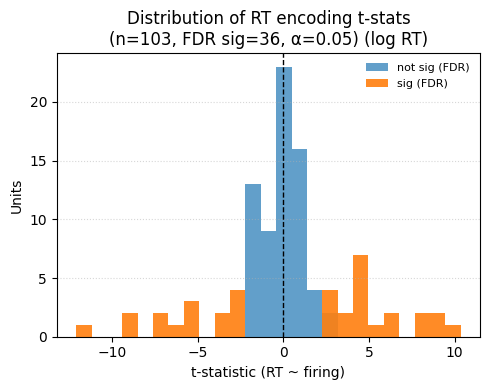

In [ ]:
# 1) Filter/prepare your trial-level df as usual (QC, etc.)
df = all_counts_df.copy()  # or whatever cleaned df you're using

# 2) Run the encoding model per unit
rt_enc = analyze_unit_rt_encoding(
    df,
    rt_col="reaction_time_firstmove",
    firing_col="spike_count",
    min_trials=50,
    alpha=0.05,
    log_rt=True,  # or False if you want raw RT
)

# 3) Plot the distribution of t-stats across units
fig = plot_rt_tstat_summary(
    rt_enc,
    alpha=0.05,
    x_label="t-statistic (RT ~ firing)",
    title_suffix=" (log RT)"  # optional
)
plt.show()


## Single-trial kinematics & session timecourse

Plot tongue trajectory for individual trials; examine slow modulation of kinematics across a session.

In [ ]:
def plot_kinematics_for_trial(
    kins: pd.DataFrame,
    trial: int,
    cols=None,
    time_col: str = "time_in_session",
    color_by: str = "movement_id",   # default: color by movement
    cmap: str = "tab20",
    s: float = 6,
    lw: float = 0.5,
    title: str = None,
    return_fig: bool = False,
):
    """
    Plot kinematic column(s) over time for a single trial with scatter + line overlay.

    Parameters
    ----------
    kins : pd.DataFrame
        Must contain `trial` and a time column (e.g. time_in_session).
    trial : int
        Trial number to plot.
    cols : str or list of str, optional
        Kinematic columns to plot. If None, defaults to ['x', 'y'].
    time_col : str
        Time column for x-axis.
    color_by : str or None
        Column to use for point color (default 'movement_id').
        If None or not in kins, uses a uniform color.
    cmap : str
        Matplotlib colormap when color_by is used.
    s : float
        Scatter point size.
    lw : float
        Line width.
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd

    if cols is None:
        cols = ["x", "y"]
    if isinstance(cols, str):
        cols = [cols]

    df = kins[kins["trial"] == trial].copy()
    if df.empty:
        raise ValueError(f"No rows found for trial {trial}.")

    df = df.sort_values(time_col)

    fig, ax = plt.subplots(figsize=(10, 3))

    # ----- determine coloring strategy -----
    color_vals = None
    lut = None
    if color_by is not None and color_by in df.columns:
        color_vals = df[color_by].to_numpy()
        unique_vals = np.unique(color_vals)

        # exclude NaNs from the lookup table; they get a default color
        valid_vals = [v for v in unique_vals if not pd.isna(v)]
        cmap_obj = plt.get_cmap(cmap)
        lut = {val: cmap_obj(i % cmap_obj.N) for i, val in enumerate(valid_vals)}
        default_nan_color = "lightgray"
    else:
        default_nan_color = "gray"

    # ----- plot -----
    for col in cols:
        if col not in df.columns:
            print(f"Warning: column '{col}' not found in kins; skipping.")
            continue

        # line for continuity
        ax.plot(df[time_col], df[col], color="black", alpha=0.3, linewidth=lw, zorder=1)

        # scatter with color mapping
        if color_vals is not None and lut is not None:
            colors = [
                lut.get(val, default_nan_color)
                for val in color_vals
            ]
            ax.scatter(df[time_col], df[col], s=s, c=colors, edgecolor="none", zorder=2)
        else:
            ax.scatter(df[time_col], df[col], s=s, color=default_nan_color,
                       edgecolor="none", zorder=2)

    ax.set_xlabel(time_col)
    ax.set_ylabel("Kinematic value")

    if title is not None:
        ax.set_title(title)
    else:
        title_cols = ", ".join(cols)
        ax.set_title(f"Trial {trial} — {title_cols}")

        # legend only if color_by is valid and we have non-NaN values
    if color_vals is not None and lut is not None and len(lut) > 0:
        # sort movement ids numerically, take first 3
        sorted_vals = sorted(lut.keys(), key=lambda x: (x is np.nan, x))
        limited_vals = sorted_vals[:3]

        handles = [
            plt.Line2D([0], [0], marker='o', linestyle='', color=lut[val], label=str(val))
            for val in limited_vals
        ]

        # ellipsis entry if there are more than 3
        if len(sorted_vals) > 3:
            handles.append(
                plt.Line2D([0], [0], marker='', linestyle='', label="…")
            )

        # add NaN entry if present
        if np.any(pd.isna(color_vals)):
            handles.append(
                plt.Line2D([0], [0], marker='o', linestyle='', color=default_nan_color, label="NaN")
            )

        ax.legend(handles=handles, title=color_by,
                  bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7)


    ax.grid(True, linestyle=":", alpha=0.4)
    plt.tight_layout()

    if return_fig:
        return fig
    else:
        plt.show()


In [ ]:
# attempt at slow timecourse (over trials or session)

example = load_example_session_and_unit(units_with_spikes, cfg, idx=96)

session  = example["session"]
unit_id  = example["unit_id"]
spikes   = example["spikes_session_time"]
movs     = example["movs"]
kins     = example["kins"]
trials   = example["trials"]
events   = example["events"]

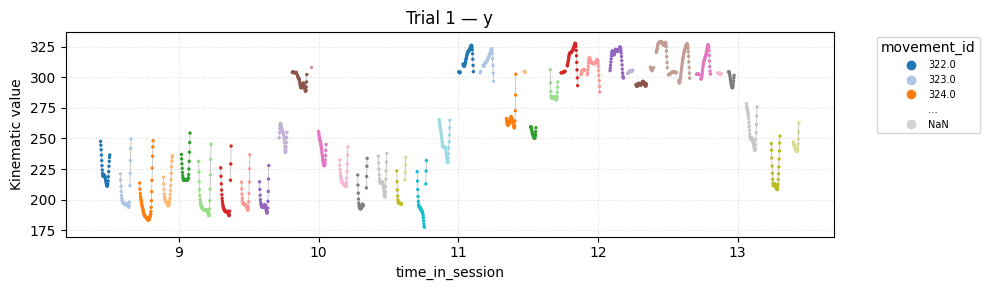

In [ ]:
plot_kinematics_for_trial(kins, trial=1, cols="y")


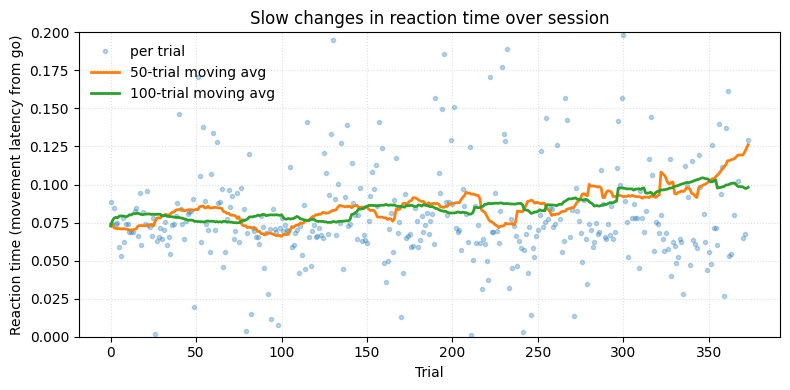

In [ ]:


# ---- 1. One movement per trial: take earliest movement in each trial ----
movs_simple = (
    movs
    .sort_values(["trial", "start_time"])
    .groupby("trial", as_index=False)
    .first()
    .sort_values("trial")
)

# ---- 2. Keep only trials with a defined movement latency ----
rt_col = "movement_latency_from_go"
movs_simple = movs_simple.dropna(subset=[rt_col])

# Optional: if you want to exclude clearly bad values, uncomment:
movs_simple = movs_simple[(movs_simple[rt_col] >= 0) & (movs_simple[rt_col] < 1.0)]

# x-axis = trial index (or you could use goCue_start_time_in_session)
x = movs_simple["trial"].to_numpy()
rt = movs_simple[rt_col].to_numpy()

# ---- 3. Define moving-average windows (in trials) ----
windows = [50, 100]  # adjust as you like

# ---- 4. Compute moving averages ----
ma_traces = {}
for w in windows:
    ma_traces[w] = (
        movs_simple[rt_col]
        .rolling(window=w, center=True, min_periods=1)
        .mean()
        .to_numpy()
    )

# ---- 5. Plot ----
fig, ax = plt.subplots(figsize=(8, 4))

# per-trial RT scatter
ax.plot(x, rt, ".", alpha=0.3, label="per trial")

# moving-average curves
for w, y_smooth in ma_traces.items():
    ax.plot(x, y_smooth, linewidth=2, label=f"{w}-trial moving avg")

ax.set_xlabel("Trial")
ax.set_ylabel("Reaction time (movement latency from go)")
ax.set_title("Slow changes in reaction time over session")
ax.legend(frameon=False)
ax.grid(True, linestyle=":", alpha=0.4)

plt.ylim(0,.2)

plt.tight_layout()
plt.show()


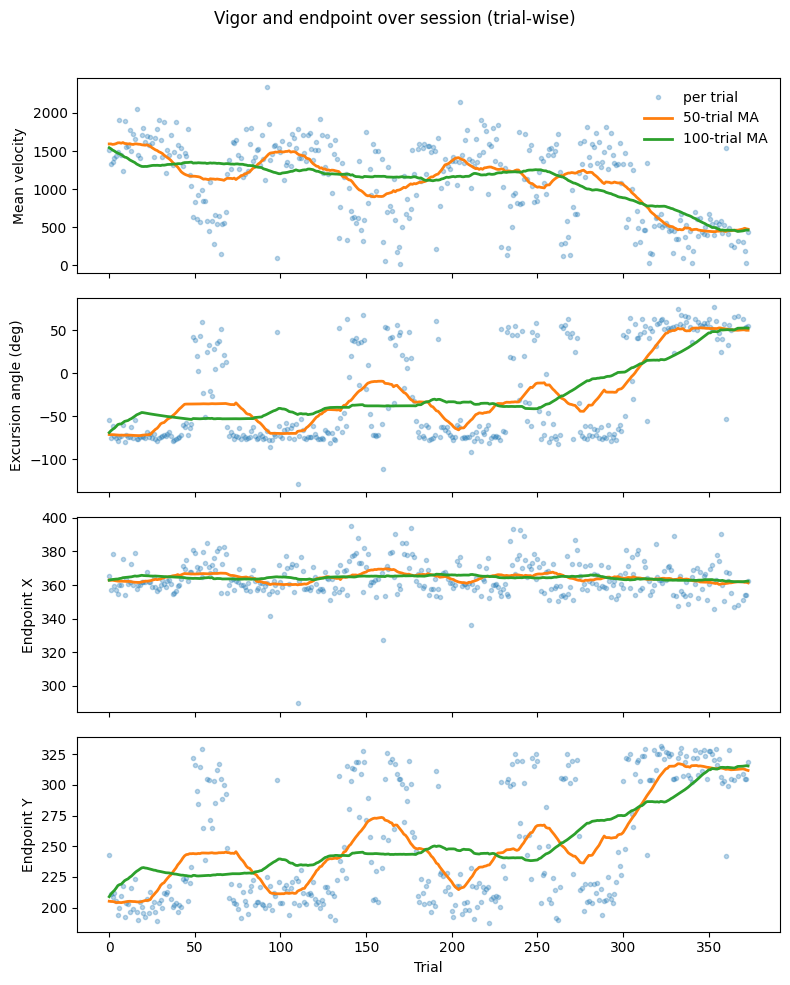

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- 1. One movement per trial (keep it dumb/simple) ----
# sort so the "first" movement in each trial is well-defined
movs_simple = (
    movs
    .sort_values(["trial", "start_time"])
    .groupby("trial", as_index=False)
    .first()
    .sort_values("trial")
)

# just to be safe, drop trials without these columns
cols = ["mean_velocity", "excursion_angle_deg", "endpoint_x", "endpoint_y"]
movs_simple = movs_simple.dropna(subset=cols)

# x-axis = trial index (or you can use movs_simple["start_time"])
x = movs_simple["trial"].to_numpy()

# ---- 2. Define windows for moving averages ----
windows = [50,100]   # in trials

# ---- 3. Make exploratory plots ----
fig, axes = plt.subplots(4, 1, figsize=(8, 10), sharex=True)

yvars = [
    ("mean_velocity",       "Mean velocity"),
    ("excursion_angle_deg", "Excursion angle (deg)"),
    ("endpoint_x",          "Endpoint X"),
    ("endpoint_y",          "Endpoint Y"),
]

for ax, (col, label) in zip(axes, yvars):
    y = movs_simple[col].to_numpy()

    # per-trial scatter
    ax.plot(x, y, ".", alpha=0.3, label="per trial")

    # moving averages with different windows
    for w in windows:
        y_smooth = (
            movs_simple[col]
            .rolling(window=w, center=True, min_periods=1)
            .mean()
            .to_numpy()
        )
        ax.plot(x, y_smooth, linewidth=2, label=f"{w}-trial MA")

    ax.set_ylabel(label)

# only put legend once (top axis)
axes[0].legend(frameon=False)
axes[-1].set_xlabel("Trial")

fig.suptitle("Vigor and endpoint over session (trial-wise)", y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


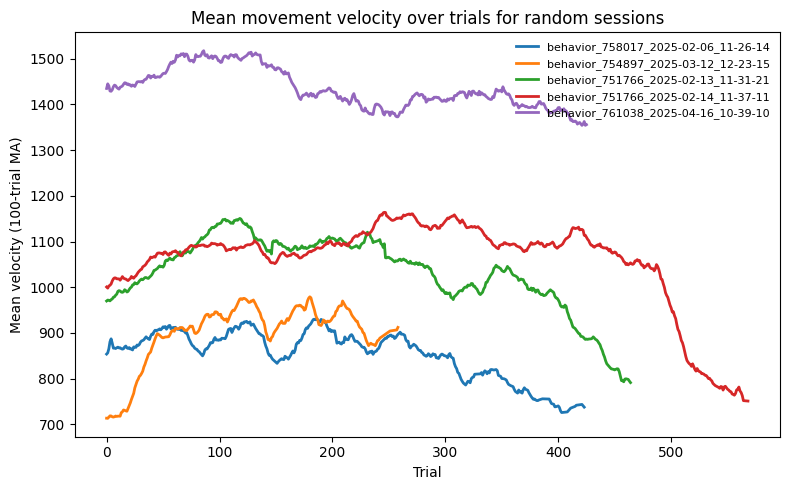

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# how many random sessions to plot
n_sessions = 5
rng = np.random.default_rng(0)

# pick random distinct sessions from units_with_spikes
all_sessions = units_with_spikes["session"].unique()
n_sessions = min(n_sessions, len(all_sessions))
chosen_sessions = rng.choice(all_sessions, size=n_sessions, replace=False)

fig, ax = plt.subplots(figsize=(8, 5))

for sess in chosen_sessions:
    # find a row index in units_with_spikes corresponding to this session
    idx_pos = np.flatnonzero(units_with_spikes["session"].values == sess)[0]

    example = load_example_session_and_unit(units_with_spikes, cfg, idx=idx_pos)
    movs = example["movs"]

    # ---- one movement per trial, dumb/simple ----
    movs_simple = (
        movs
        .sort_values(["trial", "start_time"])
        .groupby("trial", as_index=False)
        .first()
        .sort_values("trial")
    )

    # drop trials without mean_velocity
    if "mean_velocity" not in movs_simple.columns:
        continue
    movs_simple = movs_simple.dropna(subset=["mean_velocity"])

    if movs_simple.empty:
        continue

    x = movs_simple["trial"].to_numpy()
    y = movs_simple["mean_velocity"]

    # 100-trial moving average
    y_smooth = (
        y.rolling(window=100, center=True, min_periods=1)
         .mean()
         .to_numpy()
    )

    # make a shorter label (e.g., last part of session string)
    sess_label = str(sess).split("/")[-1]

    ax.plot(x, y_smooth, linewidth=2, label=sess_label)

ax.set_xlabel("Trial")
ax.set_ylabel("Mean velocity (100-trial MA)")
ax.set_title("Mean movement velocity over trials for random sessions")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()


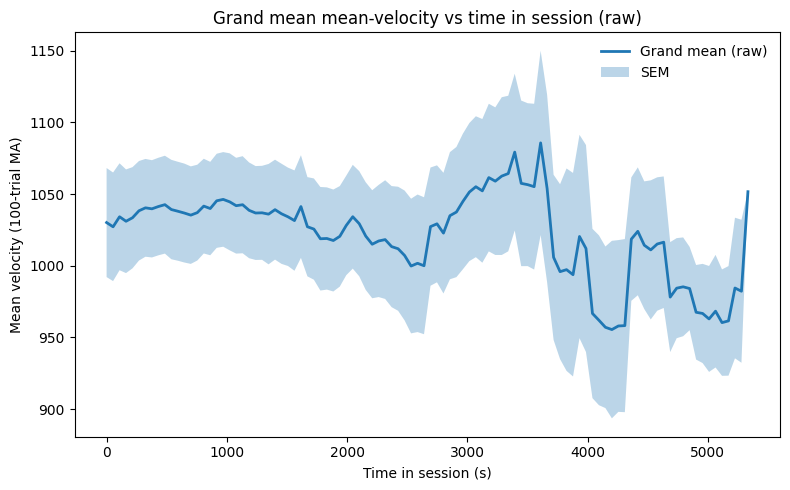

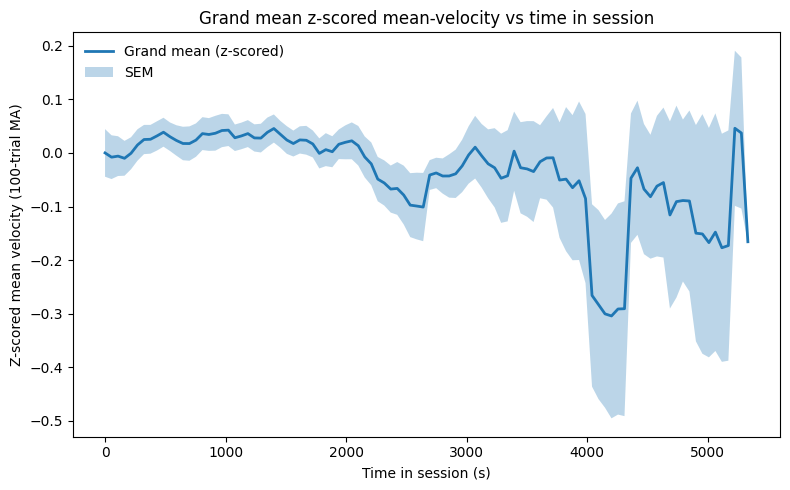

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

all_sessions = units_with_spikes["session"].unique()

# store per-session time + smoothed traces
time_list_raw = []
trace_list_raw = []

time_list_z = []
trace_list_z = []

durations = []

for sess in all_sessions:
    # pick one row (unit) from this session just to locate the session data
    idx_pos = np.flatnonzero(units_with_spikes["session"].values == sess)[0]
    example = load_example_session_and_unit(units_with_spikes, cfg, idx=idx_pos)
    movs = example["movs"]

    # ---- one movement per trial, simple ----
    movs_simple = (
        movs
        .sort_values(["trial", "start_time"])
        .groupby("trial", as_index=False)
        .first()
        .sort_values("trial")
    )

    if "mean_velocity" not in movs_simple.columns or "start_time" not in movs_simple.columns:
        continue

    movs_simple = movs_simple.dropna(subset=["mean_velocity", "start_time"])
    if movs_simple.empty:
        continue

    # time in session (seconds from first movement)
    t = movs_simple["start_time"].to_numpy()
    t = t - t.min()  # shift so first movement is 0

    # raw mean_velocity
    y = movs_simple["mean_velocity"].to_numpy()

    # 100-trial moving average (in trial index space)
    y_smooth = (
        pd.Series(y)
        .rolling(window=100, center=True, min_periods=1)
        .mean()
        .to_numpy()
    )

    # z-score within session
    y_mean = np.mean(y)
    y_std = np.std(y)
    if y_std == 0 or not np.isfinite(y_std):
        # can't zscore this session; skip z version
        z = None
        z_smooth = None
    else:
        z = (y - y_mean) / y_std
        z_smooth = (
            pd.Series(z)
            .rolling(window=100, center=True, min_periods=1)
            .mean()
            .to_numpy()
        )

    time_list_raw.append(t)
    trace_list_raw.append(y_smooth)

    if z_smooth is not None:
        time_list_z.append(t)
        trace_list_z.append(z_smooth)

    durations.append(t.max())

# ---- build common time grid ----
if not durations:
    raise RuntimeError("No valid sessions found for aggregation.")

max_T = max(durations)
n_bins = 100  # number of time bins across session duration
time_grid = np.linspace(0, max_T, n_bins)

# helper to interpolate and mask beyond each session duration
def interp_sessions_to_grid(time_list, trace_list):
    stacked = np.full((len(trace_list), n_bins), np.nan)
    for i, (t, y) in enumerate(zip(time_list, trace_list)):
        if len(t) < 2:
            continue

        # ensure sorted by time
        order = np.argsort(t)
        t_sorted = t[order]
        y_sorted = y[order]

        # interpolate onto common grid
        y_interp = np.interp(time_grid, t_sorted, y_sorted)

        # mask times beyond this session's duration
        valid_mask = time_grid <= t_sorted[-1]
        y_interp[~valid_mask] = np.nan

        stacked[i, :] = y_interp

    return stacked

stacked_raw = interp_sessions_to_grid(time_list_raw, trace_list_raw)
stacked_z   = interp_sessions_to_grid(time_list_z, trace_list_z)

# grand mean & SEM across sessions (raw)
grand_mean_raw = np.nanmean(stacked_raw, axis=0)
n_eff_raw = np.sum(~np.isnan(stacked_raw), axis=0)
grand_sem_raw = np.nanstd(stacked_raw, axis=0) / np.sqrt(np.maximum(n_eff_raw, 1))

# grand mean & SEM across sessions (z-scored)
grand_mean_z = np.nanmean(stacked_z, axis=0)
n_eff_z = np.sum(~np.isnan(stacked_z), axis=0)
grand_sem_z = np.nanstd(stacked_z, axis=0) / np.sqrt(np.maximum(n_eff_z, 1))

# ---- plot: raw mean_velocity ----
plt.figure(figsize=(8, 5))
plt.plot(time_grid, grand_mean_raw, linewidth=2, label="Grand mean (raw)")
plt.fill_between(
    time_grid,
    grand_mean_raw - grand_sem_raw,
    grand_mean_raw + grand_sem_raw,
    alpha=0.3,
    label="SEM"
)
plt.xlabel("Time in session (s)")
plt.ylabel("Mean velocity (100-trial MA)")
plt.title("Grand mean mean-velocity vs time in session (raw)")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# ---- plot: z-scored mean_velocity ----
plt.figure(figsize=(8, 5))
plt.plot(time_grid, grand_mean_z, linewidth=2, label="Grand mean (z-scored)")
plt.fill_between(
    time_grid,
    grand_mean_z - grand_sem_z,
    grand_mean_z + grand_sem_z,
    alpha=0.3,
    label="SEM"
)
plt.xlabel("Time in session (s)")
plt.ylabel("Z-scored mean velocity (100-trial MA)")
plt.title("Grand mean z-scored mean-velocity vs time in session")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


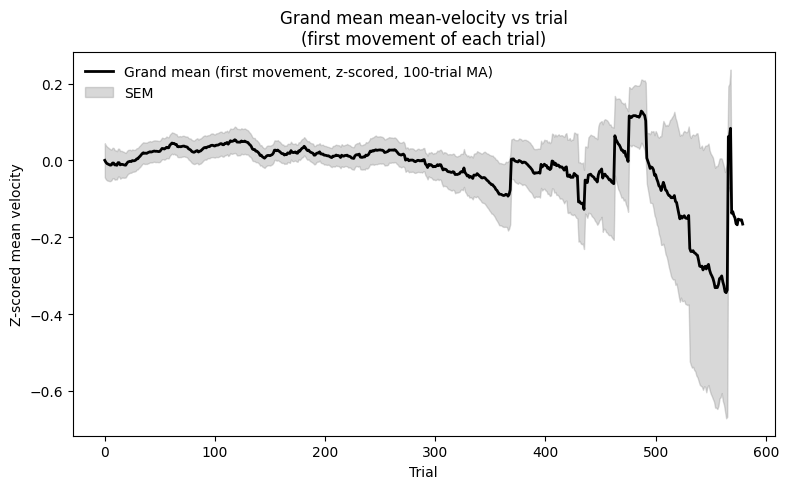

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# collect all per-session traces into a list
all_traces = []

all_sessions = units_with_spikes["session"].unique()

for sess in all_sessions:
    idx_pos = np.flatnonzero(units_with_spikes["session"].values == sess)[0]
    example = load_example_session_and_unit(units_with_spikes, cfg, idx=idx_pos)
    movs = example["movs"]

    # ---- first movement in each trial (by earliest start_time) ----
    movs_simple = (
        movs
        .sort_values(["trial", "start_time"])
        .groupby("trial", as_index=False)
        .first()
        .sort_values("trial")
    )

    if "mean_velocity" not in movs_simple.columns:
        continue

    movs_simple = movs_simple.dropna(subset=["mean_velocity"])
    if movs_simple.empty:
        continue

    y = movs_simple["mean_velocity"].to_numpy()

    # ---- z-score within session ----
    y_mean = np.nanmean(y)
    y_std  = np.nanstd(y)
    if not np.isfinite(y_std) or y_std == 0:
        continue

    y_z = (y - y_mean) / y_std

    # ---- 100-trial moving average on z-scored data ----
    y_smooth = (
        pd.Series(y_z)
        .rolling(window=100, center=True, min_periods=1)
        .mean()
        .to_numpy()
    )

    all_traces.append(y_smooth)

# ---- align sessions by padding with NaN to equal length ----
max_len = max(len(t) for t in all_traces)
stacked = np.full((len(all_traces), max_len), np.nan)

for i, t in enumerate(all_traces):
    stacked[i, :len(t)] = t

# ---- grand mean & SEM across sessions ----
grand_mean = np.nanmean(stacked, axis=0)
grand_sem  = np.nanstd(stacked, axis=0) / np.sqrt(np.sum(~np.isnan(stacked), axis=0))

# ---- plot ----
x = np.arange(max_len)  # trial index

plt.figure(figsize=(8, 5))
plt.plot(x, grand_mean, color='black', linewidth=2,
         label='Grand mean (first movement, z-scored, 100-trial MA)')
plt.fill_between(
    x,
    grand_mean - grand_sem,
    grand_mean + grand_sem,
    color='gray', alpha=0.3, label='SEM'
)

plt.xlabel("Trial")
plt.ylabel("Z-scored mean velocity")
plt.title("Grand mean mean-velocity vs trial\n(first movement of each trial)")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


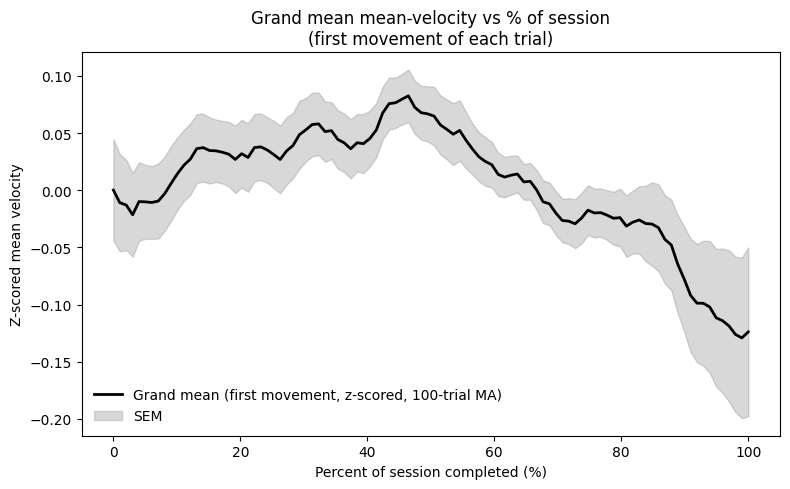

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# collect all per-session traces into a list
all_traces = []

all_sessions = units_with_spikes["session"].unique()

for sess in all_sessions:
    idx_pos = np.flatnonzero(units_with_spikes["session"].values == sess)[0]
    example = load_example_session_and_unit(units_with_spikes, cfg, idx=idx_pos)
    movs = example["movs"]

    # ---- first movement in each trial (by earliest start_time) ----
    movs_simple = (
        movs
        .sort_values(["trial", "start_time"])
        .groupby("trial", as_index=False)
        .first()
        .sort_values("trial")
    )
    
    if "mean_velocity" not in movs_simple.columns:
        continue

    movs_simple = movs_simple.dropna(subset=["mean_velocity"])
    if movs_simple.empty:
        continue

    y = movs_simple["mean_velocity"].to_numpy()

    # ---- z-score within session ----
    y_mean = np.nanmean(y)
    y_std  = np.nanstd(y)
    if not np.isfinite(y_std) or y_std == 0:
        continue

    y_z = (y - y_mean) / y_std

    # ---- 100-trial moving average on z-scored data ----
    y_smooth = (
        pd.Series(y_z)
        .rolling(window=100, center=True, min_periods=1)
        .mean()
        .to_numpy()
    )

    all_traces.append(y_smooth)

# -------------------------------------------------------------------
# Normalize x-axis: fraction of session completed (0 → 1)
# -------------------------------------------------------------------
if not all_traces:
    raise RuntimeError("No valid sessions after filtering.")

n_bins = 100  # common grid resolution for 0–1

x_grid = np.linspace(0.0, 1.0, n_bins)
stacked = np.full((len(all_traces), n_bins), np.nan)

for i, y_sess in enumerate(all_traces):
    n = len(y_sess)
    if n < 2:
        continue

    # session-specific normalized x (0 → 1)
    x_sess = np.linspace(0.0, 1.0, n)

    # interpolate session trace onto common grid
    y_interp = np.interp(x_grid, x_sess, y_sess)
    stacked[i, :] = y_interp

# grand mean & SEM across sessions
grand_mean = np.nanmean(stacked, axis=0)
n_eff = np.sum(~np.isnan(stacked), axis=0)
grand_sem = np.nanstd(stacked, axis=0) / np.sqrt(np.maximum(n_eff, 1))

# plot
plt.figure(figsize=(8, 5))
plt.plot(x_grid * 100.0, grand_mean, color='black', linewidth=2,
         label='Grand mean (first movement, z-scored, 100-trial MA)')
plt.fill_between(
    x_grid * 100.0,
    grand_mean - grand_sem,
    grand_mean + grand_sem,
    color='gray', alpha=0.3, label='SEM'
)

plt.xlabel("Percent of session completed (%)")
plt.ylabel("Z-scored mean velocity")
plt.title("Grand mean mean-velocity vs % of session\n(first movement of each trial)")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

modes = {
    "all": {
        "desc": "all movements",
        "label": "all movs, z-scored, 100-movement MA",
    },
    "first": {
        "desc": "first movement per trial",
        "label": "first movs, z-scored, 100-trial MA",
    },
}

results = {}

all_sessions = units_with_spikes["session"].unique()

for mode, info in modes.items():
    all_traces = []

    for sess in all_sessions:
        idx_pos = np.flatnonzero(units_with_spikes["session"].values == sess)[0]
        example = load_example_session_and_unit(units_with_spikes, cfg, idx=idx_pos)
        movs = example["movs"]

        # keep only movements assigned to a trial
        if "trial" in movs.columns:
            movs = movs[movs["trial"].notna()]

        # --- choose movements depending on mode ---
        if mode == "all":
            movs_simple = movs.sort_values(["trial", "start_time"])
        elif mode == "first":
            movs_simple = (
                movs
                .sort_values(["trial", "start_time"])
                .groupby("trial", as_index=False)
                .first()
                .sort_values("trial")
            )
        else:
            continue

        if "mean_velocity" not in movs_simple.columns:
            continue

        movs_simple = movs_simple.dropna(subset=["mean_velocity"])
        if movs_simple.empty:
            continue

        y = movs_simple["mean_velocity"].to_numpy()

        # ---- z-score within session ----
        y_mean = np.nanmean(y)
        y_std  = np.nanstd(y)
        if not np.isfinite(y_std) or y_std == 0:
            continue

        y_z = (y - y_mean) / y_std

        # ---- 100-point moving average on z-scored data ----
        # (100 movements for "all", 100 trials for "first")
        y_smooth = (
            pd.Series(y_z)
            .rolling(window=100, center=True, min_periods=1)
            .mean()
            .to_numpy()
        )

        all_traces.append(y_smooth)

    # -------------------------------------------------------------------
    # Normalize x-axis: fraction of session completed (0 → 1)
    # -------------------------------------------------------------------
    if not all_traces:
        raise RuntimeError(f"No valid sessions after filtering for mode={mode!r}.")

    n_bins = 100  # common grid resolution for 0–1

    x_grid = np.linspace(0.0, 1.0, n_bins)
    stacked = np.full((len(all_traces), n_bins), np.nan)

    for i, y_sess in enumerate(all_traces):
        n = len(y_sess)
        if n < 2:
            continue

        # session-specific normalized x (0 → 1)
        x_sess = np.linspace(0.0, 1.0, n)

        # interpolate session trace onto common grid
        y_interp = np.interp(x_grid, x_sess, y_sess)
        stacked[i, :] = y_interp

    # grand mean & SEM across sessions
    grand_mean = np.nanmean(stacked, axis=0)
    n_eff = np.sum(~np.isnan(stacked), axis=0)
    grand_sem = np.nanstd(stacked, axis=0) / np.sqrt(np.maximum(n_eff, 1))

    results[mode] = {
        "x_grid": x_grid,
        "grand_mean": grand_mean,
        "grand_sem": grand_sem,
    }

# -------------------------------------------------------------------
# Plot both on separate subplots
# -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, (mode, info) in zip(axes, modes.items()):
    x_grid = results[mode]["x_grid"]
    grand_mean = results[mode]["grand_mean"]
    grand_sem = results[mode]["grand_sem"]

    ax.plot(x_grid * 100.0, grand_mean, color='black', linewidth=2,
            label=f"Grand mean ({info['label']})")
    ax.fill_between(
        x_grid * 100.0,
        grand_mean - grand_sem,
        grand_mean + grand_sem,
        color='gray', alpha=0.3, label='SEM'
    )

    ax.set_xlabel("Percent of session completed (%)")
    ax.set_title(info["desc"])
    ax.legend(frameon=False, fontsize=8)

axes[0].set_ylabel("Z-scored mean velocity")
fig.suptitle("Grand mean z-scored mean-velocity vs % of session\n(all movements vs first movement per trial)")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


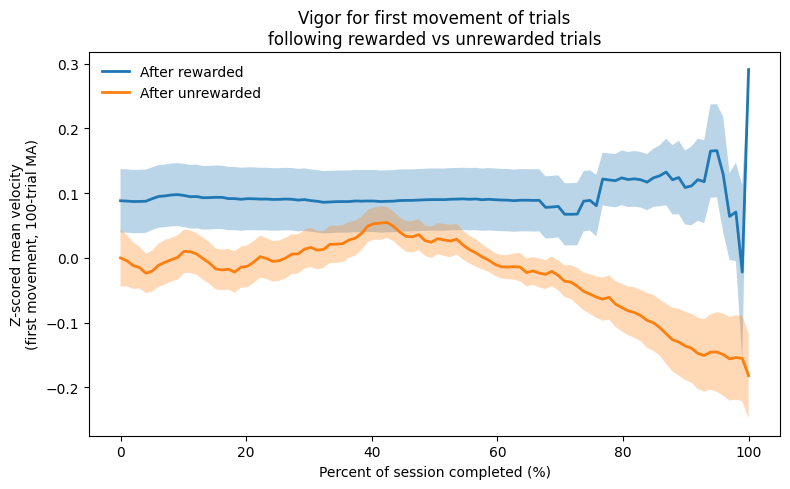

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

all_sessions = units_with_spikes["session"].unique()

time_rew = []
trace_rew = []

time_unrew = []
trace_unrew = []

for sess in all_sessions:
    idx_pos = np.flatnonzero(units_with_spikes["session"].values == sess)[0]
    example = load_example_session_and_unit(units_with_spikes, cfg, idx=idx_pos)
    movs = example["movs"]

    # keep only movements with a valid trial id
    if "trial" not in movs.columns:
        continue
    movs = movs[movs["trial"].notna()]

    # --- first movement per trial (earliest start_time) ---
    movs_first = (
        movs
        .sort_values(["trial", "start_time"])
        .groupby("trial", as_index=False)
        .first()
        .sort_values("trial")
    )

    if "mean_velocity" not in movs_first.columns or "rewarded" not in movs_first.columns:
        continue

    movs_first = movs_first.dropna(subset=["mean_velocity", "start_time", "rewarded"])
    if movs_first.empty:
        continue

    # --- label trials by whether the PREVIOUS trial was rewarded ---
    movs_first = movs_first.sort_values("trial")
    movs_first["prev_rewarded"] = movs_first["rewarded"].shift(1)

    # drop the very first trial (no previous trial info)
    movs_first = movs_first.dropna(subset=["prev_rewarded"])
    if movs_first.empty:
        continue

    # session-level z-score params (based on ALL first movements in this session)
    session_mean = movs_first["mean_velocity"].mean()
    session_std  = movs_first["mean_velocity"].std()
    if not np.isfinite(session_std) or session_std == 0:
        continue

    # we also want session time bounds for normalization
    t0 = movs_first["start_time"].min()
    t1 = movs_first["start_time"].max()
    if not np.isfinite(t0) or not np.isfinite(t1) or t1 <= t0:
        continue
    denom = t1 - t0

    # --- split into trials following rewarded vs unrewarded ---
    for cond_label, cond_mask, t_list, y_list in [
        ("follow_rew",
         movs_first["prev_rewarded"] == True,
         time_rew,
         trace_rew),
        ("follow_unrew",
         movs_first["prev_rewarded"] == False,
         time_unrew,
         trace_unrew),
    ]:
        sub = movs_first[cond_mask]
        if sub.empty:
            continue

        # time in session (normalized 0–1 using overall session bounds)
        t = (sub["start_time"].to_numpy() - t0) / denom

        # z-score using session-level mean/std
        y = sub["mean_velocity"].to_numpy()
        y_z = (y - session_mean) / session_std

        # 100-trial moving average within this condition for this session
        y_smooth = (
            pd.Series(y_z)
            .rolling(window=100, center=True, min_periods=1)
            .mean()
            .to_numpy()
        )

        # store
        t_list.append(t)
        y_list.append(y_smooth)

# -------------------------------------------------------------------
# Interpolate both conditions onto a common 0–1 time grid
# -------------------------------------------------------------------
def interp_to_grid(time_list, trace_list, n_bins=100):
    x_grid = np.linspace(0.0, 1.0, n_bins)
    stacked = np.full((len(trace_list), n_bins), np.nan)

    for i, (t, y) in enumerate(zip(time_list, trace_list)):
        if len(t) < 2:
            continue

        # sort by time
        order = np.argsort(t)
        t_sorted = t[order]
        y_sorted = y[order]

        # interpolate onto grid
        y_interp = np.interp(x_grid, t_sorted, y_sorted)

        # mask times beyond last observed time for that session/condition
        valid_mask = x_grid <= t_sorted[-1]
        y_interp[~valid_mask] = np.nan

        stacked[i, :] = y_interp

    # grand mean & SEM
    grand_mean = np.nanmean(stacked, axis=0)
    n_eff = np.sum(~np.isnan(stacked), axis=0)
    grand_sem = np.nanstd(stacked, axis=0) / np.sqrt(np.maximum(n_eff, 1))

    return x_grid, grand_mean, grand_sem

if not time_rew or not time_unrew:
    raise RuntimeError("Not enough data for one or both conditions (follow_rew / follow_unrew).")

x_grid, mean_rew, sem_rew   = interp_to_grid(time_rew,   trace_rew)
_,      mean_unrew, sem_unrew = interp_to_grid(time_unrew, trace_unrew)

# -------------------------------------------------------------------
# Plot both conditions on the same axis
# -------------------------------------------------------------------
plt.figure(figsize=(8, 5))

x_percent = x_grid * 100.0

plt.plot(x_percent, mean_rew,   linewidth=2, label="After rewarded")
plt.fill_between(x_percent, mean_rew - sem_rew, mean_rew + sem_rew, alpha=0.3)

plt.plot(x_percent, mean_unrew, linewidth=2, label="After unrewarded")
plt.fill_between(x_percent, mean_unrew - sem_unrew, mean_unrew + sem_unrew, alpha=0.3)

plt.xlabel("Percent of session completed (%)")
plt.ylabel("Z-scored mean velocity\n(first movement, 100-trial MA)")
plt.title("Vigor for first movement of trials\nfollowing rewarded vs unrewarded trials")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


In [ ]:
# #figure comparing cue-response lick reaction time to tongue movement reaction time

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from scipy.stats import spearmanr, wilcoxon

# # -----------------------------
# # Settings (match your build of all_counts_df)
# # -----------------------------
# ALIGN_KEY   = "goCue"
# COUNT_WIN   = cfg.count_window_s
# MIN_TRIALS_PER_UNIT = 3
# ONLY_CR_TRIALS = False   # set True to keep only trials with cue_response_movement_number notna()
# ALPHA = 0.05

# # -----------------------------
# # Prep data
# # -----------------------------
# df = all_counts_df.copy()
# mask = (
#     (df["align_key"] == ALIGN_KEY) &
#     (np.isclose(df["win_start_s"], COUNT_WIN[0])) &
#     (np.isclose(df["win_stop_s"], COUNT_WIN[1]))
# )
# df = df.loc[mask].copy()
# if ONLY_CR_TRIALS:
#     df = df.loc[df["cue_response_movement_number"].notna()].copy()

# # -----------------------------
# # Helper: per-unit Spearman for a given RT col
# # -----------------------------
# def per_unit_spearman(df_in: pd.DataFrame, rt_col: str) -> pd.DataFrame:
#     rows = []
#     for (uid, sess), g in df_in.dropna(subset=[rt_col, "spike_count"]).groupby(["unit_id","session"]):
#         if len(g) < MIN_TRIALS_PER_UNIT:
#             rows.append({"unit_id": uid, "session": sess, "n_trials": len(g), "rho": np.nan, "p": np.nan})
#             continue
#         rho, p = spearmanr(g[rt_col].to_numpy(), g["spike_count"].to_numpy(), nan_policy="omit")
#         rows.append({"unit_id": uid, "session": sess, "n_trials": len(g), "rho": float(rho), "p": float(p)})
#     return pd.DataFrame(rows)

# # Compute correlations for both RT definitions
# cor_first = per_unit_spearman(df, "reaction_time_firstmove").rename(columns={"rho":"rho_first","p":"p_first"})
# cor_cr    = per_unit_spearman(df, "reaction_time_cueresponse").rename(columns={"rho":"rho_cr","p":"p_cr"})

# # Keep only paired units (have both)
# m = (cor_first.merge(cor_cr, on=["unit_id","session","n_trials"], how="inner")
#               .dropna(subset=["rho_first","rho_cr"])
#               .reset_index(drop=True))
# if m.empty:
#     raise ValueError("No units with valid correlations for both RT definitions.")

# # Significance categories
# sig_first = m["p_first"] < ALPHA
# sig_cr    = m["p_cr"]    < ALPHA
# m["sig_cat"] = np.select(
#     [ sig_first &  sig_cr,  sig_first & ~sig_cr, ~sig_first &  sig_cr],
#     [ "both sig",           "first-only sig",    "cue-only sig"        ],
#     default="not sig"
# )

# # For panel 2
# m["is_sig_first"] = sig_first
# m["is_sig_cr"]    = sig_cr

# # Common limits for rho axes
# vals = np.concatenate([m["rho_first"].to_numpy(), m["rho_cr"].to_numpy()])
# rho_min, rho_max = (np.nanmin(vals), np.nanmax(vals)) if np.isfinite(vals).all() else (-1.0, 1.0)
# pad = 0.05 * (rho_max - rho_min if rho_max > rho_min else 1.0)
# rho_lo, rho_hi = rho_min - pad, rho_max + pad
# bins = np.linspace(min(rho_lo, -1), max(rho_hi, 1), 21)

# # Colors
# color_cat = {
#     "both sig": "C3",          # orange/red
#     "first-only sig": "C1",    # amber
#     "cue-only sig": "C2",      # green
#     "not sig": "C0",           # blue
# }
# color_rt = {"first": "C0", "cue": "C3"}  # panel 3 identity colors
# color_sig = {"sig": "C3", "nonsig": "C0"}  # panel 2 significance colors

# # -----------------------------
# # Figure layout with nested grids
# # -----------------------------
# fig = plt.figure(figsize=(15, 5.2))
# gs = fig.add_gridspec(nrows=2, ncols=3, width_ratios=[1.25, 1.25, 1.5], wspace=0.35, hspace=0.35)

# # Panel 1: scatter with flipped axes + significance categories
# ax1 = fig.add_subplot(gs[:, 0])
# for k, g in m.groupby("sig_cat"):
#     ax1.scatter(g["rho_first"], g["rho_cr"], s=30, alpha=0.9,
#                 edgecolor="black", linewidth=0.4, c=color_cat[k], label=f"{k} (n={len(g)})")
# ax1.plot([rho_lo, rho_hi], [rho_lo, rho_hi], linestyle="--", linewidth=1, color="gray")

# # flip both axes so "more negative" is visually "more" (upper-right)
# ax1.set_xlim(rho_hi, rho_lo)
# ax1.set_ylim(rho_hi, rho_lo)

# ax1.set_xlabel("Spearman ρ (first-move RT)")
# ax1.set_ylabel("Spearman ρ (cue-response RT)")
# ax1.set_title("RT - spike count correlation:\nfirst-move vs cue-response")
# ax1.grid(True, linestyle=":", alpha=0.5)
# ax1.legend(frameon=False, fontsize=8, loc="best")

# # Panel 2: two stacked histograms (first-move on top, cue-response bottom), colored by significance
# ax2a = fig.add_subplot(gs[0, 1])  # first-move
# rho_first_sig    = m.loc[m["is_sig_first"], "rho_first"].to_numpy()
# rho_first_nonsig = m.loc[~m["is_sig_first"], "rho_first"].to_numpy()
# ax2a.hist(rho_first_nonsig, bins=bins, alpha=0.7, label="not sig", color=color_sig["nonsig"])
# ax2a.hist(rho_first_sig,    bins=bins, alpha=0.7, label="sig",     color=color_sig["sig"])
# ax2a.axvline(0, linestyle="--", linewidth=1, color="gray")
# ax2a.set_xlim(bins[0], bins[-1])
# ax2a.set_title("First-move RT: ρ distribution")
# ax2a.set_ylabel("Unit count")
# ax2a.grid(True, axis="y", linestyle=":", alpha=0.5)
# ax2a.legend(frameon=False, fontsize=8)

# ax2b = fig.add_subplot(gs[1, 1])  # cue-response
# rho_cr_sig    = m.loc[m["is_sig_cr"], "rho_cr"].to_numpy()
# rho_cr_nonsig = m.loc[~m["is_sig_cr"], "rho_cr"].to_numpy()
# ax2b.hist(rho_cr_nonsig, bins=bins, alpha=0.7, label="not sig", color=color_sig["nonsig"])
# ax2b.hist(rho_cr_sig,    bins=bins, alpha=0.7, label="sig",     color=color_sig["sig"])
# ax2b.axvline(0, linestyle="--", linewidth=1, color="gray")
# ax2b.set_xlim(bins[0], bins[-1])
# ax2b.set_title("Cue-response RT: ρ distribution")
# ax2b.set_xlabel("Spearman ρ")
# ax2b.set_ylabel("Unit count")
# ax2b.grid(True, axis="y", linestyle=":", alpha=0.5)
# ax2b.legend(frameon=False, fontsize=8)

# # Panel 3: lollipop per unit (two RTs per unit), sorted by cue-response ρ
# # Panel 3: lollipop per unit with significance highlighting
# ax3 = fig.add_subplot(gs[:, 2])

# # sort by cue-response rho so more negative at top (we'll keep normal y order)
# order = np.argsort(m["rho_first"].to_numpy())
# m_sorted = m.iloc[order].reset_index(drop=True)
# y = np.arange(len(m_sorted))

# offset = 0.18
# for i, row in m_sorted.iterrows():
#     # faint band if any significance for this unit
#     if bool(row["is_sig_first"]) or bool(row["is_sig_cr"]):
#         ax3.axhspan(i-0.42, i+0.42, color="k", alpha=0.05, zorder=0)

#     # ---- first-move RT ----
#     rf   = row["rho_first"]
#     sig1 = bool(row["is_sig_first"])
#     lw1  = 2.2 if sig1 else 1.0
#     mfc1 = color_rt["first"] if sig1 else "none"  # filled if sig, open if not
#     ax3.hlines(y=i - offset, xmin=0, xmax=rf, color=color_rt["first"], alpha=0.9, linewidth=lw1)
#     ax3.plot(rf, i - offset, marker="o", markersize=5, mfc=mfc1, mec="black", mew=0.4,
#              color=color_rt["first"])

#     # ---- cue-response RT ----
#     rc   = row["rho_cr"]
#     sig2 = bool(row["is_sig_cr"])
#     lw2  = 2.2 if sig2 else 1.0
#     mfc2 = color_rt["cue"] if sig2 else "none"
#     ax3.hlines(y=i + offset, xmin=0, xmax=rc, color=color_rt["cue"], alpha=0.9, linewidth=lw2)
#     ax3.plot(rc, i + offset, marker="o", markersize=5, mfc=mfc2, mec="black", mew=0.4,
#              color=color_rt["cue"])

# ax3.axvline(0, linestyle="--", linewidth=1, color="gray")
# ax3.set_xlim(bins[0], bins[-1])
# ax3.set_ylim(-1, len(y))
# ax3.set_yticks([])
# ax3.set_xlabel("Spearman ρ")
# ax3.set_title("RT - spike count correlation per unit")
# ax3.grid(True, axis="x", linestyle=":", alpha=0.5)

# # Legends: RT identity + significance style
# from matplotlib.lines import Line2D
# leg_rt = [
#     Line2D([0], [0], color=color_rt["first"], lw=3, label="first-move RT"),
#     Line2D([0], [0], color=color_rt["cue"],   lw=3, label="cue-response RT"),
# ]
# leg_sig = [
#     Line2D([0], [0], marker="o", linestyle="None", mfc="k", mec="black", mew=0.4,
#            label=f"significant (p < {ALPHA})"),
#     Line2D([0], [0], marker="o", linestyle="None", mfc="none", mec="black", mew=0.4,
#            label="not significant"),
# ]
# first_legend = ax3.legend(handles=leg_rt, frameon=False, loc="lower right", fontsize=8)
# ax3.add_artist(first_legend)
# ax3.legend(handles=leg_sig, frameon=False, loc="upper right", fontsize=8)


# plt.tight_layout()
# plt.show()

# # if SAVE_FIG:
# #     fname = FIG_DIR / "RT_spikecount_correlation_comparison_firstmove_vs_cueresponse"
# #     FIG_DIR.mkdir(parents=True, exist_ok=True)
# #     fig.savefig(f"{fname}.png", dpi=300, bbox_inches="tight")
# #     fig.savefig(f"{fname}.svg", bbox_inches="tight")

# # # Optional quick paired test on rho_cr vs rho_first
# # valid = m_sorted.dropna(subset=["rho_first","rho_cr"])
# # if len(valid) >= 3:
# #     W, pW = wilcoxon(valid["rho_cr"].to_numpy(), valid["rho_first"].to_numpy(), zero_method="wilcox")
# #     print(f"Wilcoxon on ρ (cue vs first): W={W:.1f}, p={pW:.3g}, mean Δρ={(valid['rho_cr']-valid['rho_first']).mean():.3f}")


## Raster visualization

Raster plots aligned to go-cue and first lick, grouped by cue-response movement number.

abs_rho_a vs coverage_pct: Spearman ρ=-0.217 | p=0.028 | n=103
abs_rho_b vs coverage_pct: Spearman ρ=-0.123 | p=0.217 | n=103
abs_rho_a vs duration_p50: Spearman ρ=-0.046 | p=0.643 | n=103
abs_rho_b vs duration_p50: Spearman ρ=0.237 | p=0.0159 | n=103


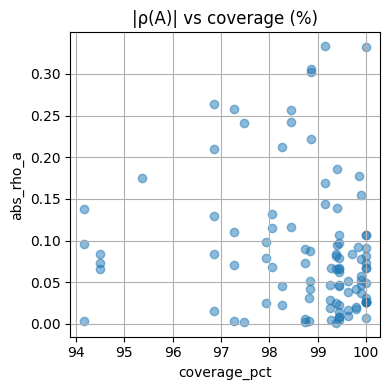

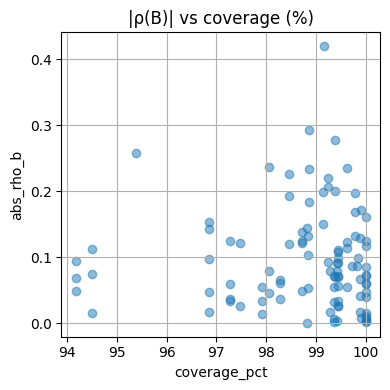

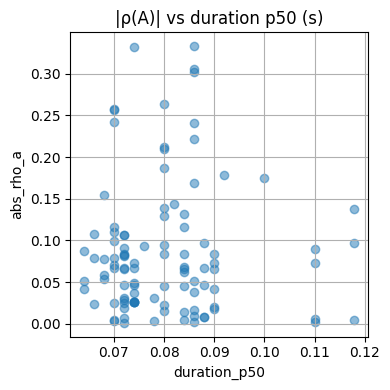

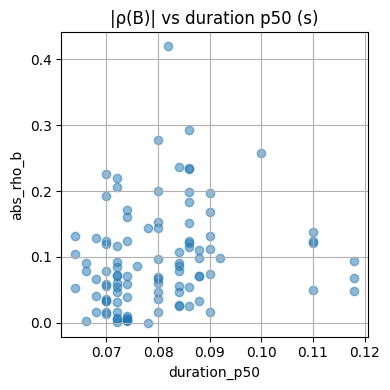

In [ ]:


# --- Helpers ---


def add_session_prefix_col(df: pd.DataFrame, col: str, new_col: str = 'session_prefix') -> pd.DataFrame:
    out = df.copy()
    out[new_col] = out[col].astype(str).apply(get_session_prefix)
    return out

# ---- Inputs ----
# merged: per-unit table with columns ['unit_id','session','rho_a','p_a','q_a','rho_b','p_b','q_b','sig_category']
# filtered_df: per-session table with 'session_id', and session metrics ['coverage_pct','duration_p50']

# --- 0) Normalize keys ---
units = add_session_prefix_col(merged, 'session', 'session_prefix')

sess = add_session_prefix_col(filtered_df, 'session_id', 'session_prefix')

# Aggregate to one row per session_prefix
sess_counts = sess.groupby('session_prefix', as_index=False).size().rename(columns={'size': 'n_rows_from_filtered'})
sess_agg = (
    sess
    .groupby('session_prefix', as_index=False)
    .agg({
        'coverage_pct': 'mean',
        'duration_p50': 'mean',
    })
    .merge(sess_counts, on='session_prefix', how='left')
)

# --- 1) Merge session-level metrics onto per-unit table ---
df_units = units.merge(sess_agg, on='session_prefix', how='left')

# --- 2) Compute absolute rho values from new columns ---
df_units['abs_rho_a'] = df_units['rho_a'].abs()
df_units['abs_rho_b'] = df_units['rho_b'].abs()

# --- 3) Correlate per-unit |rho| with session-level quality metrics ---
def safe_spearman(x: pd.Series, y: pd.Series):
    valid = pd.DataFrame({'x': x, 'y': y}).dropna()
    n = len(valid)
    if n < 2:
        return np.nan, np.nan, n
    rho, pval = spearmanr(valid['x'], valid['y'])
    return rho, pval, n

for metric in ['coverage_pct', 'duration_p50']:
    for rho_col in ['abs_rho_a', 'abs_rho_b']:
        rho, pval, n = safe_spearman(df_units[metric], df_units[rho_col])
        print(f"{rho_col} vs {metric}: Spearman ρ={rho:.3f} | p={pval:.3g} | n={n}")

# --- 4) Quick scatter plots ---
def plot_scatter(df, x, y, title):
    d = df[[x, y]].dropna()
    if len(d) == 0:
        print(f"[plot] No data for {title}")
        return
    plt.figure(figsize=(4, 4))
    plt.scatter(d[x], d[y], alpha=0.5)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_scatter(df_units, 'coverage_pct', 'abs_rho_a', '|ρ(A)| vs coverage (%)')
plot_scatter(df_units, 'coverage_pct', 'abs_rho_b', '|ρ(B)| vs coverage (%)')
plot_scatter(df_units, 'duration_p50', 'abs_rho_a', '|ρ(A)| vs duration p50 (s)')
plot_scatter(df_units, 'duration_p50', 'abs_rho_b', '|ρ(B)| vs duration p50 (s)')


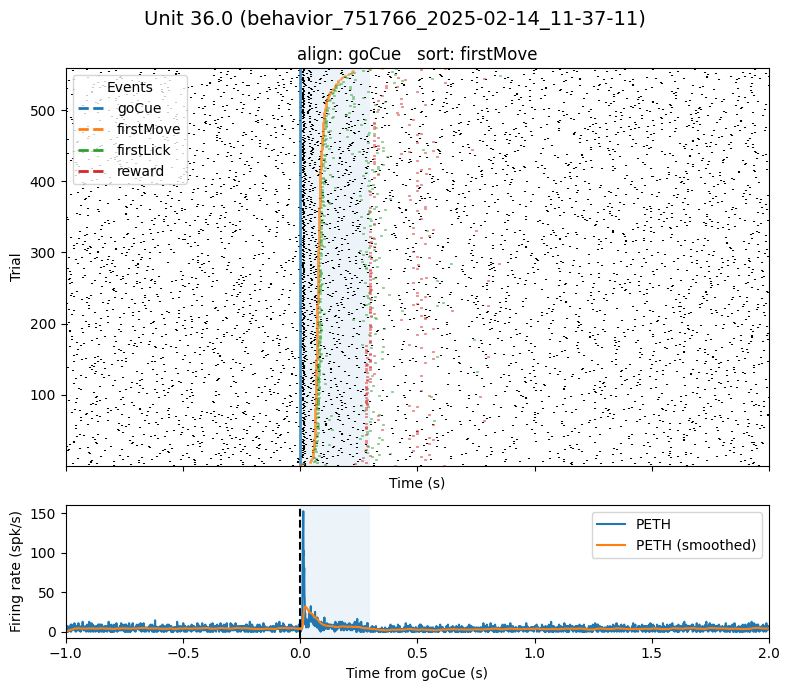

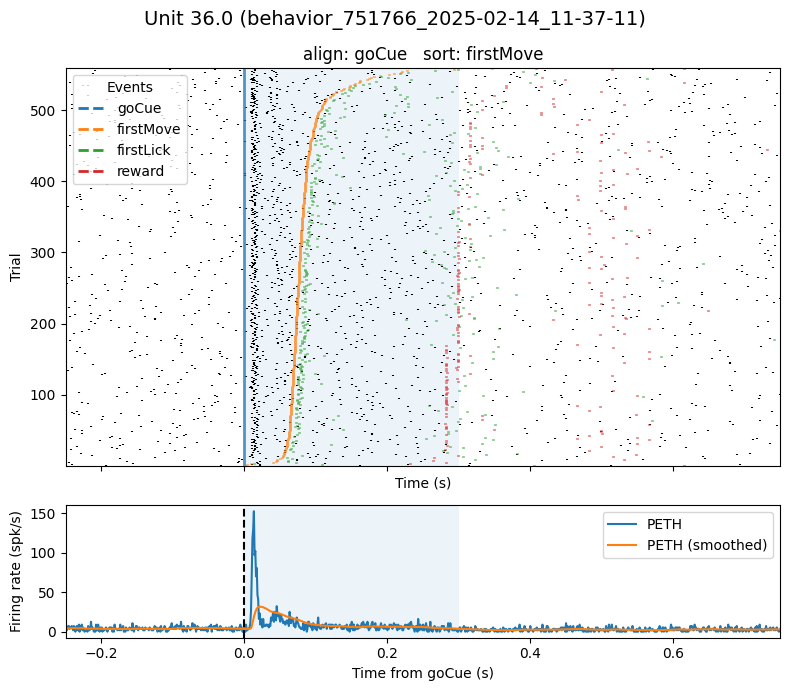

In [ ]:
from aind_dynamic_foraging_behavior_video_analysis.ephys.tongue_ephys import make_rp_and_events, compute_psth, smooth_vector, plot_psth

session_str  = example["session"]
unit_num  = example["unit_id"]


row = units_with_spikes.query("session == @session_str and unit_id == @unit_num").iloc[0]
session = row["session"]
spikes_abs = np.array(row["spike_times"], dtype=float)  # from NWB

# 1) Get the session bundle (already made with cfg)
bundle = bundle_cache[session]
Ev          = bundle["Ev"]                 # DataFrame of event times per trial
align_times = bundle["align_times"]        # Series: trial -> t0 (absolute, s)
offset      = bundle["session_offset"]     # to convert absolute → session time

# 2) Convert spikes to session time (skip if yours are already in session time)
spikes = spikes_abs - offset

# 3) Turn Ev into dicts that the wrapper expects
event_dicts = {col: Ev[col].dropna().to_dict() for col in Ev.columns}
trials = Ev.index.tolist()

# 4) Build the plotter (choose align & sort; align from cfg is convenient)
align_by = cfg.align_key      # e.g., "goCue"
sort_by  = "firstMove"        # or "firstLick", "reward", etc.

rp, events = make_rp_and_events(
    spikes=spikes,
    trials=trials,
    event_dicts=event_dicts,
    events_to_plot=['goCue','firstMove','firstLick','reward'],
    align_by=align_by,
    sort_by=sort_by,
    pre=1.0,
    post=2.0,
    bin_size=0.001,
)

# 5) Plot (raster + PSTH)
fig, (ax_raster, ax_psth) = plt.subplots(
    2, 1, figsize=(8, 7), sharex=True, gridspec_kw={'height_ratios':[3,1]}
)
rp.plot_raster(ax=ax_raster, spike_color='black')
rp.add_events(ax_raster, events)
ax_raster.set_title(f'align: {align_by}   sort: {sort_by}')
ax_raster.legend(loc='upper left', title='Events')

# optional: shade your analysis window from cfg
a, b = cfg.count_window_s
ax_raster.axvspan(a, b, alpha=0.08, linewidth=0)

psth, _  = compute_psth(rp.raster, bin_size=rp.bin_size)
psth_sm  = smooth_vector(psth, bin_size=rp.bin_size, sigma=0.025)
plot_psth(rp.bins, psth, psth_sm, ax=ax_psth, label='PETH')
ax_psth.axvspan(a, b, alpha=0.08, linewidth=0)
ax_psth.set_xlabel(f'Time from {align_by} (s)')

plt.suptitle(f'Unit {row["unit_id"]} ({session})', fontsize=14)

plt.tight_layout()
plt.show()
if SAVE_FIG:
    fname = FIG_DIR / "example_raster_alignGo_sortMove"
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(f"{fname}.png", dpi=300, bbox_inches="tight")
    fig.savefig(f"{fname}.svg", bbox_inches="tight")


# === SECOND FIGURE WITH X-LIMIT ===
fig2, (ax_raster2, ax_psth2) = plt.subplots(
    2, 1, figsize=(8, 7), sharex=True, gridspec_kw={'height_ratios':[3,1]}
)

rp.plot_raster(ax=ax_raster2, spike_color='black')
rp.add_events(ax_raster2, events)
ax_raster2.set_title(f'align: {align_by}   sort: {sort_by}')
ax_raster2.legend(loc='upper left', title='Events')

# optional shade window
ax_raster2.axvspan(a, b, alpha=0.08, linewidth=0)

# psth
plot_psth(rp.bins, psth, psth_sm, ax=ax_psth2, label='PETH')
ax_psth2.axvspan(a, b, alpha=0.08, linewidth=0)
ax_psth2.set_xlabel(f'Time from {align_by} (s)')

# ---- here’s the custom limit ----
ax_psth2.set_xlim(-0.25, .75)

plt.suptitle(f'Unit {row["unit_id"]} ({session})', fontsize=14)
plt.tight_layout()
plt.show()

if SAVE_FIG:
    fname = FIG_DIR / "example_raster_alignGo_sortMove_zoom"
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig2.savefig(f"{fname}.png", dpi=300, bbox_inches="tight")
    fig2.savefig(f"{fname}.svg", bbox_inches="tight")

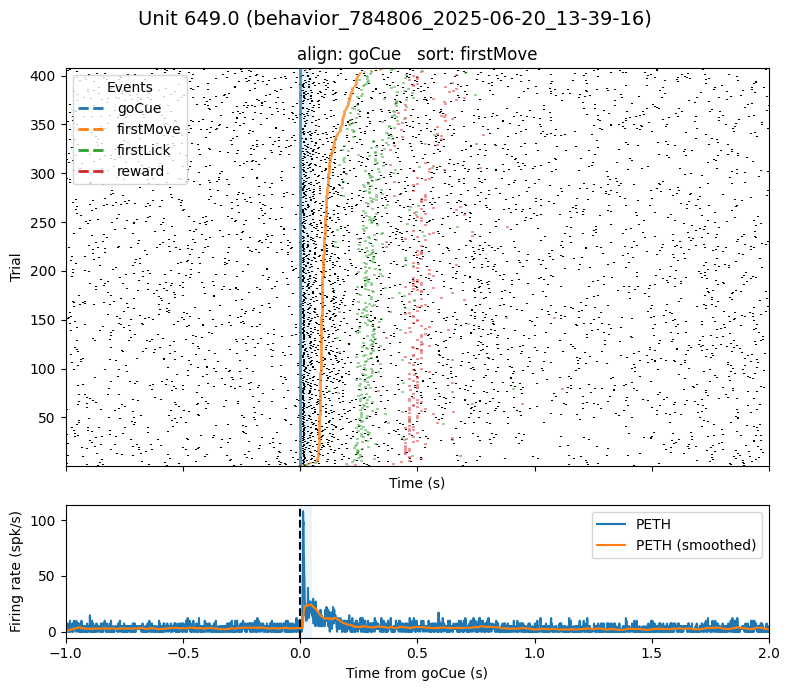

In [ ]:
from aind_dynamic_foraging_behavior_video_analysis.ephys.tongue_ephys import make_rp_and_events, compute_psth, smooth_vector, plot_psth

# Pick one unit (example)
# row = units_with_spikes.iloc[10]          # or pick by session/unit_id
unit_num = 649
session_str = "behavior_784806_2025-06-20_13-39-16"
row = units_with_spikes.query("session == @session_str and unit_id == @unit_num").iloc[0]
session = row["session"]
spikes_abs = np.array(row["spike_times"], dtype=float)  # from NWB

# 1) Get the session bundle (already made with cfg)
bundle = bundle_cache[session]
Ev          = bundle["Ev"]                 # DataFrame of event times per trial
align_times = bundle["align_times"]        # Series: trial -> t0 (absolute, s)
offset      = bundle["session_offset"]     # to convert absolute → session time

# 2) Convert spikes to session time (skip if yours are already in session time)
spikes = spikes_abs - offset

# 3) Turn Ev into dicts that the wrapper expects
event_dicts = {col: Ev[col].dropna().to_dict() for col in Ev.columns}
trials = Ev.index.tolist()

# 4) Build the plotter (choose align & sort; align from cfg is convenient)
align_by = cfg.align_key      # e.g., "goCue"
sort_by  = "firstMove"        # or "firstLick", "reward", etc.

rp, events = make_rp_and_events(
    spikes=spikes,
    trials=trials,
    event_dicts=event_dicts,
    events_to_plot=['goCue','firstMove','firstLick','reward'],
    align_by=align_by,
    sort_by=sort_by,
    pre=1.0,
    post=2.0,
    bin_size=0.001,
)

# 5) Plot (raster + PSTH)
fig, (ax_raster, ax_psth) = plt.subplots(
    2, 1, figsize=(8, 7), sharex=True, gridspec_kw={'height_ratios':[3,1]}
)
rp.plot_raster(ax=ax_raster, spike_color='black')
rp.add_events(ax_raster, events)
ax_raster.set_title(f'align: {align_by}   sort: {sort_by}')
ax_raster.legend(loc='upper left', title='Events')

# optional: shade your analysis window from cfg
a, b = cfg.count_window_s
ax_raster.axvspan(a, b, alpha=0.08, linewidth=0)

psth, _  = compute_psth(rp.raster, bin_size=rp.bin_size)
psth_sm  = smooth_vector(psth, bin_size=rp.bin_size, sigma=0.025)
plot_psth(rp.bins, psth, psth_sm, ax=ax_psth, label='PETH')
ax_psth.axvspan(a, b, alpha=0.08, linewidth=0)
ax_psth.set_xlabel(f'Time from {align_by} (s)')

plt.suptitle(f'Unit {row["unit_id"]} ({session})', fontsize=14)

plt.tight_layout()
plt.show()
if SAVE_FIG:
    fname = FIG_DIR / "example_raster_alignGo_sortMove"
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(f"{fname}.png", dpi=300, bbox_inches="tight")
    fig.savefig(f"{fname}.svg", bbox_inches="tight")


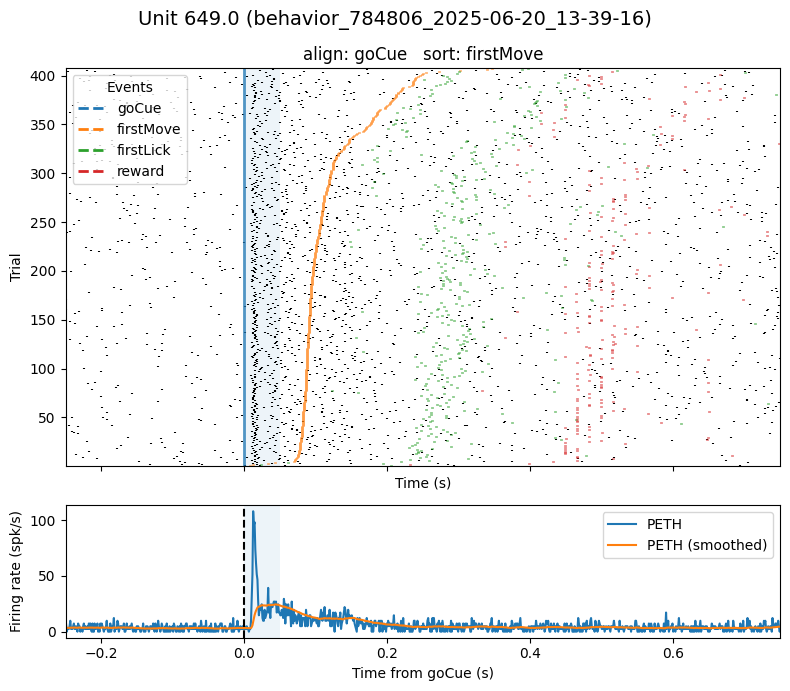

In [ ]:
# === SECOND FIGURE WITH X-LIMIT ===
fig2, (ax_raster2, ax_psth2) = plt.subplots(
    2, 1, figsize=(8, 7), sharex=True, gridspec_kw={'height_ratios':[3,1]}
)

rp.plot_raster(ax=ax_raster2, spike_color='black')
rp.add_events(ax_raster2, events)
ax_raster2.set_title(f'align: {align_by}   sort: {sort_by}')
ax_raster2.legend(loc='upper left', title='Events')

# optional shade window
ax_raster2.axvspan(a, b, alpha=0.08, linewidth=0)

# psth
plot_psth(rp.bins, psth, psth_sm, ax=ax_psth2, label='PETH')
ax_psth2.axvspan(a, b, alpha=0.08, linewidth=0)
ax_psth2.set_xlabel(f'Time from {align_by} (s)')

# ---- here’s the custom limit ----
ax_psth2.set_xlim(-0.25, .75)

plt.suptitle(f'Unit {row["unit_id"]} ({session})', fontsize=14)
plt.tight_layout()
plt.show()

if SAVE_FIG:
    fname = FIG_DIR / "example_raster_alignGo_sortMove_zoom"
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig2.savefig(f"{fname}.png", dpi=300, bbox_inches="tight")
    fig2.savefig(f"{fname}.svg", bbox_inches="tight")


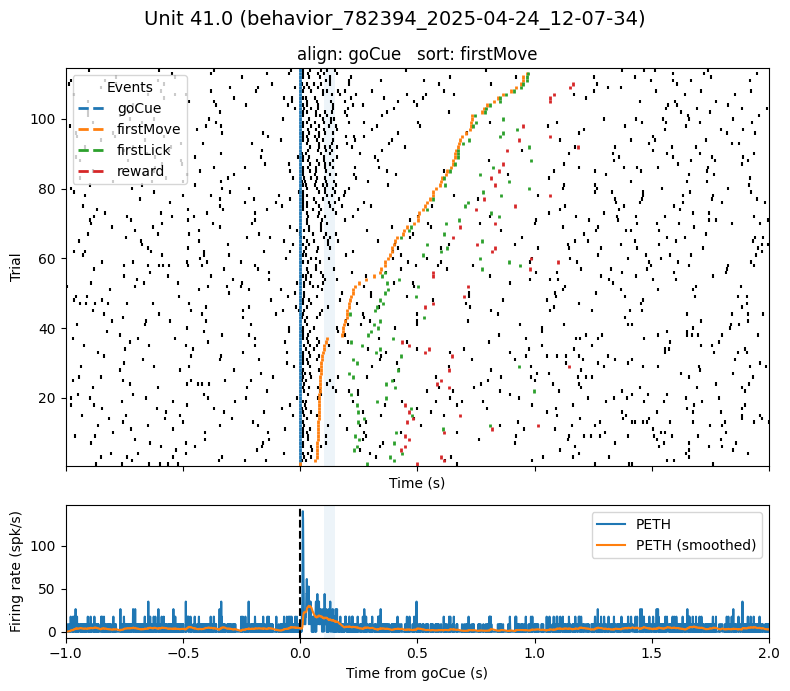

In [ ]:
from aind_dynamic_foraging_behavior_video_analysis.ephys.tongue_ephys import make_rp_and_events, compute_psth, smooth_vector, plot_psth

# Pick one unit (example)
# row = units_with_spikes.iloc[10]          # or pick by session/unit_id
unit_num = 41
session_str = "behavior_782394_2025-04-24_12-07-34"
row = units_with_spikes.query("session == @session_str and unit_id == @unit_num").iloc[0]
session = row["session"]
spikes_abs = np.array(row["spike_times"], dtype=float)  # from NWB

# 1) Get the session bundle (already made with cfg)
bundle = bundle_cache[session]
Ev          = bundle["Ev"]                 # DataFrame of event times per trial
align_times = bundle["align_times"]        # Series: trial -> t0 (absolute, s)
offset      = bundle["session_offset"]     # to convert absolute → session time

# 2) Convert spikes to session time (skip if yours are already in session time)
spikes = spikes_abs - offset

# 3) Turn Ev into dicts that the wrapper expects
event_dicts = {col: Ev[col].dropna().to_dict() for col in Ev.columns}
trials = Ev.index.tolist()

# 4) Build the plotter (choose align & sort; align from cfg is convenient)
align_by = cfg.align_key      # e.g., "goCue"
sort_by  = "firstMove"        # or "firstLick", "reward", etc.

rp, events = make_rp_and_events(
    spikes=spikes,
    trials=trials,
    event_dicts=event_dicts,
    events_to_plot=['goCue','firstMove','firstLick','reward'],
    align_by=align_by,
    sort_by=sort_by,
    pre=1.0,
    post=2.0,
    bin_size=0.001,
)

# 5) Plot (raster + PSTH)
fig, (ax_raster, ax_psth) = plt.subplots(
    2, 1, figsize=(8, 7), sharex=True, gridspec_kw={'height_ratios':[3,1]}
)
rp.plot_raster(ax=ax_raster, spike_color='black')
rp.add_events(ax_raster, events)
ax_raster.set_title(f'align: {align_by}   sort: {sort_by}')
ax_raster.legend(loc='upper left', title='Events')

# optional: shade your analysis window from cfg
a, b = cfg.count_window_s
ax_raster.axvspan(a, b, alpha=0.08, linewidth=0)

psth, _  = compute_psth(rp.raster, bin_size=rp.bin_size)
psth_sm  = smooth_vector(psth, bin_size=rp.bin_size, sigma=0.025)
plot_psth(rp.bins, psth, psth_sm, ax=ax_psth, label='PETH')
ax_psth.axvspan(a, b, alpha=0.08, linewidth=0)
ax_psth.set_xlabel(f'Time from {align_by} (s)')

plt.suptitle(f'Unit {row["unit_id"]} ({session})', fontsize=14)

plt.tight_layout()
plt.show()
if SAVE_FIG:
    fname = FIG_DIR / "example_raster_alignGo_sortMove"
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(f"{fname}.png", dpi=300, bbox_inches="tight")
    fig.savefig(f"{fname}.svg", bbox_inches="tight")


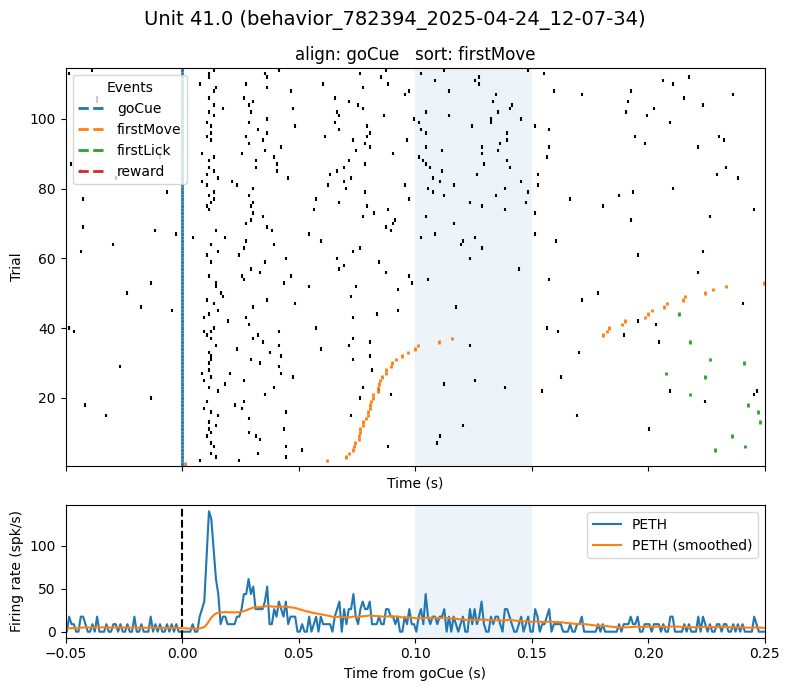

In [ ]:
# 5) Plot (raster + PSTH)
fig, (ax_raster, ax_psth) = plt.subplots(
    2, 1, figsize=(8, 7), sharex=True, gridspec_kw={'height_ratios':[3,1]}
)
rp.plot_raster(ax=ax_raster, spike_color='black')
rp.add_events(ax_raster, events)
ax_raster.set_title(f'align: {align_by}   sort: {sort_by}')
ax_raster.legend(loc='upper left', title='Events')

# optional: shade your analysis window from cfg
a, b = cfg.count_window_s
ax_raster.axvspan(a, b, alpha=0.08, linewidth=0)

psth, _  = compute_psth(rp.raster, bin_size=rp.bin_size)
psth_sm  = smooth_vector(psth, bin_size=rp.bin_size, sigma=0.025)
plot_psth(rp.bins, psth, psth_sm, ax=ax_psth, label='PETH')
ax_psth.axvspan(a, b, alpha=0.08, linewidth=0)
ax_psth.set_xlabel(f'Time from {align_by} (s)')

plt.xlim(-.05, .25)

plt.suptitle(f'Unit {row["unit_id"]} ({session})', fontsize=14)

plt.tight_layout()
plt.show()
if SAVE_FIG:
    fname = FIG_DIR / "example_raster_alignGo_sortMove"
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(f"{fname}.png", dpi=300, bbox_inches="tight")
    fig.savefig(f"{fname}.svg", bbox_inches="tight")

<Figure size 800x700 with 0 Axes>

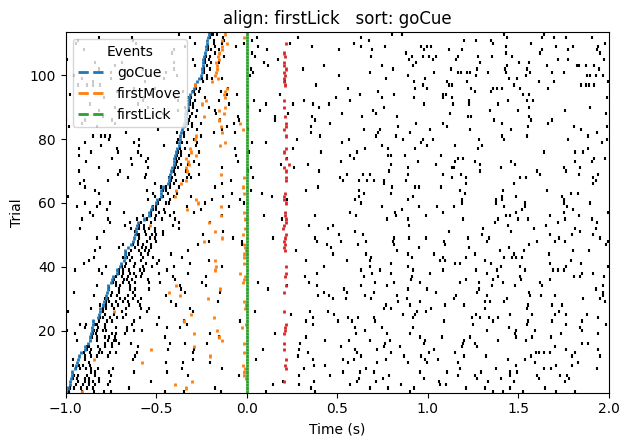

In [ ]:
import matplotlib.pyplot as plt

new_align = "firstLick"
new_sort  = "goCue"

# Assume spikes, trials, event_dicts, row, session, FIG_DIR, SAVE_FIG defined above

rp, events = make_rp_and_events(
    spikes=spikes,
    trials=trials,
    event_dicts=event_dicts,
    events_to_plot=['goCue','firstMove','firstLick','reward'],
    align_by=new_align,
    sort_by=new_sort,
    pre=1.0, post=2.0, bin_size=0.001,
)

fig = plt.figure(figsize=(8, 7))
ax = rp.plot_raster(spike_color="black")
rp.add_events(ax, events)
ax.set_title(f"align: {new_align}   sort: {new_sort}")
ax.legend(loc='upper left', title='Events')

# Use fig.suptitle instead of plt.suptitle (better control)
fig.suptitle(f'Unit {row["unit_id"]} ({session})', fontsize=14, y=1.02)

# Then adjust layout *after* suptitle
plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave room for suptitle

if SAVE_FIG:
    fname = FIG_DIR / "example_raster_alignLick_sortGo"
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(f"{fname}.png", dpi=300, bbox_inches="tight")
    fig.savefig(f"{fname}.svg", bbox_inches="tight")

plt.show()
